# Photoplethysmogram (PPG) heart beat estimation model

## 5. Exploratory Data Analysis (EDA)

### 5.1. Import Data and Required Packages

In [5]:
import pandas as pd
import numpy as np
from scipy.fft import fft, fftfreq, rfft, rfftfreq, ifft, irfft
import matplotlib.pyplot as plt
import math # sqrt for magnitude
%matplotlib inline

In [30]:
all_subjects_csv = pd.read_csv("../Subjects/subjects_csv/all_subjects.csv")
all_subjects_csv # csv with all subjects used

,Subject,0,1,2,3,4,5,6,7,8,...,1303,1304,1305,1306,1307,1308,1309,1310,1311,1312
0,Subject 1,7.28,6.33,5.46,4.60,3.74,2.86,2.03,1.27,0.57,...,32.15,32.15,32.13,32.13,32.13,32.13,32.15,32.15,32.15,49.611369
1,Subject 1,6.34,9.78,12.97,15.82,18.17,19.99,21.33,22.39,23.37,...,32.15,32.15,32.16,32.16,32.16,32.16,32.15,32.15,32.15,50.323992
2,Subject 1,7.70,6.02,4.23,2.46,0.74,-0.93,-2.62,-4.36,-6.16,...,32.15,32.15,32.15,32.15,32.15,32.15,32.13,32.13,32.13,52.708336
3,Subject 1,-120.35,-108.51,-98.97,-91.45,-84.97,-78.29,-70.36,-60.68,-49.41,...,32.13,32.13,32.15,32.15,32.15,32.15,32.13,32.13,32.13,55.640794
4,Subject 1,-7.06,-10.67,-14.96,-19.60,-24.25,-28.65,-32.73,-36.59,-40.43,...,32.13,32.13,32.13,32.13,32.13,32.13,32.15,32.15,32.15,57.658406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64742,Subject 15,24.22,23.34,22.43,21.48,20.36,19.04,17.55,16.05,14.67,...,34.00,33.99,33.99,33.99,33.99,33.99,33.99,33.99,33.99,80.853007
64743,Subject 15,-35.83,-38.20,-39.20,-38.33,-35.31,-30.30,-23.76,-16.46,-9.23,...,33.99,33.99,33.99,33.99,33.99,NaN,NaN,NaN,NaN,NaN
64744,Subject 15,2.07,1.52,0.42,-0.96,-2.35,-3.55,-4.53,-5.45,-6.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64745,Subject 15,15.63,14.74,13.91,12.97,11.83,10.51,9.09,7.69,6.43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
all_subjects_csv.shape

(64747, 1314)

### 5.2. PPG Data visualization

In [9]:
ppg_graph = all_subjects_csv.iloc[0, 1:513] # get the first 8 second ppg samples
ppg_graph

0      7.28
1      6.33
2      5.46
3       4.6
4      3.74
       ... 
507    3.77
508    1.43
509   -0.45
510    -2.2
511   -4.28
Name: 0, Length: 512, dtype: object

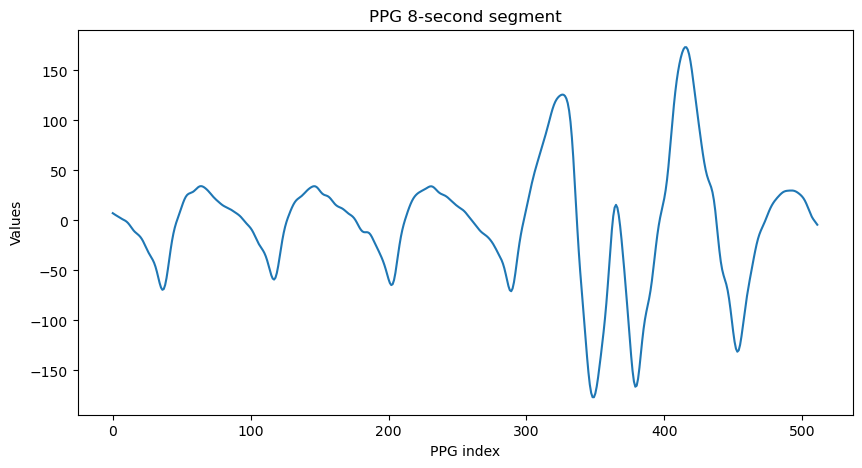

In [11]:
fig, ax = plt.subplots(1,1, figsize=(10,5)) # graphing samples
ppg_graph.plot()
plt.title('PPG 8-second segment')
ax.set_xlabel('PPG index')
ax.set_ylabel('Values')
ax.tick_params('x')
plt.savefig('../media/8_second_segment.png')

### 5.3. FFT and z-normalisation

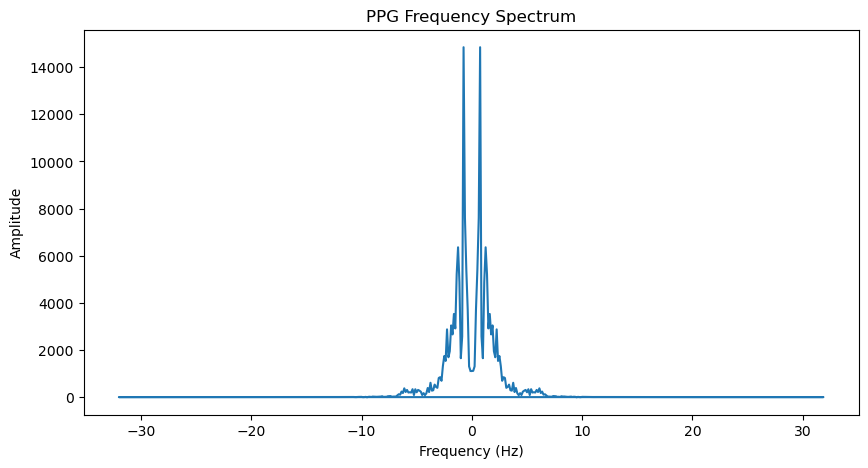

In [16]:
np_ppg_arr = np.array(ppg_graph) # converted to numpy array to work with the fft function
SAMPLE_RATE = 64  # Hertz, sampling rate of the ppg sensor
DURATION = 8  # Seconds that we segmented
N = len(np_ppg_arr) # number of samples in 8 seconds

# fft() calculates the transform itself.
# fftfreq() calculates the frequencies in the center of each bin in the output of fft(). Without this, there would be no way to plot the x-axis on your frequency spectrum.
ppg_fft = fft(np_ppg_arr) # fast fourier transform 
ppg_freq = fftfreq(N, 1/SAMPLE_RATE) # fast Fourier Transform sample frequencies

plt.figure(figsize=(10, 5))
plt.plot(ppg_freq, np.abs(ppg_fft))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('PPG Frequency Spectrum')
plt.savefig('../media/ppg_freq_spectrum_orig.png')
plt.show()

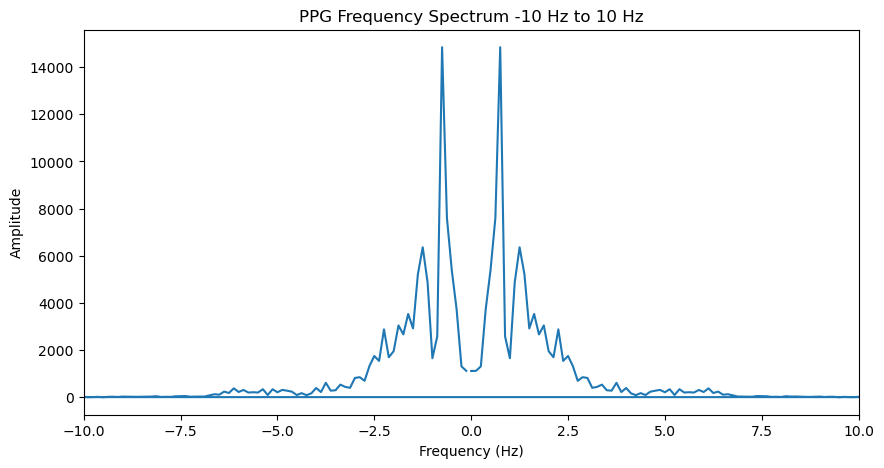

In [18]:
# Plot with range between -10 and 10 for better visualization of relevant data  
plt.figure(figsize=(10, 5))
plt.plot(ppg_freq, np.abs(ppg_fft))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(-10, 10) # to zoom in
plt.title('PPG Frequency Spectrum -10 Hz to 10 Hz')
plt.savefig('../media/ppg_freq_spectrum_orig.png')
plt.show()

# It's possible to check how this graph has more in depth of the data distribution when compared to the last one
# However, the important high peaks of amplitude are more centered between -2.5 Hz and 2.5 Hz 

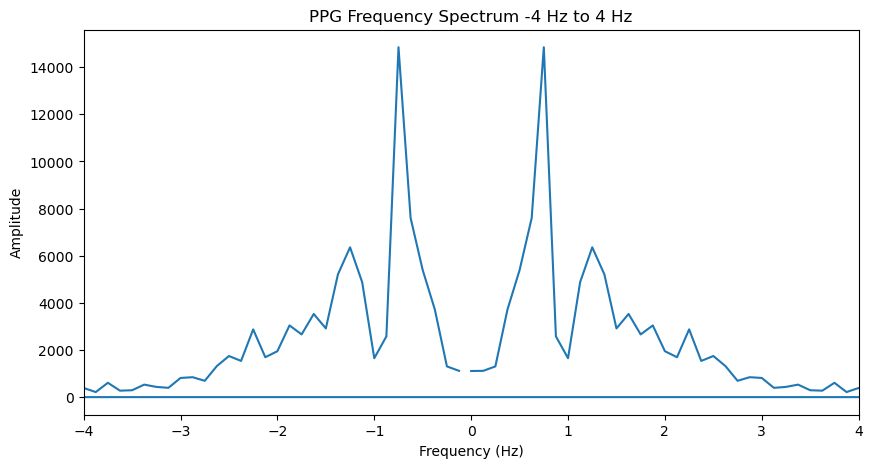

In [20]:
# Plot with range between -4 and 4 for better visualization of relevant data  
plt.figure(figsize=(10, 5))
plt.plot(ppg_freq, np.abs(ppg_fft))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(-4, 4)
plt.title('PPG Frequency Spectrum -4 Hz to 4 Hz')
plt.savefig('../media/ppg_freq_spectrum_orig.png')
plt.show()

# This plot represents the important data of the frequency spectrum. It's observed how there's a really high peak at the beginning and 
# declining peaks when moving away from the beginning 

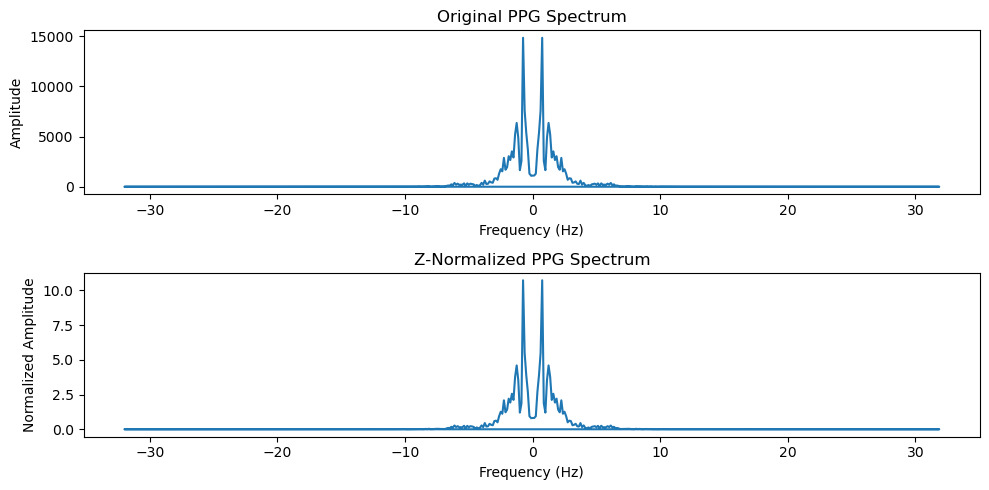

In [22]:
ppg_mean = np.mean(ppg_fft) # mean
ppg_std = np.std(ppg_fft) # standard deviation
ppg_normalized = (ppg_fft - ppg_mean) / ppg_std # z normalisation

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(ppg_freq, np.abs(ppg_fft)) 
plt.title('Original PPG Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(ppg_freq, np.abs(ppg_normalized)) 
plt.title('Z-Normalized PPG Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Amplitude')

plt.tight_layout()
plt.savefig('../media/ppg_freq_spectrum_orig_normalised.png')
plt.show()

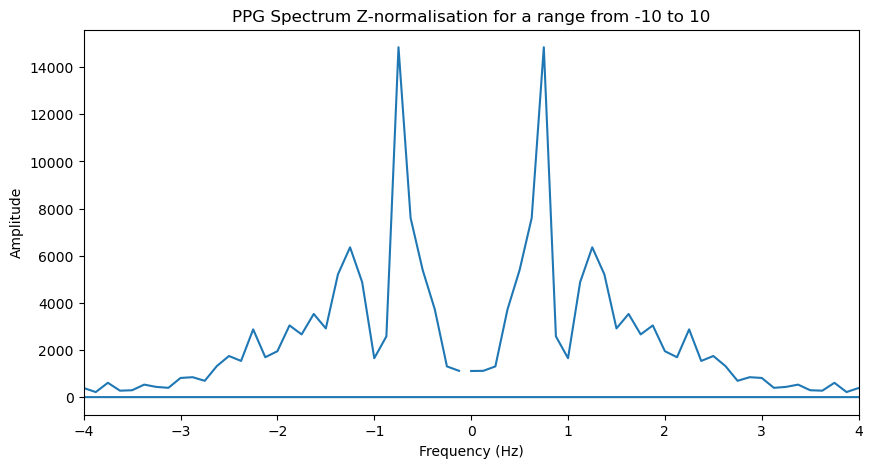

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(ppg_freq, np.abs(ppg_fft)) 
plt.title('PPG Spectrum Z-normalisation for a range from -10 to 10')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(-4,4);

In [26]:
# Checking if the z normalisation worked
mean_normalized = np.mean(ppg_normalized) # mean should be 0 
std_normalized = np.std(ppg_normalized) # standard deviation should be 1
mean_normalized, std_normalized

((2.8189256484623115e-18-6.5052130349130266e-18j), 1.0)

### 5.4 Checking data correlation

In [29]:
# Create a new DF containing ppg heart rate and frequency values to visualize it
df_graph = pd.DataFrame({'frequency': ppg_freq, 'heartrate': ppg_graph})

In [31]:
len(ppg_graph), len(ppg_freq)

(512, 512)

In [33]:
df_graph

,frequency,heartrate
0,0.000,7.28
1,0.125,6.33
2,0.250,5.46
3,0.375,4.6
4,0.500,3.74
...,...,...
507,-0.625,3.77
508,-0.500,1.43
509,-0.375,-0.45
510,-0.250,-2.2


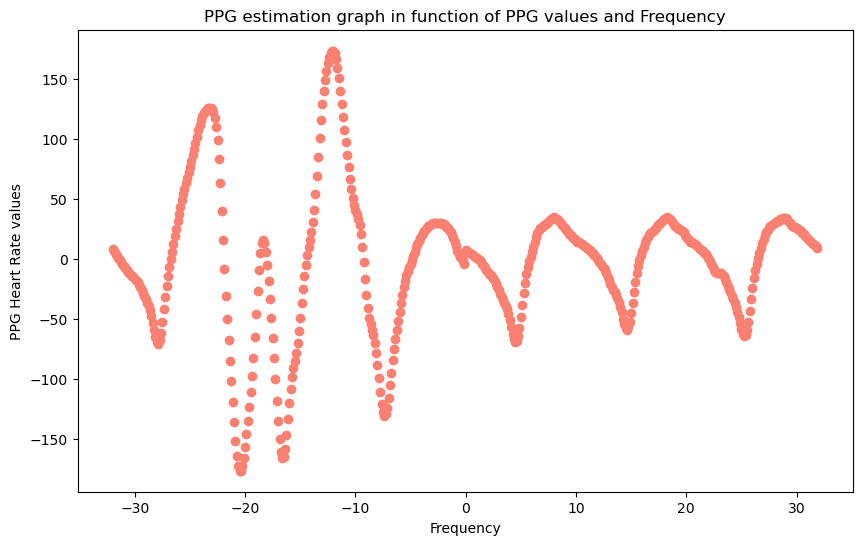

In [35]:
# Heartrate per Frequency
plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(ppg_freq, # discrete variable
            ppg_graph,  # continuous variable
            c="salmon");

# helpful info
plt.title("PPG estimation graph in function of PPG values and Frequency")
plt.xlabel("Frequency")
plt.ylabel("PPG Heart Rate values");

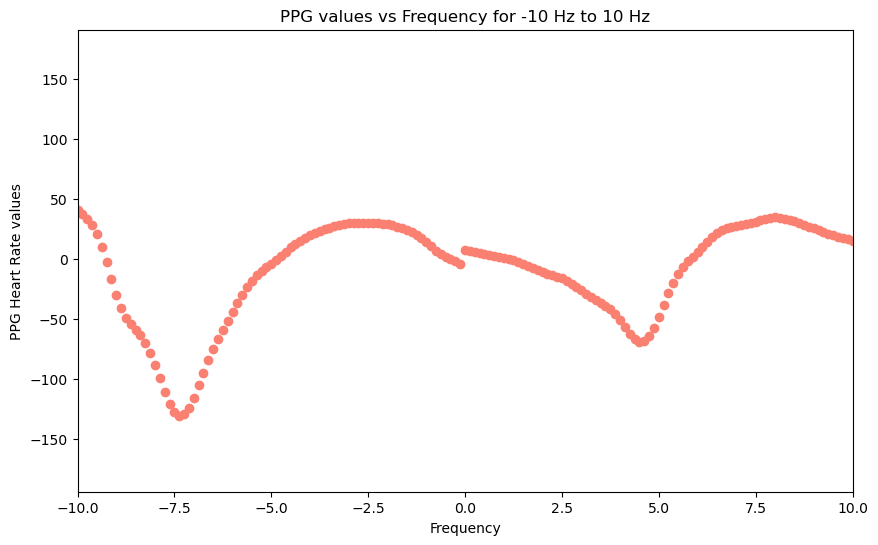

In [37]:
plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(ppg_freq, # discrete variable
            ppg_graph,  # continuous variable
            c="salmon");

# Add some helpful info
plt.title("PPG values vs Frequency for -10 Hz to 10 Hz")
plt.xlabel("Frequency")
plt.ylabel("PPG Heart Rate values")
plt.xlim(-10,10);

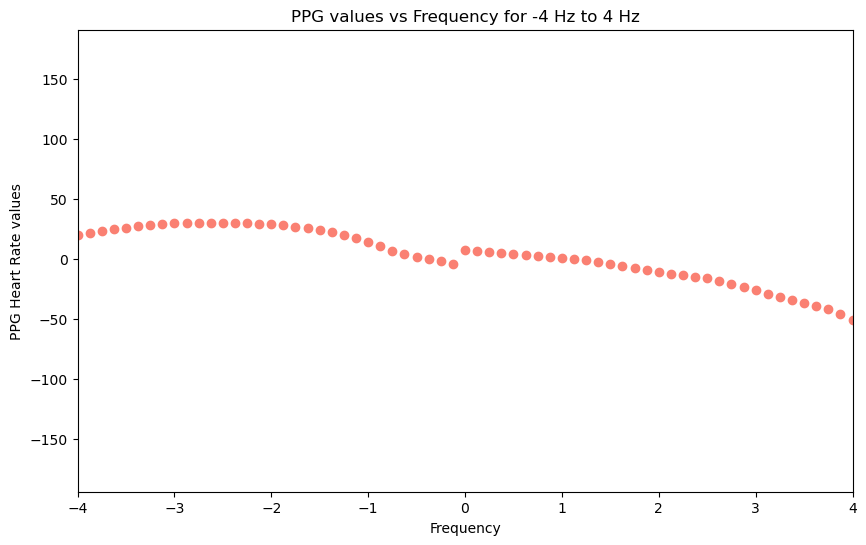

In [39]:
plt.figure(figsize=(10,6))

plt.scatter(ppg_freq, # discrete variable
            ppg_graph,  # continuous variable
            c="salmon");

# Add some helpful info
plt.title("PPG values vs Frequency for -4 Hz to 4 Hz")
plt.xlabel("Frequency")
plt.ylabel("PPG Heart Rate values")
plt.xlim(-4,4);

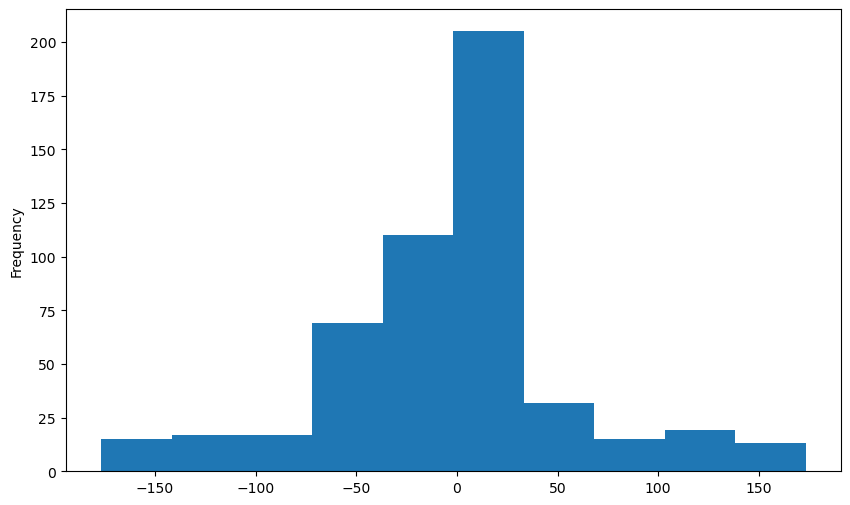

In [41]:
# hist plot
# Heartrate with Frequency
# Create another figure
plt.figure(figsize=(10,6))

# Scatter plot
# show the columns with target equals 1
# Check the distribution of the age column with a histogram
ppg_graph.plot.hist();
# we can see that it's a normal distribution (Gaussian)

### 5.5. Limiting the data range

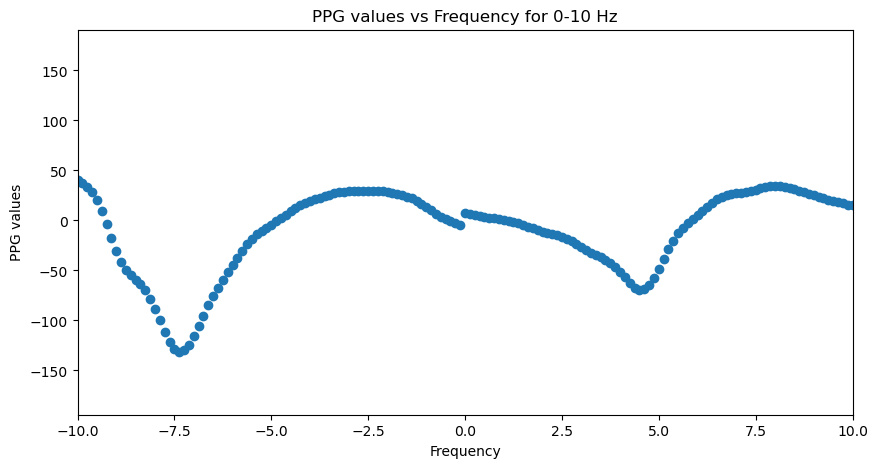

In [44]:
plt.figure(figsize=(10,5))

plt.scatter(ppg_freq, ppg_graph)
plt.xlabel('Frequency')
plt.ylabel('PPG values')
plt.title('PPG values vs Frequency for 0-10 Hz')
plt.xlim(-10,10);

In [46]:
df_graph

,frequency,heartrate
0,0.000,7.28
1,0.125,6.33
2,0.250,5.46
3,0.375,4.6
4,0.500,3.74
...,...,...
507,-0.625,3.77
508,-0.500,1.43
509,-0.375,-0.45
510,-0.250,-2.2


In [48]:
df_graph[(df_graph['frequency'] >= -10)]

,frequency,heartrate
0,0.000,7.28
1,0.125,6.33
2,0.250,5.46
3,0.375,4.6
4,0.500,3.74
...,...,...
507,-0.625,3.77
508,-0.500,1.43
509,-0.375,-0.45
510,-0.250,-2.2


In [50]:
df_graph[(df_graph['frequency'] <= 10)]

,frequency,heartrate
0,0.000,7.28
1,0.125,6.33
2,0.250,5.46
3,0.375,4.6
4,0.500,3.74
...,...,...
507,-0.625,3.77
508,-0.500,1.43
509,-0.375,-0.45
510,-0.250,-2.2


In [52]:
filtered_df = df_graph[(df_graph['frequency'] >= -10) & (df_graph['frequency'] <= 10)]

In [54]:
filtered_df

,frequency,heartrate
0,0.000,7.28
1,0.125,6.33
2,0.250,5.46
3,0.375,4.6
4,0.500,3.74
...,...,...
507,-0.625,3.77
508,-0.500,1.43
509,-0.375,-0.45
510,-0.250,-2.2


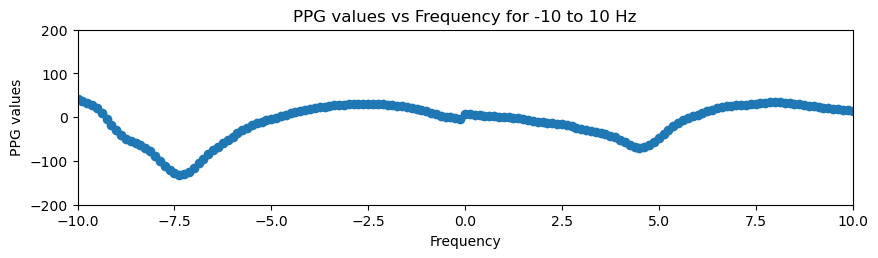

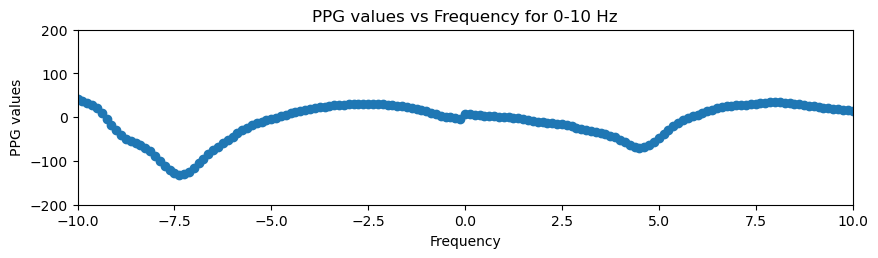

In [56]:
# Plotting the filtered values
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.scatter(filtered_df['frequency'], filtered_df['heartrate'])
plt.xlabel('Frequency')
plt.ylabel('PPG values')
plt.title('PPG values vs Frequency for -10 to 10 Hz')
plt.xlim(-10, 10)
plt.ylim(-200, 200);
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 2)
plt.scatter(ppg_freq, ppg_graph)
plt.xlabel('Frequency')
plt.ylabel('PPG values')
plt.title('PPG values vs Frequency for 0-10 Hz')
plt.xlim(-10,10)
plt.ylim(-200, 200)
plt.show()

### 5.6. Filtering to 0-4 Hz and transforming it back to the time domain using real Fast Fourier Transform (rFFT)

Source: https://numpy.org/doc/stable/reference/generated/numpy.fft.rfft.html 

In [59]:
# Trying to apply the FFT and transform it back to the time domain

np_ppg_arr = np.array(ppg_graph) # converted to numpy array to work with the fft function
SAMPLE_RATE = 64  # Hertz, sampling rate of the ppg sensor
DURATION = 8  # Seconds that we segmented
N = len(np_ppg_arr) # number of samples in 8 seconds

# fft() calculates the transform itself.
# fftfreq() calculates the frequencies in the center of each bin in the output of fft(). Without this, there would be no way to plot the x-axis on your frequency spectrum.
ppg_fft = fft(np_ppg_arr) # fast fourier transform 
ppg_freq = fftfreq(N, 1/SAMPLE_RATE) # fast Fourier Transform sample frequencies

In [61]:
new_sign = ifft(filtered_df['heartrate']) # for some reason I can't transform it back to the time domain using FFT
new_sign; # the array values still are in rectangular form ([real numbers] + j*[complex numbers])

(0.0, 10.0)

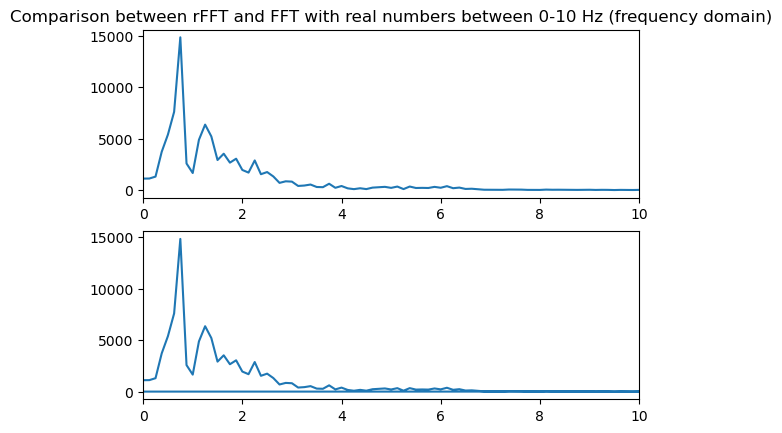

In [63]:
# creating a real Fast Fourier Transform (rFFT) - I only found a way to invert back to time domain with rFFT and not with normal FFT 
# (which in the end doesn't change much cause our dataset has only real values)
new_ppg_rfft = rfft(np_ppg_arr) # rFFT
new_ppg_rfreq = rfftfreq(N, 1/SAMPLE_RATE) # frequency for rFFT

# Comparing and checking if the rFFT and FFT are the same. Note: since rFFT is for real values, then I had to discard the negative part of the normal FFT graph 
plt.subplot(2,1,1)
plt.title('Comparison between rFFT and FFT with real numbers between 0-10 Hz (frequency domain)')
plt.plot(new_ppg_rfreq, np.abs(new_ppg_rfft))
plt.xlim(0, 10)
plt.subplot(2,1,2)
plt.plot(ppg_freq, np.abs(ppg_fft))
plt.xlim(0, 10)

In [65]:
df_rfft = pd.DataFrame({'frequency': new_ppg_rfreq, 'heartrate': new_ppg_rfft}) # creating a new df for the rFFT
df_rfft

,frequency,heartrate
0,0.000,-1114.000000+ 0.000000j
1,0.125,-353.292892-1063.586962j
2,0.250,977.601574+ 870.089095j
3,0.375,-3034.880096+2155.066282j
4,0.500,-2323.184280-4865.794460j
...,...,...
252,31.500,6.585810- 0.160211j
253,31.625,6.754722- 0.127148j
254,31.750,6.630354- 0.094417j
255,31.875,6.711343- 0.036017j


In [67]:
df_rfft_filtered = df_rfft[df_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
df_rfft_filtered;

(0.0, 4.0)

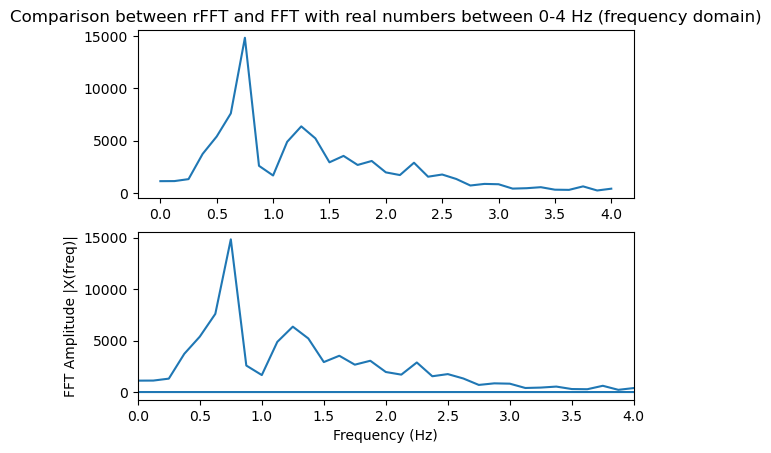

In [69]:
# Comparing the new filtered graph (from the rFFT dataframe) with the original graph (ppg_fft) for a 0-4 Hz range
plt.subplot(2,1,1)
plt.title('Comparison between rFFT and FFT with real numbers between 0-4 Hz (frequency domain)')
plt.plot(df_rfft_filtered['frequency'], np.abs(df_rfft_filtered['heartrate']))
plt.subplot(2,1,2)
plt.plot(ppg_freq, np.abs(ppg_fft))
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlabel('Frequency (Hz)')
plt.xlim(0,4)

In [71]:
len(df_rfft_filtered['frequency']), len(np.abs(df_rfft_filtered['heartrate']))

(33, 33)

In [73]:
# Transforming it back from the rFFT (frequency domain) to the time domain
rfft_filt = np.array(df_rfft_filtered['heartrate'])
new_ppg_sign = irfft(rfft_filt)
new_ppg_sign # now it's notable how the array has only real numbers (and not complex numbers like it happened with FFT)

array([    7.17717254,    21.85911507,  -101.54239547,  -185.19807396,
        -452.02153919,  -385.45853871,    68.99551966,   210.9553546 ,
         271.78045409,   202.52559931,   118.88615526,    74.58485222,
         -15.38830722,  -127.04179878,  -355.27318216,  -352.1229702 ,
          66.62770795,   180.36516027,   270.14114   ,   221.27552065,
         150.85268079,    77.31040519,     1.46967347,  -109.32798025,
        -202.25896205,  -475.11180111,  -229.63074177,   148.0880004 ,
         229.3982839 ,   270.45940515,   195.02530743,   143.46453749,
          50.41505128,   -40.21534171,  -146.64619585,  -261.01905324,
        -524.04653822,  -144.96105418,   300.00030066,   621.66670084,
         904.59167716,  1011.43955992,   161.37673748, -1118.2285748 ,
       -1286.86774057,  -337.09503796,   -15.81374357, -1096.23742139,
       -1032.54747709,  -349.38432561,   192.33345116,   996.31270258,
        1390.03822484,   856.5679169 ,   325.25079158,  -165.77736198,
      

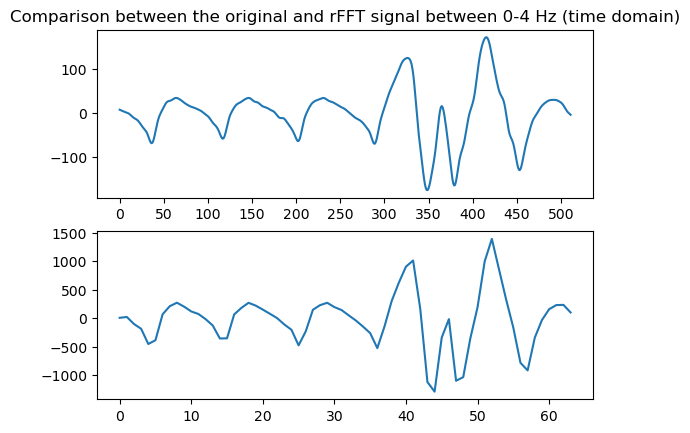

In [75]:
plt.subplot(2,1,1)
plt.title('Comparison between the original and rFFT signal between 0-4 Hz (time domain)')
plt.plot(ppg_graph)  # plot of the original signal
plt.xticks(np.arange(0, 512, 50))
plt.subplot(2,1,2)
plt.plot(new_ppg_sign) # plot of the signal filtered for 0-4 Hz using rFFT
plt.show()

### 5.7. Plotting different heart rates segments

In [78]:
all_subjects_csv.head(10)

,Subject,0,1,2,3,4,5,6,7,8,...,1303,1304,1305,1306,1307,1308,1309,1310,1311,1312
0,Subject 1,7.28,6.33,5.46,4.60,3.74,2.86,2.03,1.27,0.57,...,32.15,32.15,32.13,32.13,32.13,32.13,32.15,32.15,32.15,49.611369
1,Subject 1,6.34,9.78,12.97,15.82,18.17,19.99,21.33,22.39,23.37,...,32.15,32.15,32.16,32.16,32.16,32.16,32.15,32.15,32.15,50.323992
2,Subject 1,7.70,6.02,4.23,2.46,0.74,-0.93,-2.62,-4.36,-6.16,...,32.15,32.15,32.15,32.15,32.15,32.15,32.13,32.13,32.13,52.708336
3,Subject 1,-120.35,-108.51,-98.97,-91.45,-84.97,-78.29,-70.36,-60.68,-49.41,...,32.13,32.13,32.15,32.15,32.15,32.15,32.13,32.13,32.13,55.640794
4,Subject 1,-7.06,-10.67,-14.96,-19.60,-24.25,-28.65,-32.73,-36.59,-40.43,...,32.13,32.13,32.13,32.13,32.13,32.13,32.15,32.15,32.15,57.658406
5,Subject 1,39.96,38.96,37.78,36.37,34.70,32.84,30.87,28.90,27.01,...,32.15,32.15,32.13,32.13,32.13,32.13,32.15,32.15,32.15,58.911550
6,Subject 1,87.64,86.60,84.92,82.27,78.56,73.88,68.48,62.64,56.62,...,32.15,32.15,32.15,32.15,32.15,32.15,32.15,32.15,32.15,57.976459
7,Subject 1,-101.46,-85.68,-69.78,-53.39,-36.17,-18.03,0.67,19.17,36.49,...,32.15,32.15,32.15,32.15,32.15,32.15,32.13,32.13,32.13,58.676292
8,Subject 1,83.63,46.20,11.78,-18.33,-43.42,-63.41,-78.67,-89.85,-97.59,...,32.13,32.13,32.13,32.13,32.13,32.13,32.15,32.15,32.15,62.350800
9,Subject 1,-7.41,3.89,14.59,24.58,33.77,42.02,49.33,55.77,61.46,...,32.15,32.15,32.11,32.11,32.11,32.11,32.11,32.11,32.11,69.113975


In [80]:
# 8-second segments of subject 1
ppg_first_segment = all_subjects_csv.iloc[0, 1:513]
ppg_second_segment = all_subjects_csv.iloc[1, 1:513]
ppg_third_segment = all_subjects_csv.iloc[2, 1:513]
ppg_tenth_segment = all_subjects_csv.iloc[9, 1:513]
ppg_fifteenth_segment = all_subjects_csv.iloc[15, 1:513]
# print(second_segment)

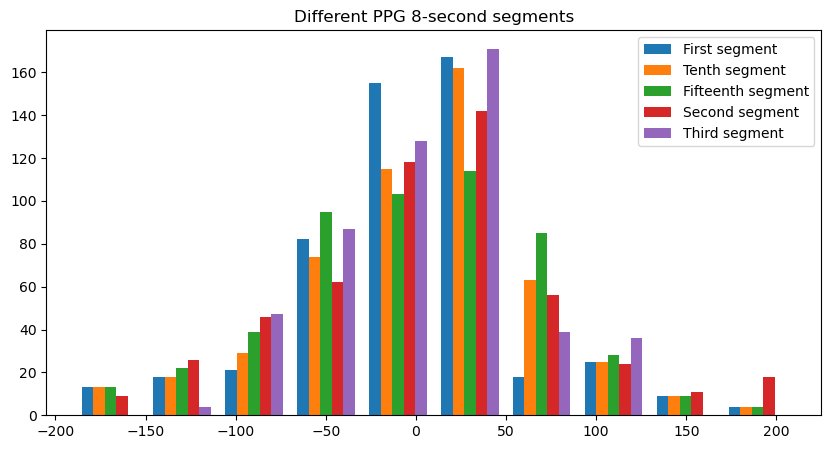

In [82]:
ppg_segments = [ppg_first_segment, ppg_second_segment, ppg_third_segment, ppg_tenth_segment, ppg_fifteenth_segment]
ppg_segments_legends = {'First segment', 'Second segment', 'Third segment', 'Tenth segment', 'Fifteenth segment'}
plt.figure(figsize=(10,5))
plt.hist(ppg_segments)
plt.title('Different PPG 8-second segments')
plt.legend(ppg_segments_legends)
plt.show()

In [84]:
np.min(ppg_second_segment), np.min(ppg_tenth_segment), np.max(ppg_second_segment), np.max(ppg_tenth_segment)

(-176.79, -189.51, 173.25, 209.4)

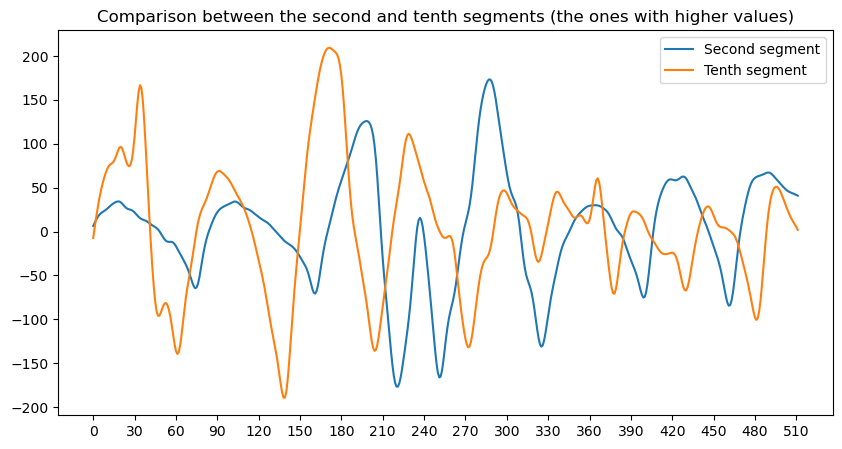

In [86]:
plt.figure(figsize=(10,5))
plt.title('Comparison between the second and tenth segments (the ones with higher values)')
plt.plot(ppg_second_segment)
plt.plot(ppg_tenth_segment)
plt.legend(['Second segment', 'Tenth segment'])
plt.xticks(np.arange(0, 512, 30))
plt.show()

### 5.8. Different heart rate segments with 0-4 Hz frequency range

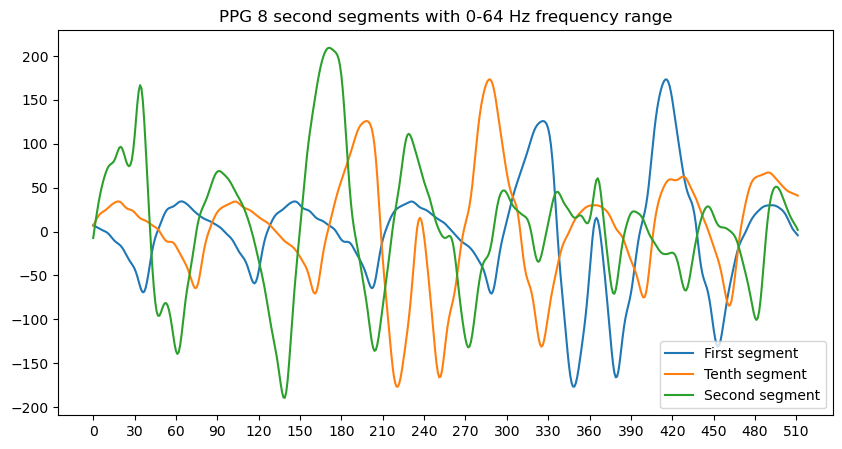

In [89]:
segments_legends = {'First segment','Second segment', 'Tenth segment'}
plt.figure(figsize=(10,5))
plt.title('PPG 8 second segments with 0-64 Hz frequency range')
plt.plot(ppg_first_segment) 
plt.plot(ppg_second_segment) 
plt.plot(ppg_tenth_segment)
plt.legend(segments_legends)
plt.xticks(np.arange(0, 512, 30))
plt.show()

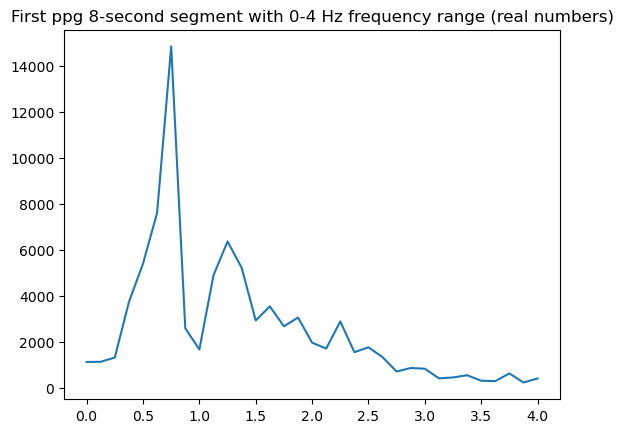

In [91]:
# First ppg 8-second segment 
ppg_first_segment_arr = np.array(ppg_first_segment)

ppg_first_seg_rfft = rfft(ppg_first_segment)
ppg_first_seg_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)

df_ppg_first_seg_rfft = pd.DataFrame({'frequency': ppg_first_seg_rfftfreq, 'heartrate': ppg_first_seg_rfft}) # creating a new df for the rFFT

df_ppg_first_seg_rfft_filtered = df_ppg_first_seg_rfft[df_ppg_first_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
plt.plot(df_ppg_first_seg_rfft_filtered['frequency'], np.abs(df_ppg_first_seg_rfft_filtered['heartrate']))
plt.title('First ppg 8-second segment with 0-4 Hz frequency range (real numbers)')
plt.show()
ppg_first_seg_rfft_filt = np.array(df_ppg_first_seg_rfft_filtered['heartrate'])
ppg_first_seg_irfft = irfft(ppg_first_seg_rfft_filt)

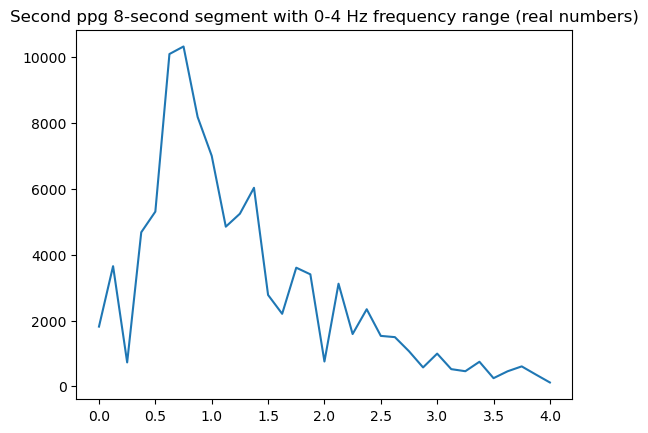

In [93]:
# Second ppg 8-second segment 
ppg_second_segment_arr = np.array(ppg_second_segment)

ppg_second_seg_rfft = rfft(ppg_second_segment)
ppg_second_seg_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)

df_ppg_second_seg_rfft = pd.DataFrame({'frequency': ppg_second_seg_rfftfreq, 'heartrate': ppg_second_seg_rfft}) # creating a new df for the rFFT

df_ppg_second_seg_rfft_filtered = df_ppg_second_seg_rfft[df_ppg_second_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
plt.plot(df_ppg_second_seg_rfft_filtered['frequency'], np.abs(df_ppg_second_seg_rfft_filtered['heartrate']))
plt.title('Second ppg 8-second segment with 0-4 Hz frequency range (real numbers)')
plt.show()
ppg_second_seg_rfft_filt = np.array(df_ppg_second_seg_rfft_filtered['heartrate'])
ppg_second_seg_irfft = irfft(ppg_second_seg_rfft_filt)

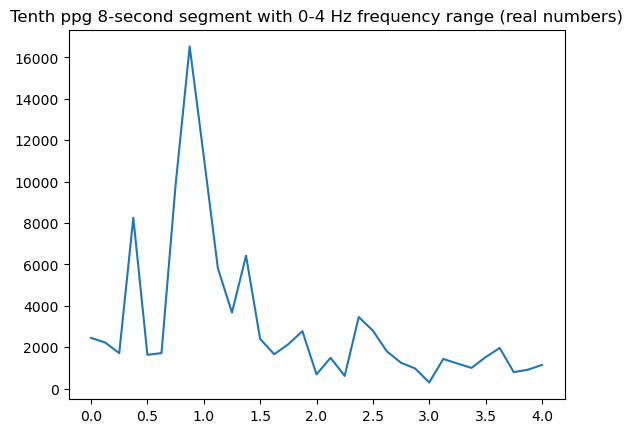

In [95]:
# Tenth ppg 8-second segment 
ppg_tenth_segment_arr = np.array(ppg_tenth_segment)

ppg_tenth_seg_rfft = rfft(ppg_tenth_segment)
ppg_tenth_seg_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)

df_ppg_tenth_seg_rfft = pd.DataFrame({'frequency': ppg_tenth_seg_rfftfreq, 'heartrate': ppg_tenth_seg_rfft}) # creating a new df for the rFFT

df_ppg_tenth_seg_rfft_filtered = df_ppg_tenth_seg_rfft[df_ppg_tenth_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
plt.plot(df_ppg_tenth_seg_rfft_filtered['frequency'], np.abs(df_ppg_tenth_seg_rfft_filtered['heartrate']))
plt.title('Tenth ppg 8-second segment with 0-4 Hz frequency range (real numbers)')
plt.show()
ppg_tenth_seg_rfft_filt = np.array(df_ppg_tenth_seg_rfft_filtered['heartrate'])
ppg_tenth_seg_irfft = irfft(ppg_tenth_seg_rfft_filt)

In [97]:
len(df_ppg_tenth_seg_rfft_filtered['heartrate']), len(df_ppg_tenth_seg_rfft_filtered['frequency'])

(33, 33)

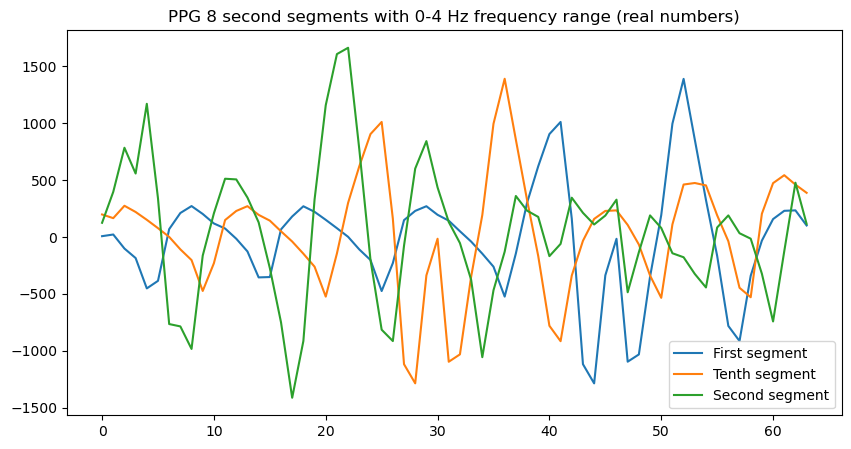

In [99]:
segments_legends = {'First segment','Second segment', 'Tenth segment'}
plt.figure(figsize=(10,5))
plt.title('PPG 8 second segments with 0-4 Hz frequency range (real numbers)')
plt.plot(ppg_first_seg_irfft) 
plt.plot(ppg_second_seg_irfft) 
plt.plot(ppg_tenth_seg_irfft)
plt.legend(segments_legends)
plt.show()

### 5.9. PPG FFT values with accelerometer correlation

NameError: name 'acc_fft' is not defined

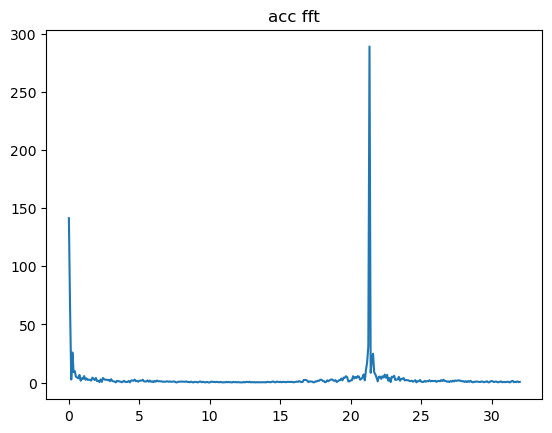

In [111]:
# Trying to apply the FFT and transform it back to the time domain
acc_first_segment = all_subjects_csv.iloc[0, 513:1281] # accelerometer data of the first 8-second segment
np_acc_arr = np.array(acc_first_segment) # converted to numpy array to work with the fft function
SAMPLE_RATE = 64  # Hertz, sampling rate of the ppg sensor
DURATION = 8  # Seconds that we segmented
N = len(np_acc_arr) # number of samples in 8 seconds

# fft() calculates the transform itself.
# fftfreq() calculates the frequencies in the center of each bin in the output of fft(). Without this, there would be no way to plot the x-axis on your frequency spectrum.
acc_rfft = rfft(np_acc_arr) # fast fourier transform 
acc_rfreq = rfftfreq(N, 1/SAMPLE_RATE) # fast Fourier Transform sample frequencies
plt.title('acc fft')
plt.plot(acc_rfreq, np.abs(acc_rfft))

len(acc_fft),len(np.abs(acc_fft))

In [113]:
df_rfft = pd.DataFrame({'frequency': acc_rfreq, 'amplitude': acc_rfft}) # creating a new df for the rFFT
df_rfft

,frequency,amplitude
0,0.000000,-141.343750+ 0.000000j
1,0.083333,-0.322172- 64.371418j
2,0.166667,0.551278+ 2.527902j
3,0.250000,-3.603656- 25.570395j
4,0.333333,8.821137+ 1.089052j
...,...,...
380,31.666667,0.677019- 0.072634j
381,31.750000,-0.012082- 0.360692j
382,31.833333,1.010728- 0.069165j
383,31.916667,0.247549+ 0.172758j


In [115]:
df_rfft_filtered = df_rfft[df_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
df_rfft_filtered;

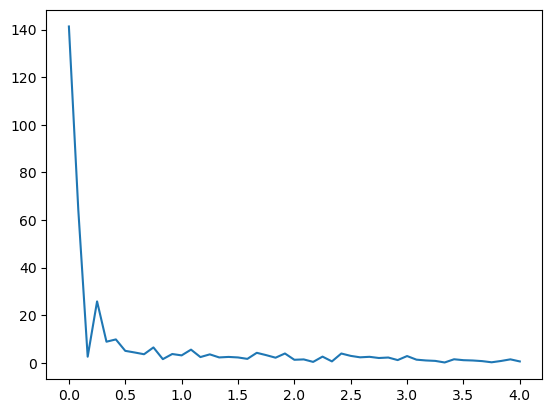

In [117]:
plt.plot(df_rfft_filtered['frequency'], np.abs(df_rfft_filtered['amplitude']))

In [119]:
len(df_rfft_filtered['frequency']), len(np.abs(df_rfft_filtered['amplitude']))

(49, 49)

In [124]:
len(ppg_first_seg_rfft)

257

In [126]:
acc_first_segment = all_subjects_csv.iloc[0, 513:1281] # accelerometer data of the first 8-second segment
# acc_first_segment = all_subjects_csv.iloc[1, 512:1279] # accelerometer data of the second 8-second segment

In [134]:
len(acc_first_segment), acc_first_segment

(768,
 512    -0.765625
 513    -0.078125
 514     0.671875
 515    -0.765625
 516    -0.078125
           ...   
 1275   -0.078125
 1276    0.140625
 1277   -1.015625
 1278   -0.078125
 1279    0.140625
 Name: 0, Length: 768, dtype: object)

In [135]:
acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
for vector in range(0, len(acc_first_segment), 3):
    acc_first_seg_vector.append(acc_first_segment[vector] + acc_first_segment[vector + 1] + acc_first_segment[vector + 2]) # this is the three channels into one

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\2288929817.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(acc_first_segment[vector] + acc_first_segment[vector + 1] + acc_first_segment[vector + 2]) # this is the three channels into one


In [136]:
len(acc_first_seg_vector), acc_first_seg_vector[:10]

(256,
 [-0.171875,
  -0.1875,
  -0.171875,
  -0.171875,
  -0.15625,
  -0.15625,
  -0.171875,
  -0.171875,
  -0.171875,
  -0.171875])

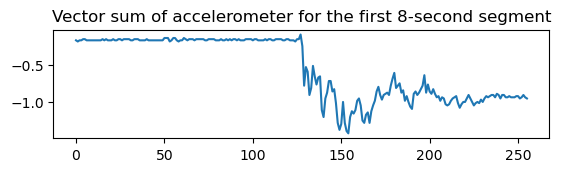

C:\Users\silva\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\silva\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


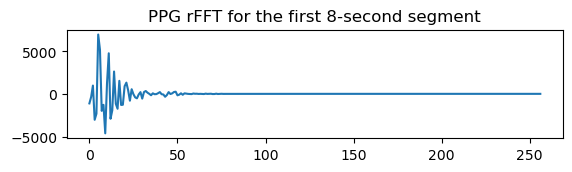

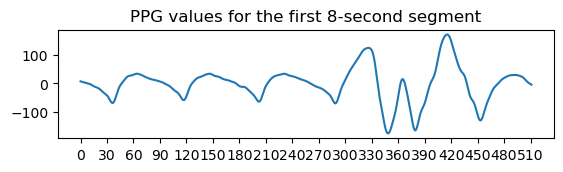

In [142]:
plt.subplot(3,1,1)
plt.title('Vector sum of accelerometer for the first 8-second segment')
plt.plot(acc_first_seg_vector)
plt.show()
plt.subplot(3,1,2)
plt.title('PPG rFFT for the first 8-second segment')
plt.plot(ppg_first_seg_rfft)
plt.show()
plt.subplot(3,1,3)
plt.title('PPG values for the first 8-second segment')
plt.plot(ppg_first_segment)
plt.xticks(np.arange(0, 512, 30))
plt.show()

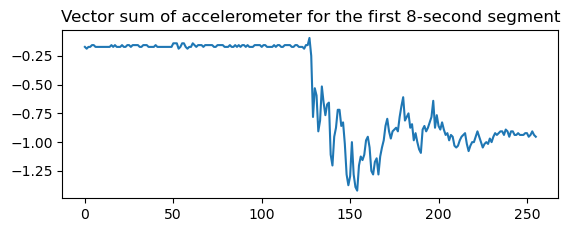

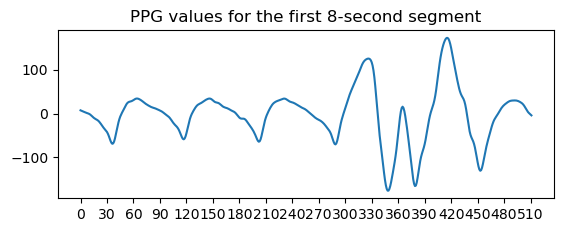

In [144]:
plt.subplot(2,1,1)
plt.title('Vector sum of accelerometer for the first 8-second segment')
plt.plot(acc_first_seg_vector)
plt.show()
plt.subplot(2,1,2)
plt.title('PPG values for the first 8-second segment')
plt.plot(ppg_first_segment)
plt.xticks(np.arange(0, 512, 30))
plt.show()

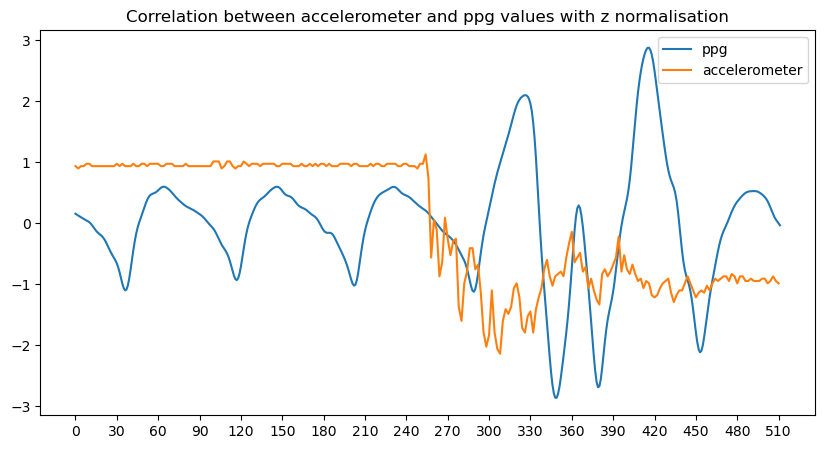

In [146]:
x_acc = np.arange(0, len(ppg_first_segment), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 

x_acc_mean = np.mean(acc_first_seg_vector) # mean
x_acc_std = np.std(acc_first_seg_vector) # standard deviation
x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

ppg_first_mean = np.mean(ppg_first_segment) # mean
ppg_first_std = np.std(ppg_first_segment) # standard deviation
ppg_first_normalized = (ppg_first_segment - ppg_first_mean) / ppg_first_std # z normalisation

plt.figure(figsize=(10,5))
plt.title('Correlation between accelerometer and ppg values with z normalisation')
plt.plot(ppg_first_normalized, label='ppg')
plt.plot(x_acc, x_acc_normalized, label='accelerometer')
plt.xticks(np.arange(0,512,30))
plt.legend()
plt.show()

### 5.10. PPG values and corresponding label visualization 

In [51]:
# Helpful functions

In [151]:
def retrieve_values_display_ppg_label(segment, index):
    """
    Retrieve the label and ppg values of a segment and display the ppg and label values of a segment.
    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]
    
    x_acc = np.arange(0, len(segment_ppg_values), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 
    
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(segment_acc_values[vector] + segment_acc_values[vector + 1] + segment_acc_values[vector + 2]) # this is the three channels into one

    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    ppg_first_mean = np.mean(segment_ppg_values) # mean
    ppg_first_std = np.std(segment_ppg_values) # standard deviation
    ppg_first_normalized = (segment_ppg_values - ppg_first_mean) / ppg_first_std # z normalisation
    
    print(len(segment_ppg_values))

    plt.figure(figsize=(10,5))
    plt.title(f"PPG values visualization for index {index} and its label: {segment_label}")
    plt.plot(ppg_first_normalized, label='ppg')
    plt.plot(x_acc, x_acc_normalized, label='accelerometer')
    plt.xticks(np.arange(0, 512, 30))
    plt.legend()
    plt.show()

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\2610575728.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(segment_acc_values[vector] + segment_acc_values[vector + 1] + segment_acc_values[vector + 2]) # this is the three channels into one


512


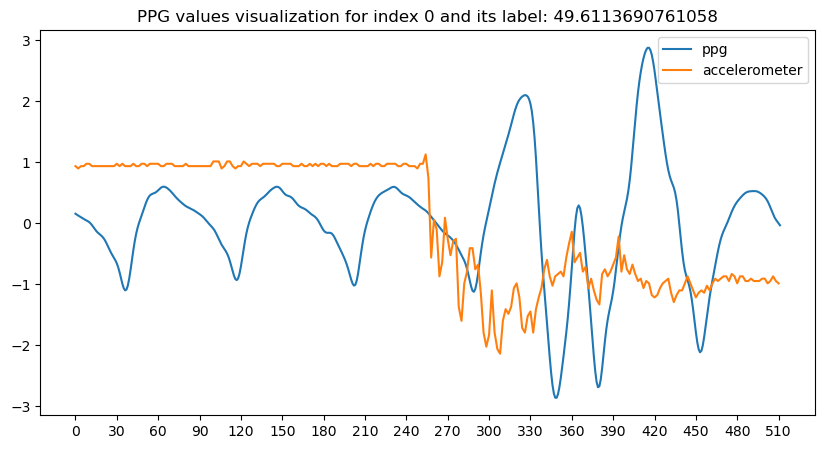

In [153]:
retrieve_values_display_ppg_label(all_subjects_csv, 0)
# retrieve_values_display_ppg_label(all_subjects_csv, 1)
# retrieve_values_display_ppg_label(all_subjects_csv, 2)
# retrieve_values_display_ppg_label(all_subjects_csv, 3)
# retrieve_values_display_ppg_label(all_subjects_csv, 4)
# retrieve_values_display_ppg_label(all_subjects_csv, 10)

### 5.11. Magnitude of accelerometer vectors

In [156]:
def magnitude(x, y, z):
    sq = math.sqrt(x**2 + y**2 + z**2)
    return sq
    
print(f'magnitude: {magnitude(3,4,-5)}')

magnitude: 7.0710678118654755


In [158]:
def retrieve_magnitude(segment, index):
    """
    Retrieve the magnitudes of the accelerometer vectors and display them in a line graph.
    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]
        
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one
    
    plt.figure(figsize=(10,5))
    plt.title(f"Magnitude of the accelerometer vectors and its label: {segment_label}")
    plt.plot(acc_first_seg_vector, label='magnitude accelerometer')
    plt.legend()
    plt.show()

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\3956994144.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one


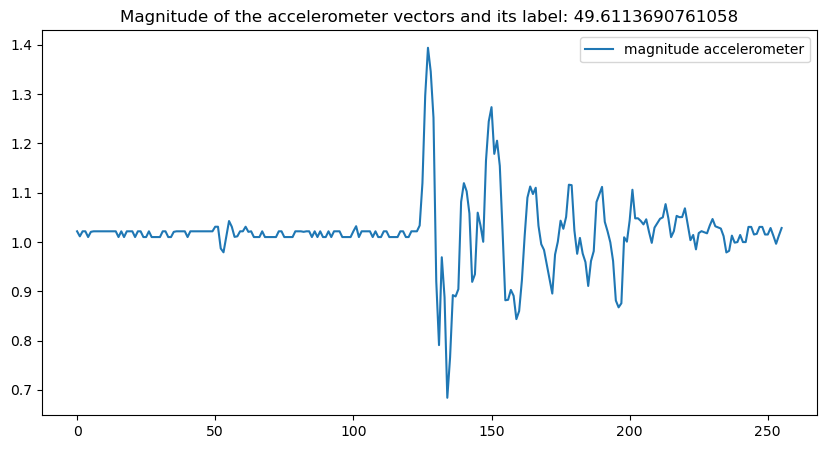

In [160]:
retrieve_magnitude(all_subjects_csv, 0)

In [162]:
def comparison_ppg_mag_acc(segment, index):
    """
    Compare the normalised PPG values and magnitudes of the accelerometer vectors and display them in a line graph.
    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]
    
    x_acc = np.arange(0, len(segment_ppg_values), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 
    
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one

    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    ppg_first_mean = np.mean(segment_ppg_values) # mean
    ppg_first_std = np.std(segment_ppg_values) # standard deviation
    ppg_first_normalized = (segment_ppg_values - ppg_first_mean) / ppg_first_std # z normalisation

    plt.figure(figsize=(10,5))
    plt.title(f"Comparison between normalised PPG and magnitude of acc and its label: {segment_label}")
    plt.plot(x_acc, acc_first_seg_vector, label='raw magnitude')
    plt.plot(ppg_first_normalized, label='ppg normalised')
    plt.xticks(np.arange(0, 512, 30))
    plt.legend()
    plt.show()

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\426823556.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one


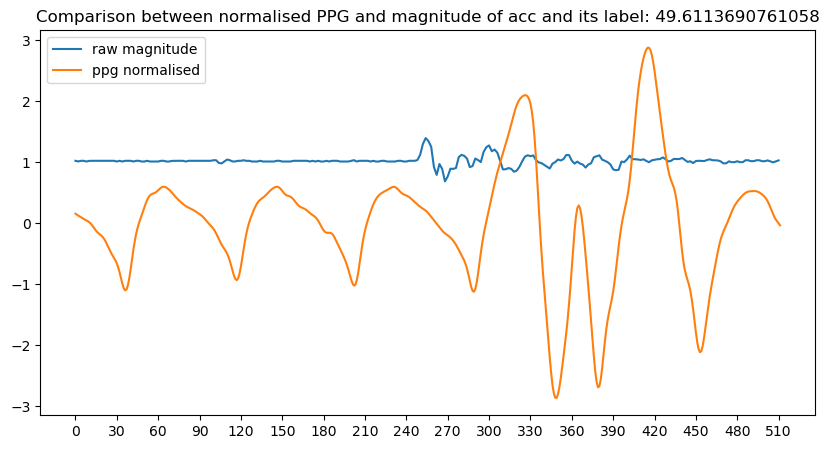

In [164]:
comparison_ppg_mag_acc(all_subjects_csv, 0)
# comparison_ppg_mag_acc(all_subjects_csv, 1)
# comparison_ppg_mag_acc(all_subjects_csv, 2)
# comparison_ppg_mag_acc(all_subjects_csv, 3)
# comparison_ppg_mag_acc(all_subjects_csv, 4)
# comparison_ppg_mag_acc(all_subjects_csv, 10)

In [166]:
def retrieve_rfft_acc(segment, index):
    """
    Retrieve the magnitudes of the accelerometer vectors and display them in a line graph.
    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]

    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one

    SAMPLE_RATE = 32  # Hertz, sampling rate of the acc sensor
    DURATION = 8  # Seconds that we segmented
    N = len(acc_first_seg_vector) # number of samples in 8 seconds
    acc_first_seg_vector_rfft = rfft(acc_first_seg_vector)
    acc_first_seg_vector_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)
    acc_first_seg_vector_irfft = irfft(acc_first_seg_vector_rfft)


    plt.figure(figsize=(10,5))
    plt.subplot(2,1,1)
    plt.title(f"rFFT of the accelerometer (its magnitude)")
    plt.plot(acc_first_seg_vector_rfftfreq, np.abs(acc_first_seg_vector_rfft))
    plt.show()
    plt.figure(figsize=(10,5))
    plt.subplot(2,1,2)
    plt.title(f"irFFT of the accelerometer (its magnitude)")
    plt.plot(acc_first_seg_vector_irfft)
    plt.show()

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\783556343.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one


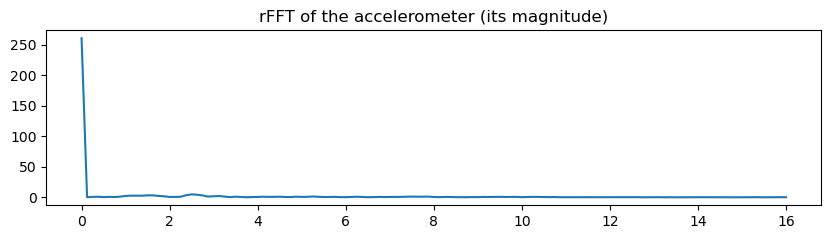

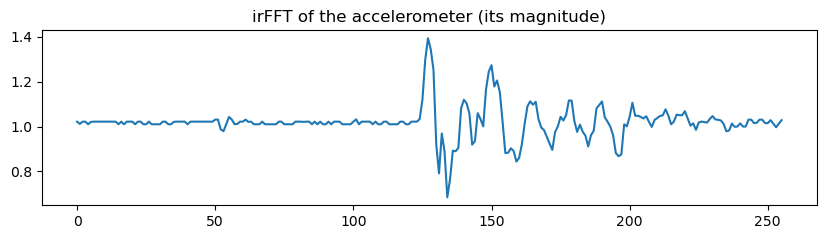

In [168]:
retrieve_rfft_acc(all_subjects_csv, 0)
# retrieve_rfft_acc(all_subjects_csv, 1)
# retrieve_rfft_acc(all_subjects_csv, 2)
# retrieve_rfft_acc(all_subjects_csv, 3)
# retrieve_rfft_acc(all_subjects_csv, 4)
# retrieve_rfft_acc(all_subjects_csv, 10)

In [170]:
def retrieve_mag_filt(segment, index):
    """
    Retrieve the magnitudes of the accelerometer vectors and display them in a line graph.
    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]
    
    x_acc = np.arange(0, len(segment_ppg_values), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 
    
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one

    # print(acc_first_seg_vector)
    SAMPLE_RATE = 32  # Hertz, sampling rate of the acc sensor
    DURATION = 8  # Seconds that we segmented
    N = len(acc_first_seg_vector) # number of samples in 8 seconds
    acc_first_seg_vector_rfft = rfft(acc_first_seg_vector)
    acc_first_seg_vector_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq, 'heartrate': acc_first_seg_vector_rfft}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered = df_acc_seg_rfft[df_acc_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    df_acc_seg_arr = np.array(df_acc_seg_rfft_filtered['heartrate'])
    acc_seg_irfft = irfft(df_acc_seg_arr)
    
    
    SAMPLE_RATE = 64  # Hertz, sampling rate of the ppg sensor
    DURATION = 8  # Seconds that we segmented
    N = len(segment_ppg_values) # number of samples in 8 seconds
    ppg_seg_vector_rfft = rfft(segment_ppg_values)
    ppg_seg_vector_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_ppg_seg_rfft = pd.DataFrame({'frequency': ppg_seg_vector_rfftfreq, 'heartrate': ppg_seg_vector_rfft}) # creating a new df for the rFFT

    df_ppg_seg_rfft_filtered = df_ppg_seg_rfft[df_ppg_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    df_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['heartrate'])
    ppg_seg_irfft = irfft(df_ppg_seg_arr)
    
#     x_acc = np.arange(0, len(segment_ppg_values), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 
            
    acc_irfft_mean = np.mean(acc_seg_irfft) # mean
    acc_irfft_std = np.std(acc_seg_irfft) # standard deviation
    acc_irfft_normalized = (acc_seg_irfft - acc_irfft_mean) / acc_irfft_std # z normalisation

    ppg_irfft_mean = np.mean(ppg_seg_irfft) # mean
    ppg_irfft_std = np.std(ppg_seg_irfft) # standard deviation
    ppg_irfft_normalized = (ppg_seg_irfft - ppg_irfft_mean) / ppg_irfft_std # z normalisation
    
    ppg_filtered = ppg_irfft_normalized - acc_irfft_normalized
    
    # plt.subplot(5,1,1)
    # plt.title('PPG rFFT')
    # plt.plot(df_ppg_seg_rfft_filtered['frequency'], np.abs(df_ppg_seg_rfft_filtered['heartrate']))
    # plt.show()
    # plt.subplot(5,1,2)
    # plt.title('PPG irFFT')
    # plt.plot(ppg_seg_irfft)
    # plt.show()
    # plt.subplot(5,1,3)
    # plt.plot(df_acc_seg_rfft_filtered['frequency'], np.abs(df_acc_seg_rfft_filtered['heartrate']))
    # plt.title('rFFT Acc')
    # plt.show()
    # plt.subplot(5,1,4)
    # plt.title('irFFT Acc')
    # plt.plot(acc_seg_irfft)
    # plt.show()
    # plt.subplot(5,1,5)
    plt.figure(figsize=(10,5))
    plt.title('irFFT Acc and irFFT PPG')
    # plt.plot(acc_irfft_normalized, label='acc')
    plt.plot(ppg_filtered,  label='ppg')
    plt.legend()
    plt.show()
# retrieve_mag_filt(all_subjects_csv, 0)

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\3542328594.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one


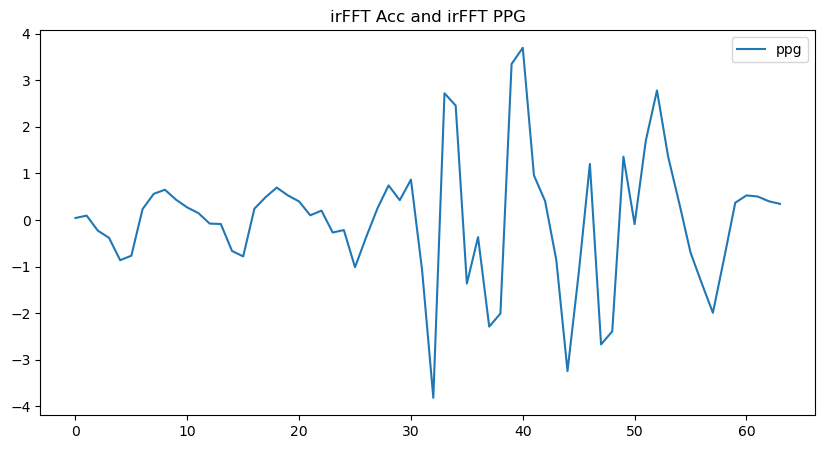

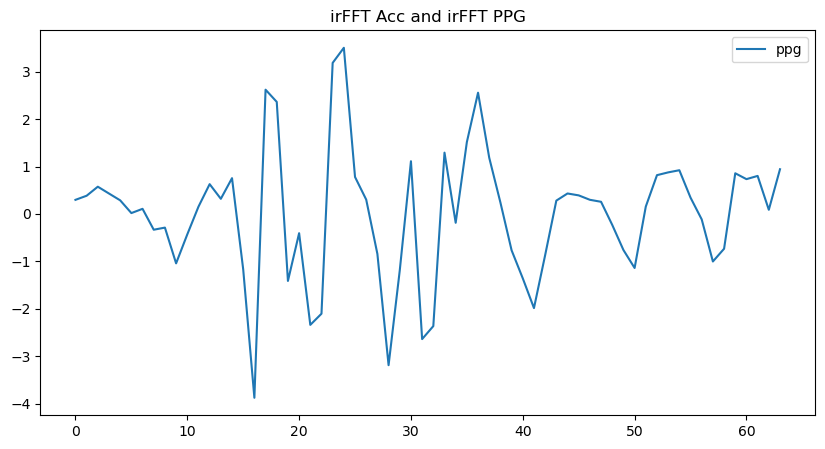

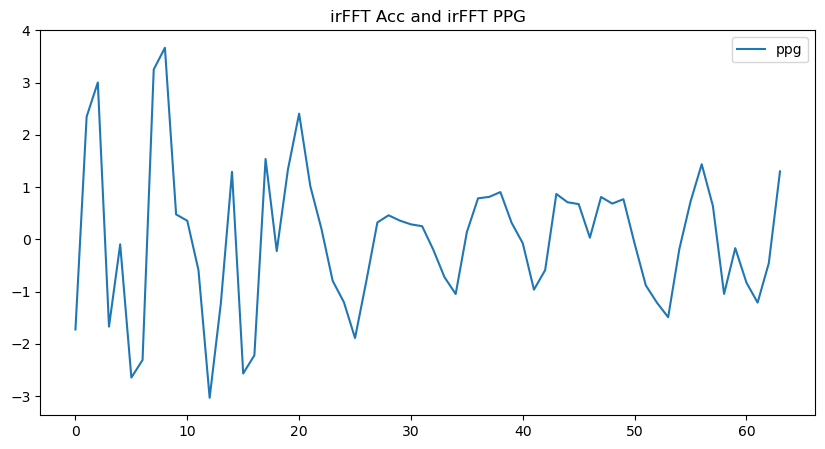

In [172]:
retrieve_mag_filt(all_subjects_csv, 0)
retrieve_mag_filt(all_subjects_csv, 1)
retrieve_mag_filt(all_subjects_csv, 2)

### 5.12. Checking PPG filters

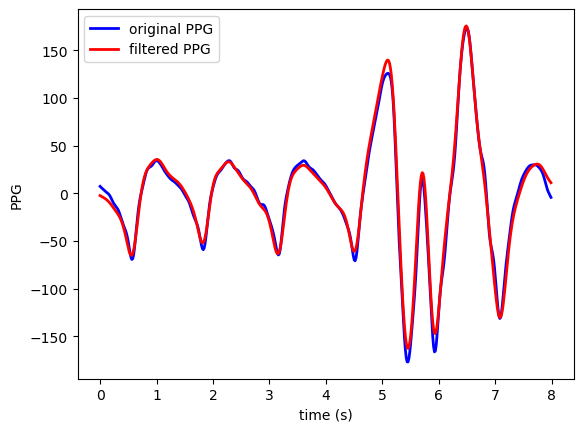

In [175]:
# got from https://peterhcharlton.github.io/bsp-book/tutorial/notebooks/signal-filtering.html
def signal_filt(segment, index):
    import scipy.signal as sp
    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]
    
    fs = 64
    lpf_cutoff = 0.25 
    hpf_cutoff = 4
    sos_ppg = sp.butter(3,
                        [lpf_cutoff, hpf_cutoff],
                        btype = 'bp',
                        analog = False,
                        output = 'sos',
                        fs = fs)

    ppg_filt = sp.sosfiltfilt(sos_ppg, segment_ppg_values)
    fig, ax = plt.subplots()

    t = np.arange(0, len(ppg_filt))/fs

    ax.plot(t, segment_ppg_values,
            linewidth=2.0,
            color = 'blue',
            label = "original PPG")

    ax.plot(t, ppg_filt,
            linewidth=2.0,
            color = 'red',
            label = "filtered PPG")

    # ax.set(xlim=(0, n_seconds_to_load))
    plt.xlabel('time (s)')
    plt.ylabel('PPG')
    # plt.xlim([20, 45])

    plt.legend()
    plt.show()
signal_filt(all_subjects_csv, 0)

In [177]:
# got from https://www.samproell.io/posts/signal/peak-finding-python-js/
def peak_filt(segment, index):
    from scipy import signal
    """
    Retrieve the magnitudes of the accelerometer vectors and display them in a line graph.
    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]
    
    fs = 64
    lpf_cutoff = 0.25 
    hpf_cutoff = 4
    sos = signal.iirfilter(10, Wn=[lpf_cutoff, hpf_cutoff], fs=fs, btype="bandpass",
                             ftype="butter", output="sos")
    ppg_filt = signal.sosfilt(sos, segment_ppg_values)
    
    # find peaks in noisy signal using wavelet decomposition
    cwt_peaks = signal.find_peaks_cwt(segment_ppg_values, widths=np.arange(5, 15))

#     t = np.arange(0, len(ppg_filt))/fs
    
#     fig, ax = plt.subplots()

#     ax.plot(segment_ppg_values,
#             linewidth=2.0,
#             color = 'blue',
#             label = "original PPG")

#     ax.plot(ppg_filt,
#             linewidth=2.0,
#             color = 'red',
#             label = "filtered PPG")

#     # ax.set(xlim=(0, n_seconds_to_load))
#     # plt.xlabel('time (s)')
#     # plt.ylabel('PPG')
#     # plt.xlim([20, 45])

#     plt.legend()
#     plt.show()
peak_filt(all_subjects_csv, 0)

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\2313452924.py:37: DeprecationWarning: Using medfilt with arrays of dtype object is deprecated in SciPy 1.11 and will be removed in SciPy 1.13
  ppg_filt_med = signal.medfilt(ppg_filt, window_size)


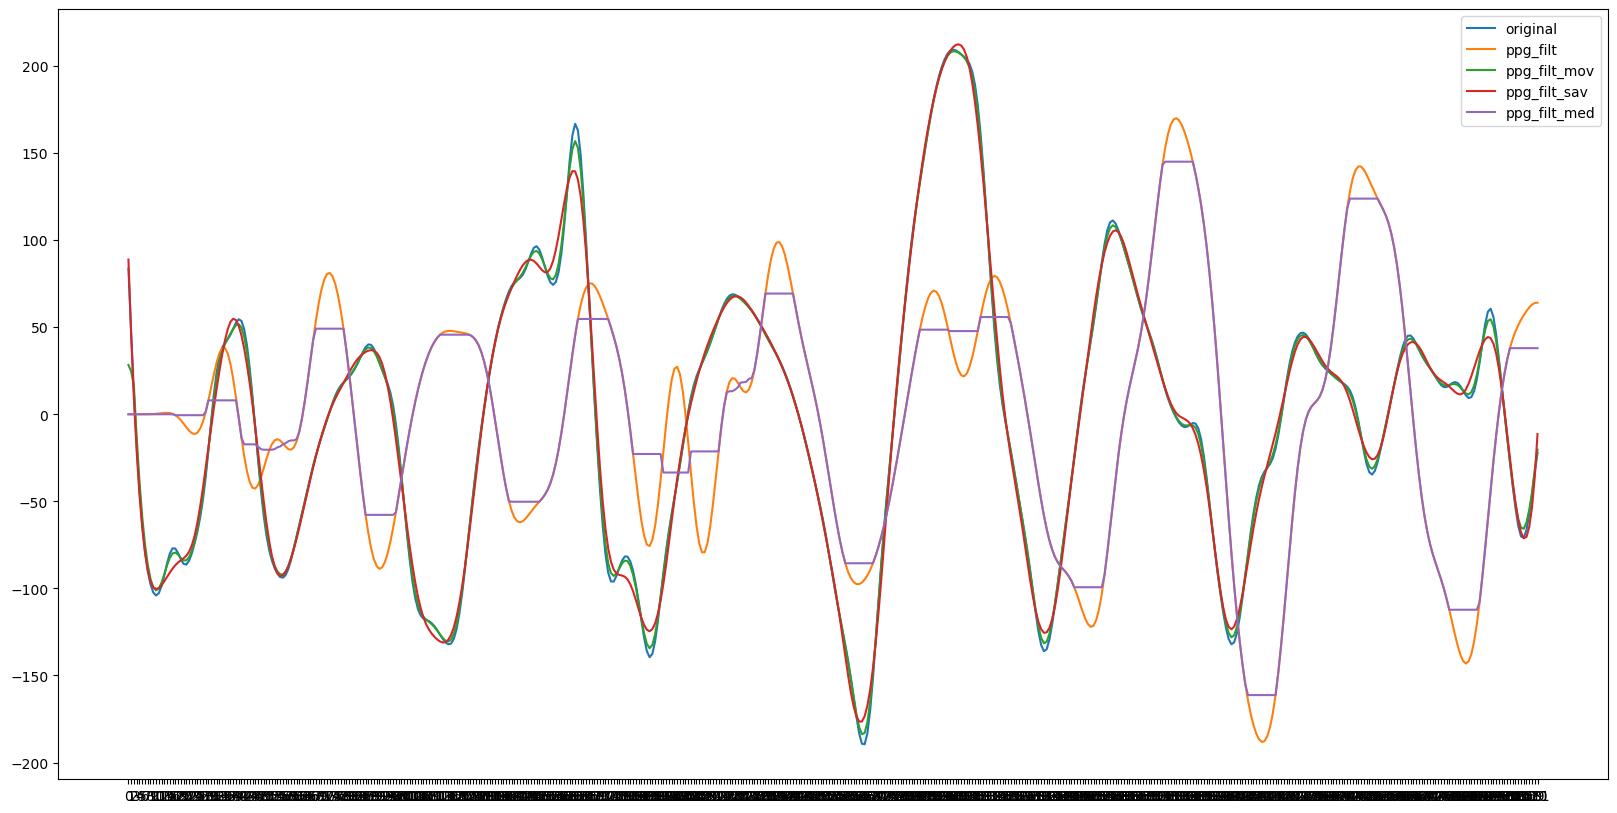

In [179]:
def peak_filt_smooth(segment, index):
    from scipy import signal
    import numpy as np

    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]

    fs = 64

    # Choose a filter type and adjust parameters accordingly
    # Option 1: Butterworth bandpass filter with adjusted low-pass cutoff
    lpf_cutoff = 0.75  # Increased from 0.25 for smoother graph
    hpf_cutoff = 4
    sos = signal.iirfilter(10, Wn=[lpf_cutoff, hpf_cutoff], fs=fs, btype="bandpass",
                          ftype="butter", output="sos")
    ppg_filt = signal.sosfilt(sos, segment_ppg_values)
    

    # Option 2: Moving average filter
    window_size = 5  # Adjust window size for desired smoothing level
    ppg_filt_mov = np.convolve(segment_ppg_values, np.ones(window_size) / window_size, mode='same')

    # Option 3: Savitzky-Golay filter
    window_size = 21  # Adjust window size and polynomial degree for desired smoothing
    poly_degree = 3
    ppg_filt_sav = signal.savgol_filter(segment_ppg_values, window_length=window_size, polyorder=poly_degree)

    # Further smoothing after filtering (optional)
    # Option 4: Gaussian smoothing
    sigma = 2  # Adjust sigma for desired level of smoothing
    # ppg_filt_gau = signal.gaussian_filter(ppg_filt, sigma)

    #   # Option 5: Median filter
    #   window_size = 5  # Adjust window size for desired level of smoothing
    ppg_filt_med = signal.medfilt(ppg_filt, window_size)

    # Find peaks in the filtered signal
    cwt_peaks = signal.find_peaks_cwt(ppg_filt, widths=np.arange(5, 15))
    
    plt.figure(figsize=(20,10))
    plt.plot(segment_ppg_values, label='original')
    plt.plot(ppg_filt, label='ppg_filt')
    plt.plot(ppg_filt_mov, label='ppg_filt_mov')
    plt.plot(ppg_filt_sav, label='ppg_filt_sav')
    # plt.plot(ppg_filt_gau, label='ppg_filt_gau')
    plt.plot(ppg_filt_med, label='ppg_filt_med')
    plt.legend()
    plt.show()

    
    # ... (rest of your code for peak analysis and visualization

peak_filt_smooth(all_subjects_csv, 8)

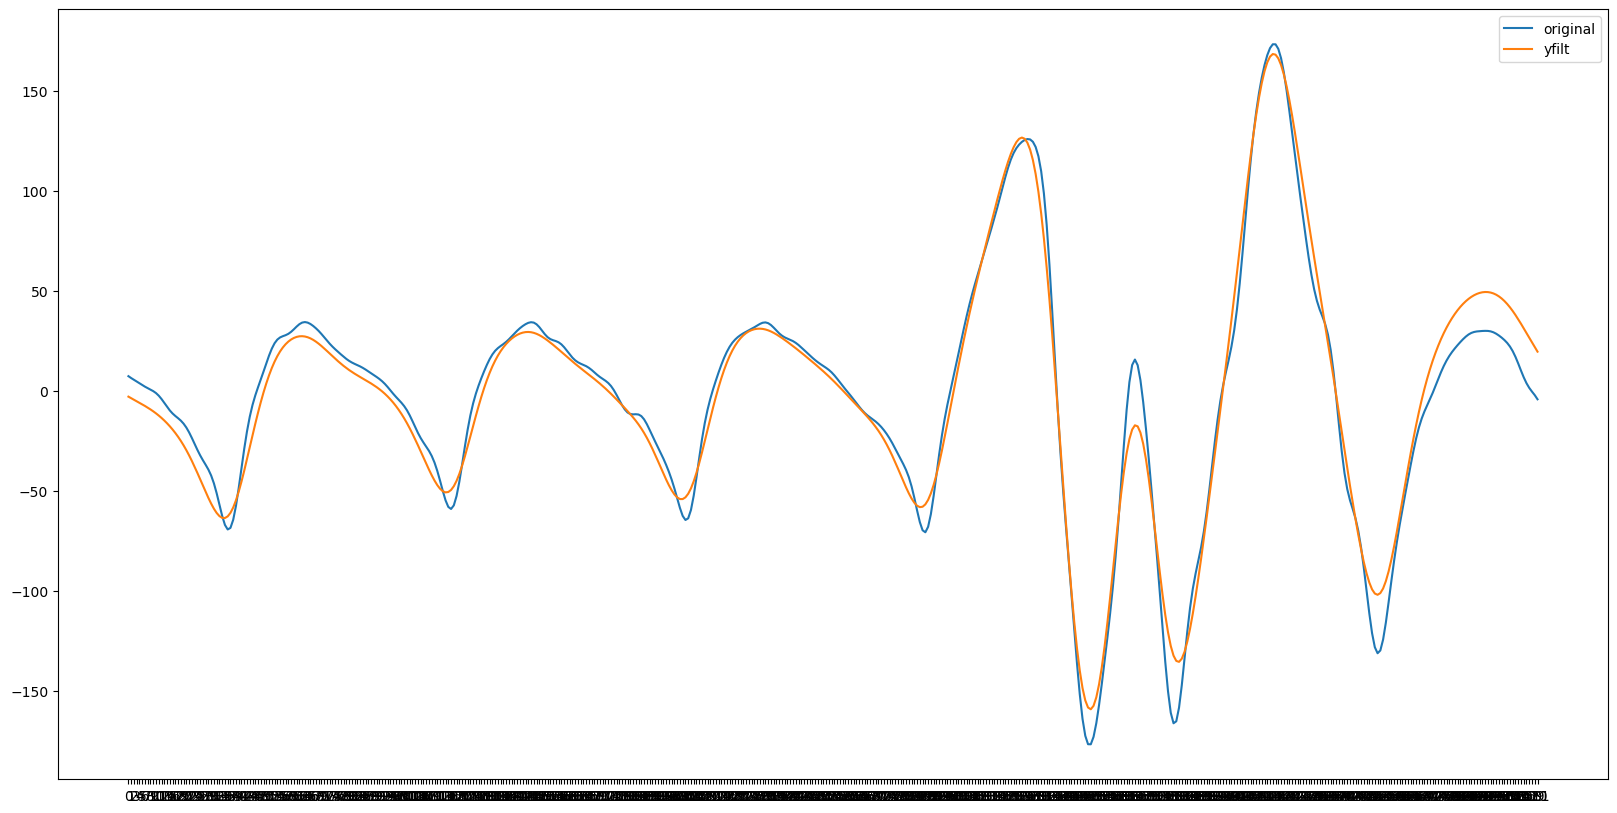

In [181]:
def peak_filt_smooth(segment, index):
    from scipy import signal
    import numpy as np

    """
    Retrieve the magnitudes of the accelerometer vectors, filter and smooth the PPG signal,
    and display them in a line graph.

    segment = subject dataframe
    index = index of the 8-second segment
    """

    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]

    fs = 64

    # Choose a filter type and adjust parameters accordingly
    # Option 1: Butterworth bandpass filter with adjusted low-pass cutoff
    lpf_cutoff = 0.1  # Increased from 0.25 for smoother graph
    hpf_cutoff = 2.25
    sos = signal.iirfilter(2, Wn=[0.1, 2.5], fs=fs, btype="bandpass",
                                 ftype="butter", output="sos")
    yfilt = signal.sosfiltfilt(sos, segment_ppg_values)
    

    # Option 2: Moving average filter
#     window_size = 5  # Adjust window size for desired smoothing level
#     ppg_filt_mov = np.convolve(segment_ppg_values, np.ones(window_size) / window_size, mode='same')

#     # Option 3: Savitzky-Golay filter
#     window_size = 21  # Adjust window size and polynomial degree for desired smoothing
#     poly_degree = 3
#     ppg_filt_sav = signal.savgol_filter(segment_ppg_values, window_length=window_size, polyorder=poly_degree)

#     # Further smoothing after filtering (optional)
#     # Option 4: Gaussian smoothing
#     sigma = 2  # Adjust sigma for desired level of smoothing
#     # ppg_filt_gau = signal.gaussian_filter(ppg_filt, sigma)

#     #   # Option 5: Median filter
#     #   window_size = 5  # Adjust window size for desired level of smoothing
#     ppg_filt_med = signal.medfilt(ppg_filt, window_size)

#     # Find peaks in the filtered signal
#     cwt_peaks = signal.find_peaks_cwt(ppg_filt, widths=np.arange(5, 15))
    
    plt.figure(figsize=(20,10))
    plt.plot(segment_ppg_values, label='original')
    # plt.plot(ppg_filt, label='ppg_filt')
    plt.plot(yfilt, label='yfilt')
    # plt.plot(ppg_filt_sav, label='ppg_filt_sav')
    # plt.plot(ppg_filt_gau, label='ppg_filt_gau')
    # plt.plot(ppg_filt_med, label='ppg_filt_med')
    plt.legend()
    plt.show()

    
    # ... (rest of your code for peak analysis and visualization

peak_filt_smooth(all_subjects_csv, 0)

[135 726 267 230 525 657 476 163 321 220]


C:\Users\silva\AppData\Local\Temp\ipykernel_21324\2291088230.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one


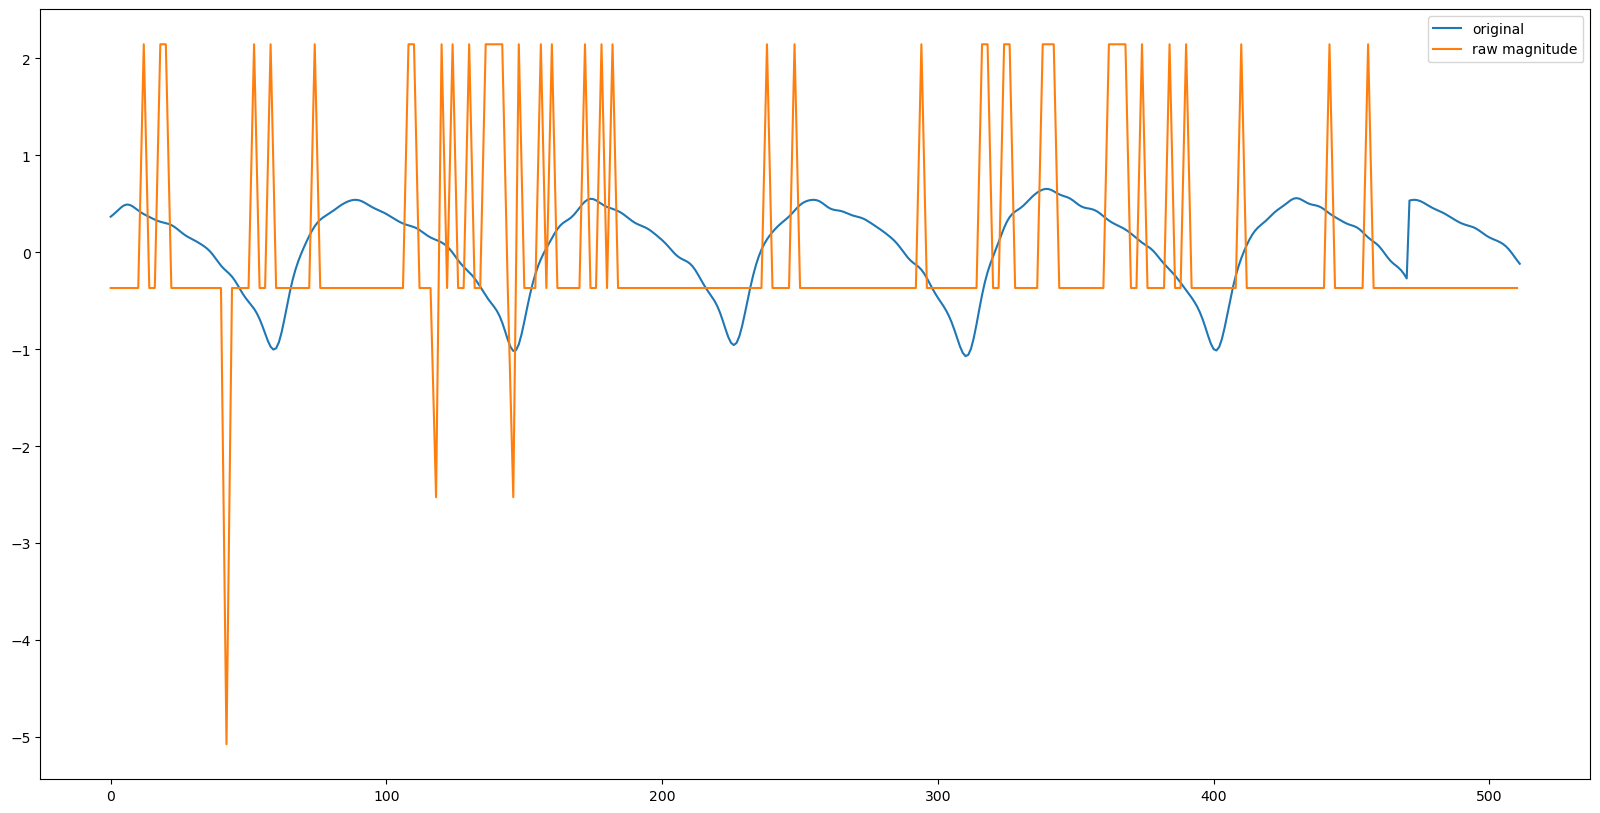

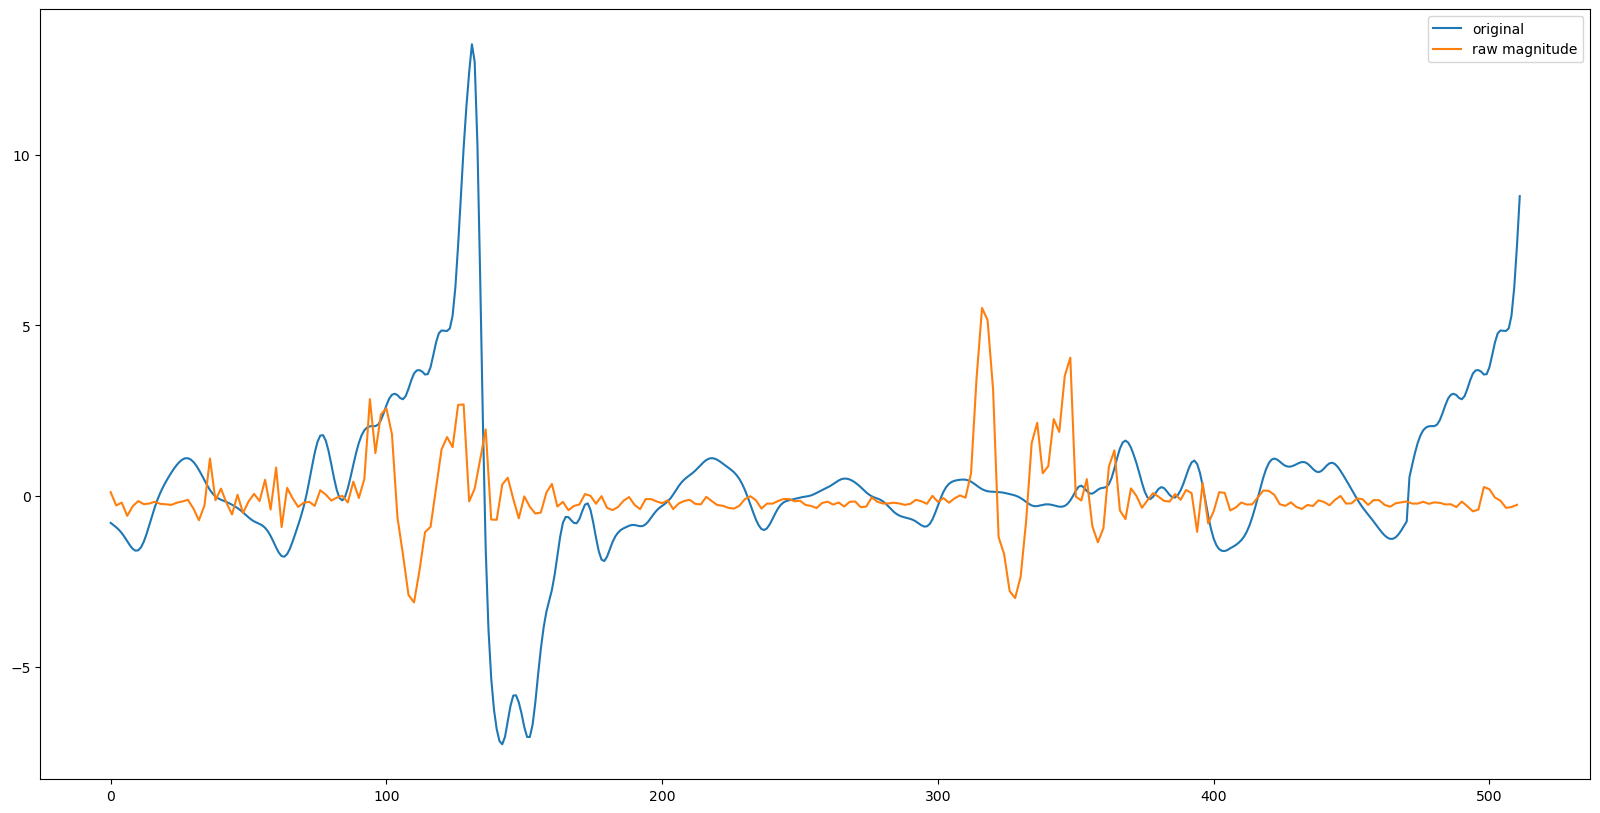

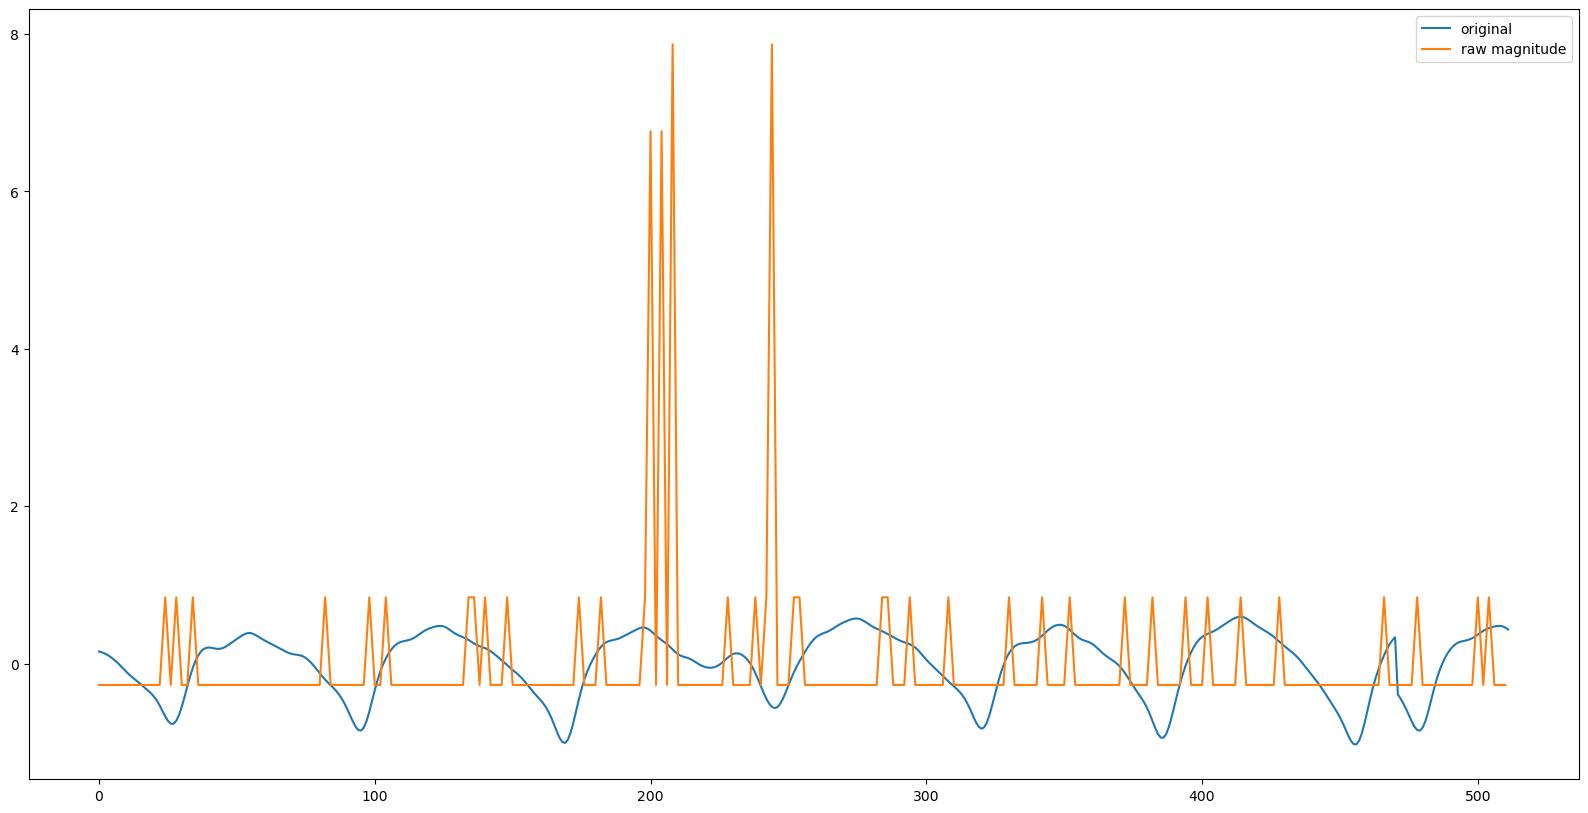

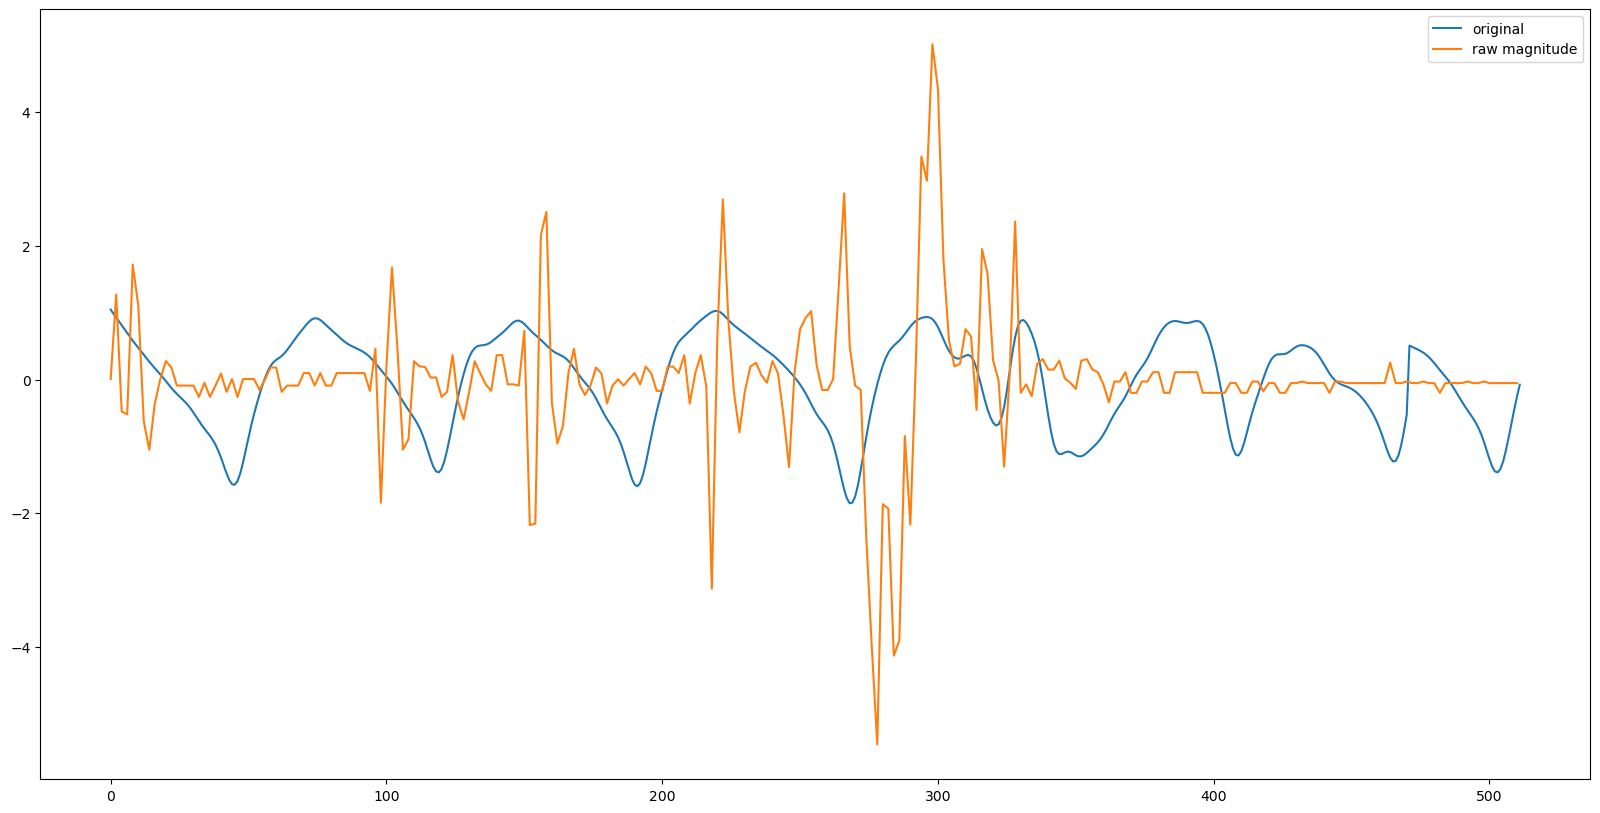

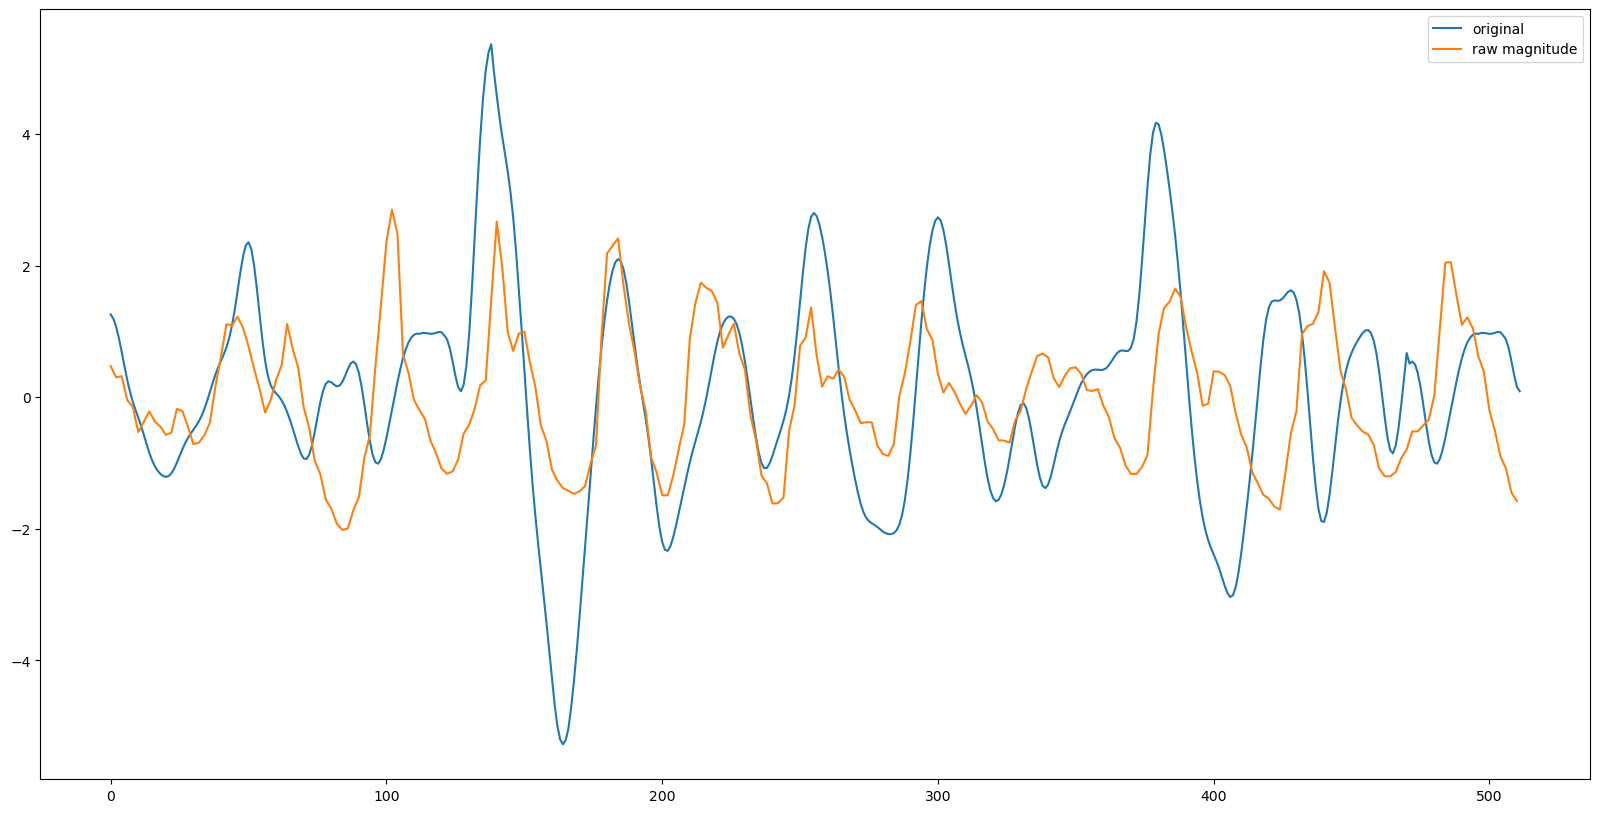

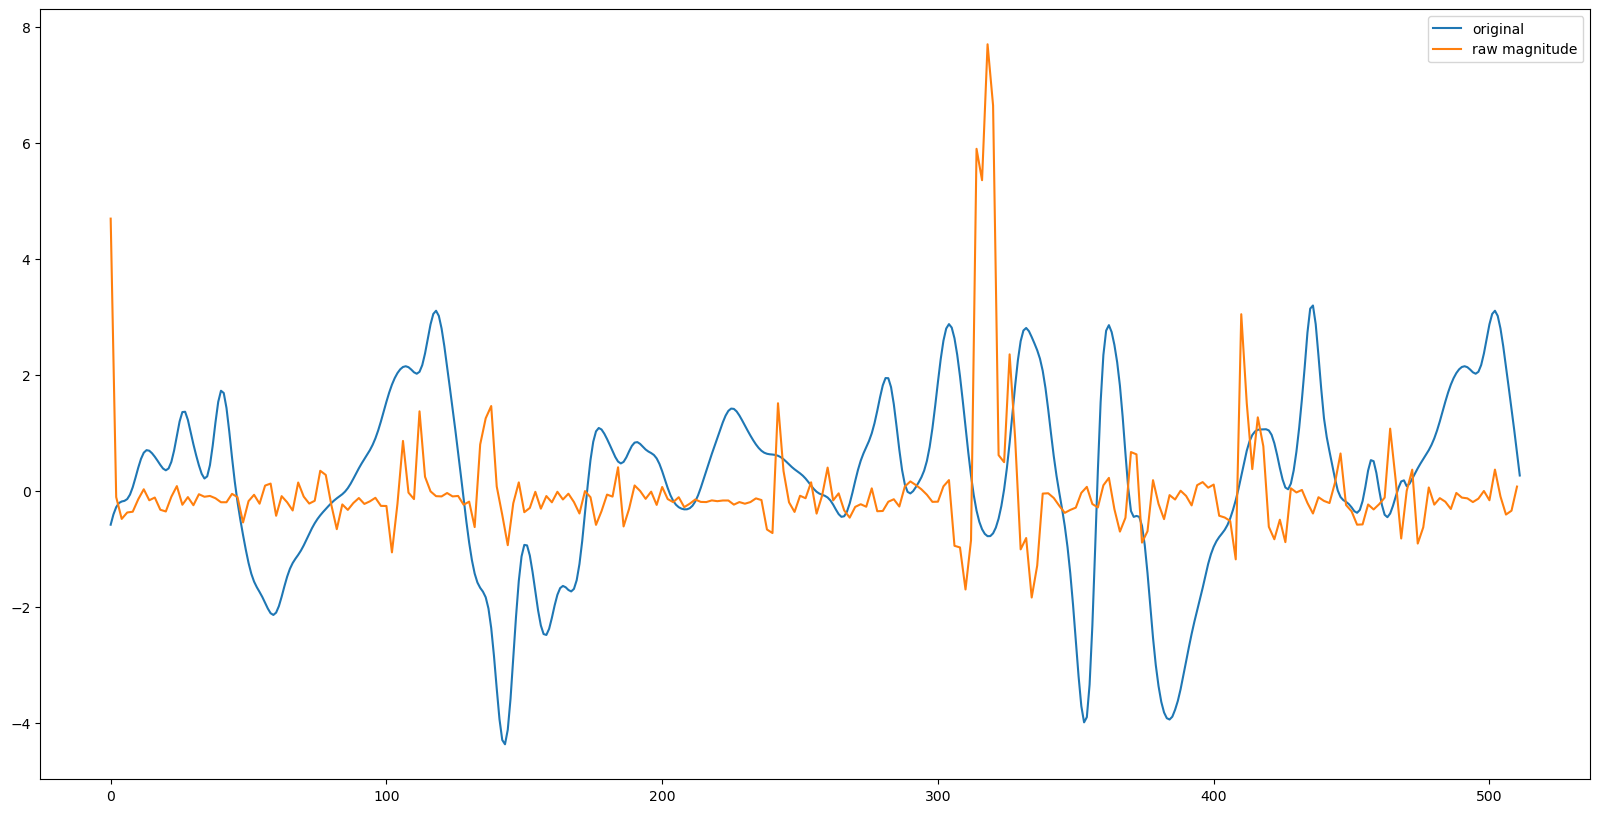

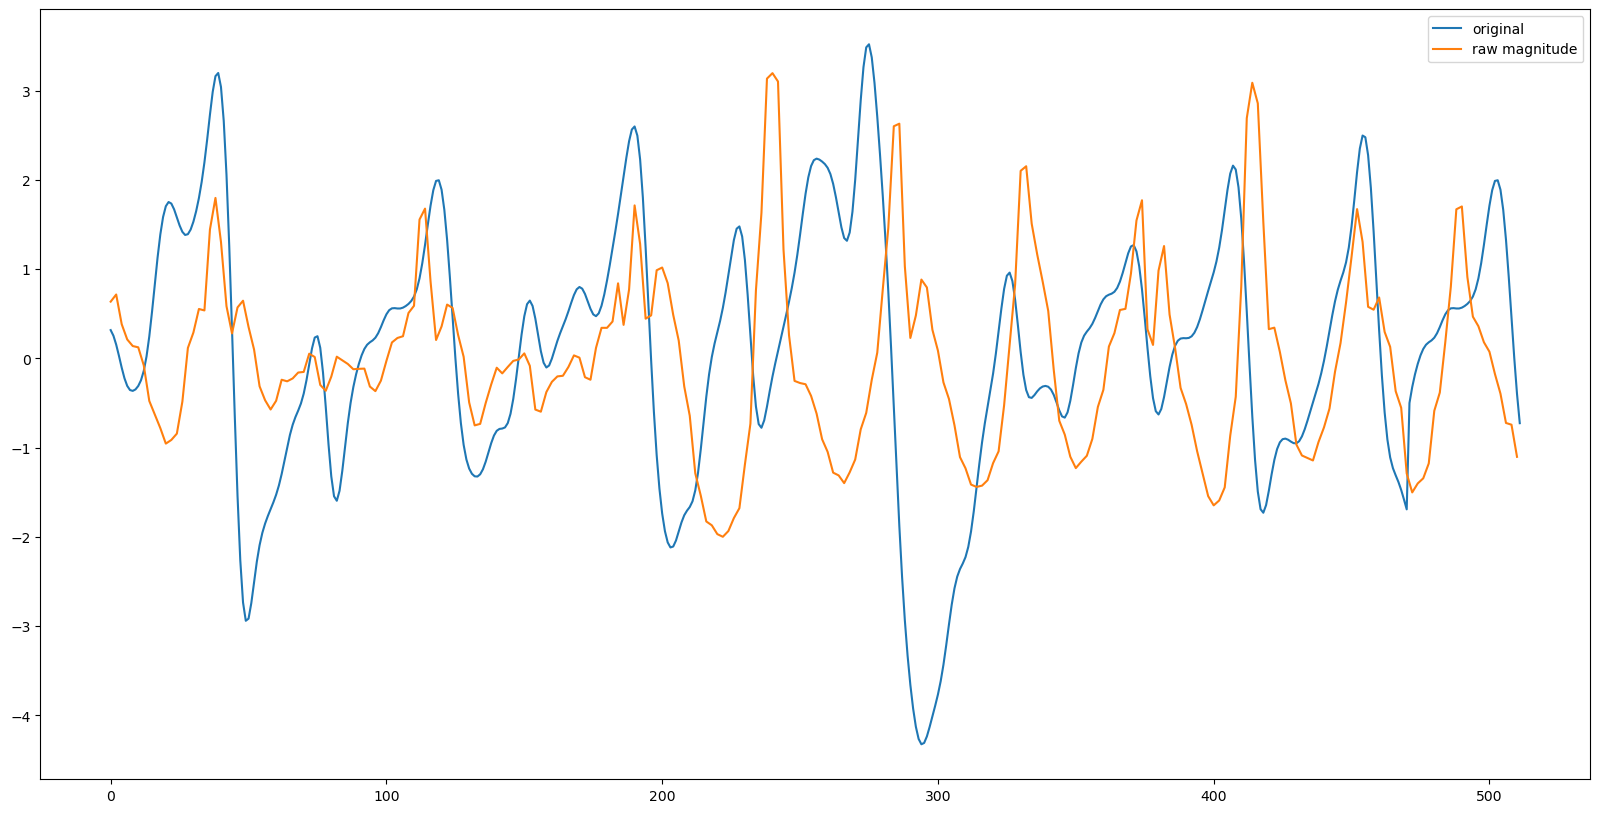

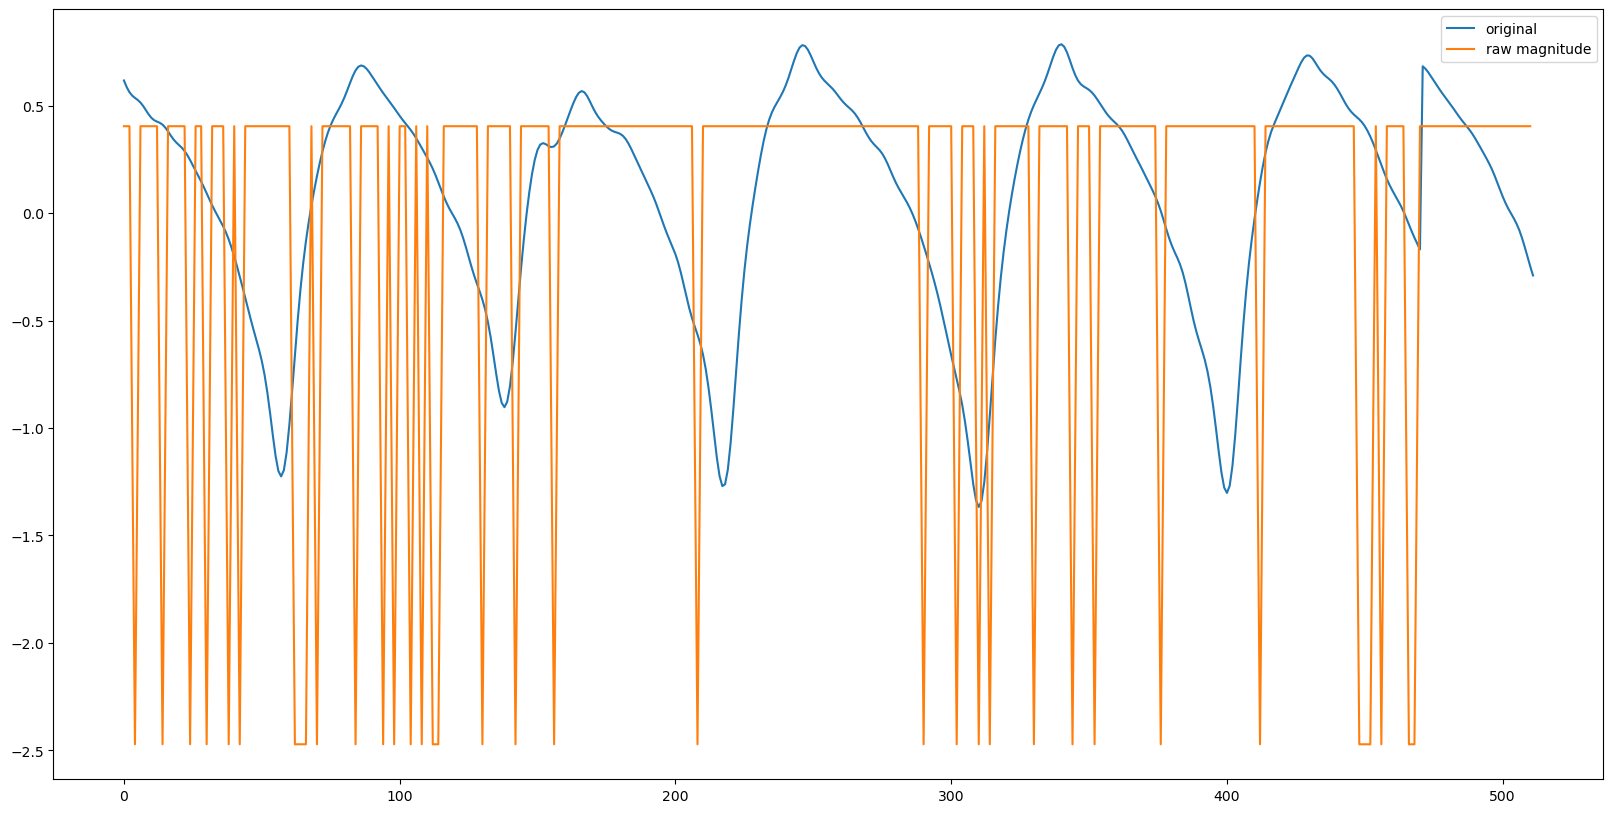

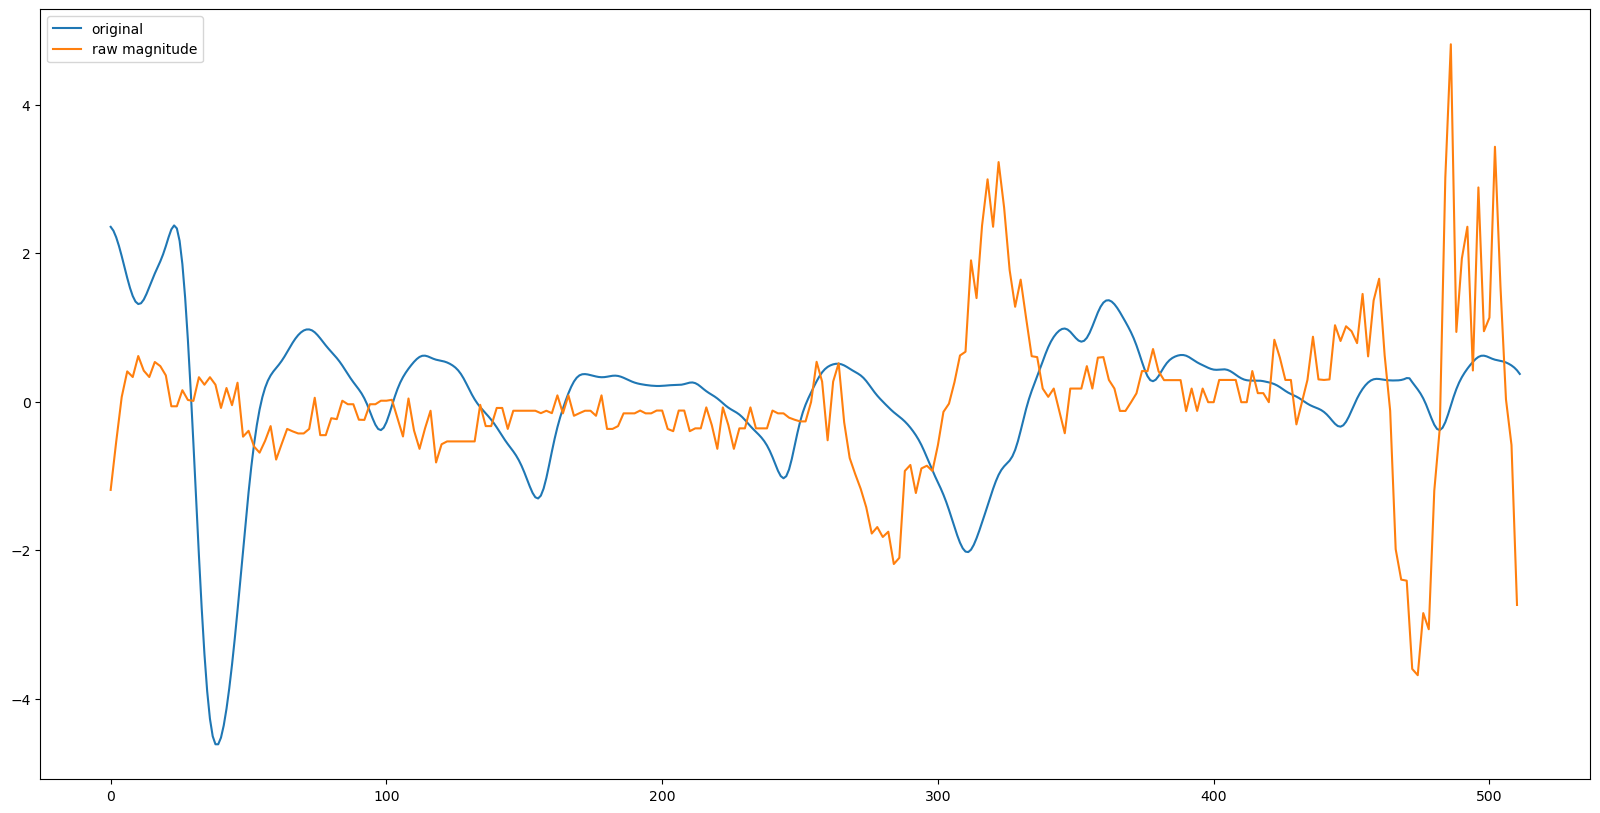

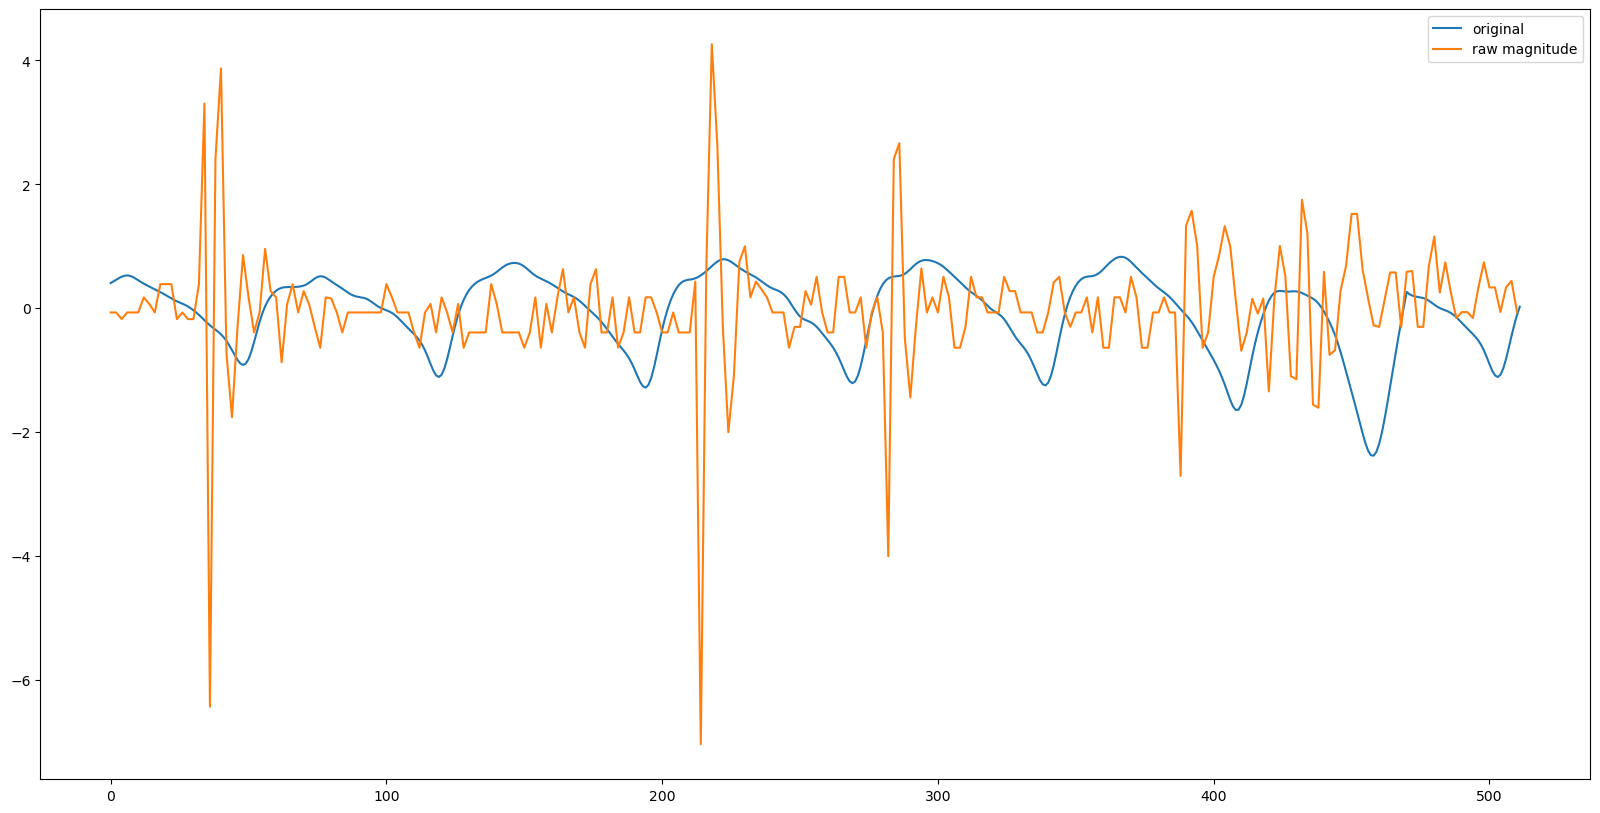

In [183]:
def peak_filt_smooth(segment, index):
    from scipy import signal
    import numpy as np

    """
    Retrieve the magnitudes of the accelerometer vectors, filter and smooth the PPG signal,
    and display them in a line graph.

    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_ppg_full = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 42:513]
    second_seg_ppg = segment.iloc[index+1, 1:42]
    segment_acc_values = segment.iloc[index, 513:1281]
    
    fs = 64

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    x_acc = np.arange(0, len(segment_ppg_full), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 
    
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one
        
    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_fullt_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - ppg_first_mean) / ppg_first_std # z normalisation
    

    # Choose a filter type and adjust parameters accordingly
    # Option 1: Butterworth bandpass filter with adjusted low-pass cutoff
    lpf_cutoff = 0.1  # Increased from 0.25 for smoother graph
    hpf_cutoff = 2.25
    sos = signal.iirfilter(2, Wn=[0.1, 2.5], fs=fs, btype="bandpass",
                                 ftype="butter", output="sos")
    yfilt = signal.sosfiltfilt(sos, segment_ppg_values)
    
    plt.figure(figsize=(20,10))
    plt.plot(segment_ppg_full_normalized, label='original')
    plt.plot(x_acc, x_acc_normalized, label='raw magnitude')
    plt.legend()
    plt.show()

    
    # ... (rest of your code for peak analysis and visualization

arr = np.random.randint(0,1000,10)
print(arr)
for i in arr:
    peak_filt_smooth(all_subjects_csv, i)
# peak_filt_smooth(all_subjects_csv, 105)
# peak_filt_smooth(all_subjects_csv, 250)

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\1542484709.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one


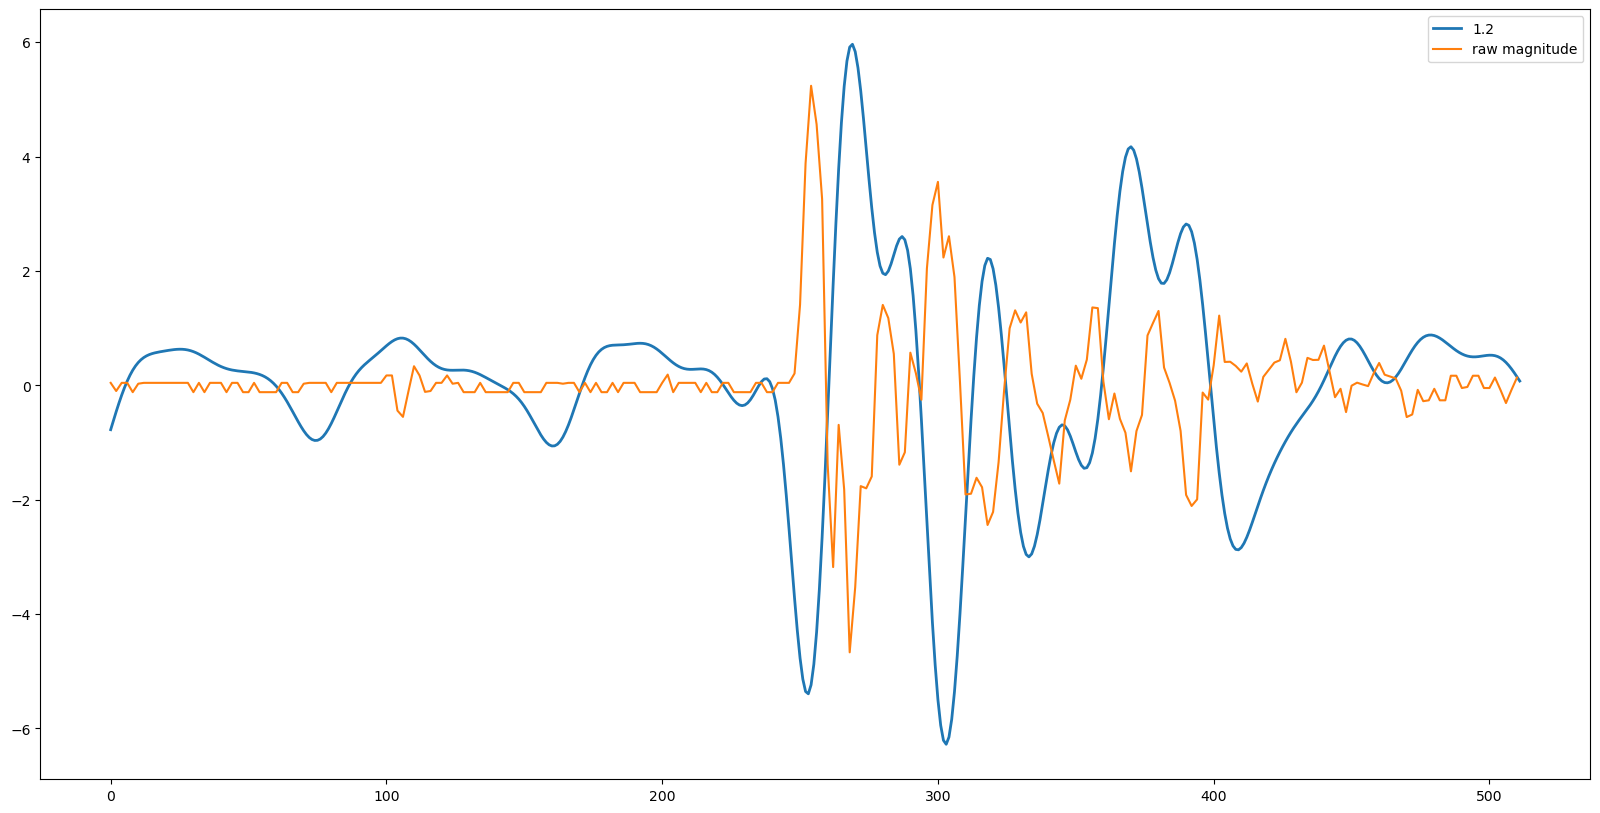

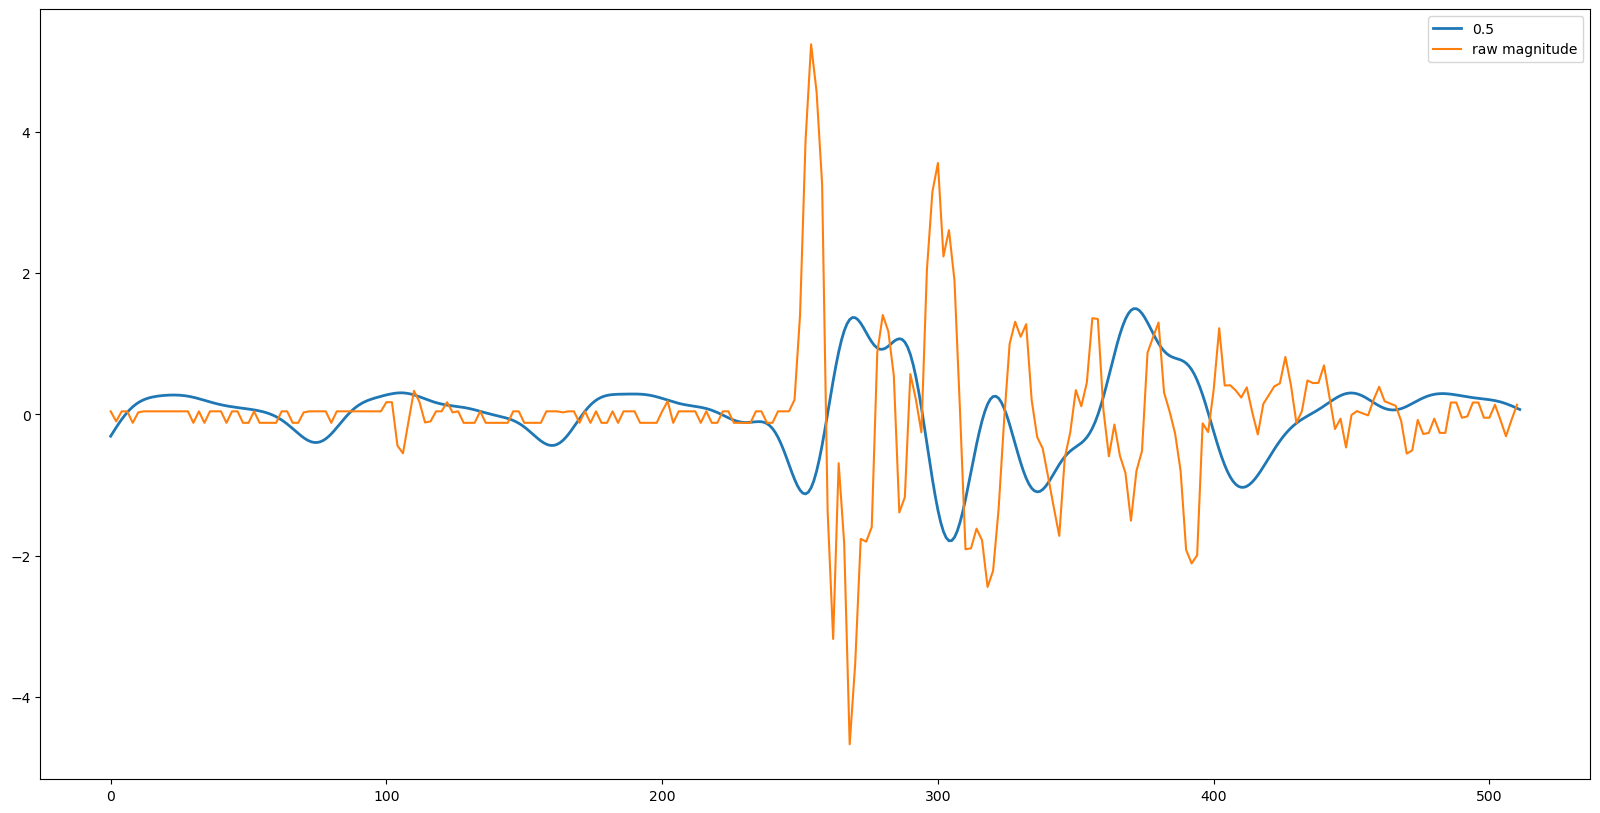

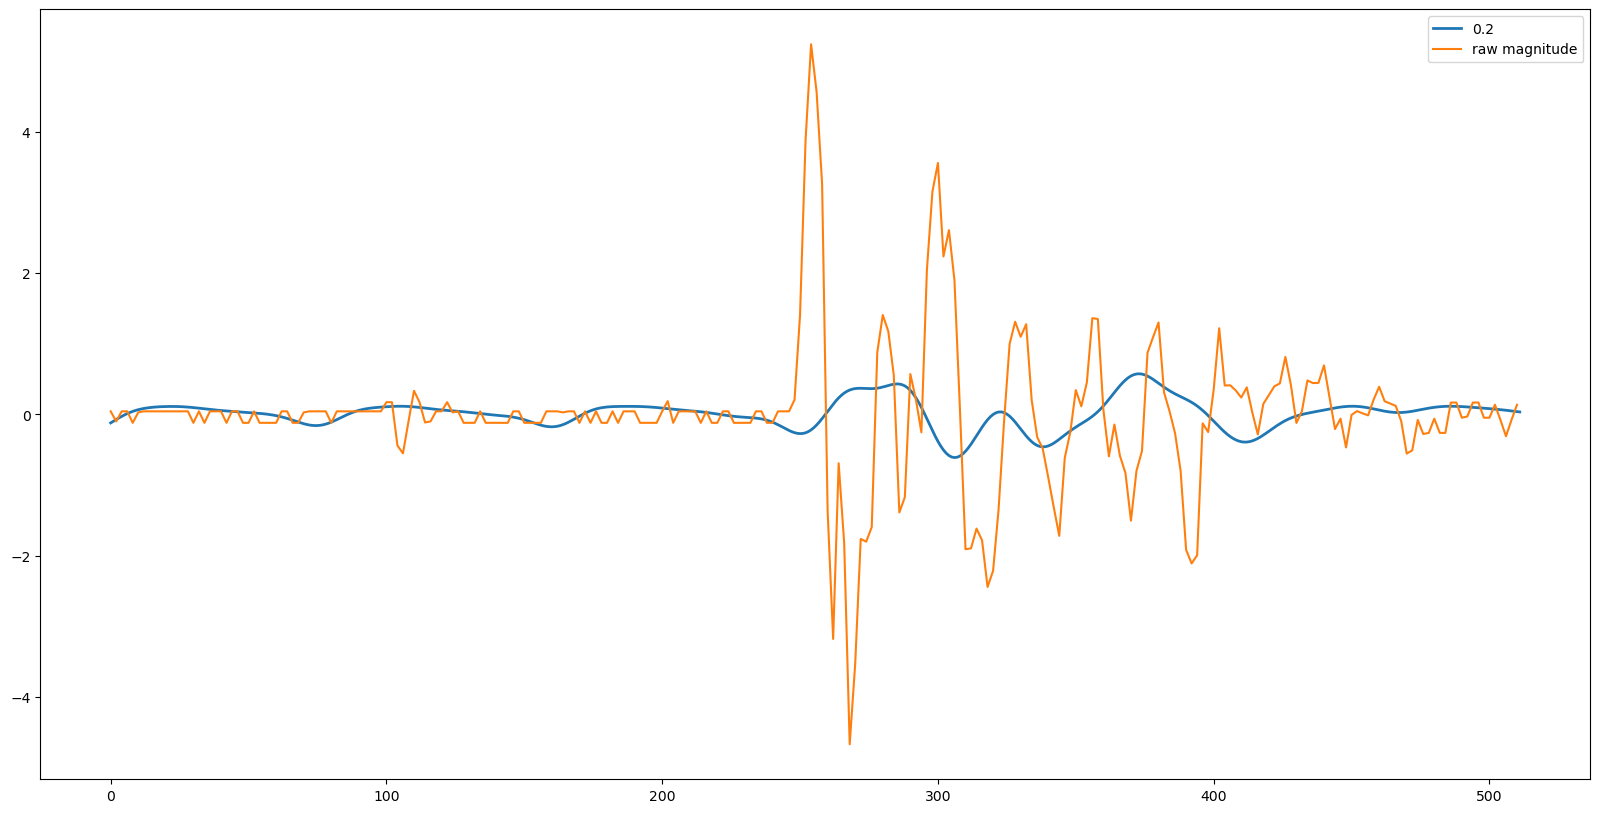

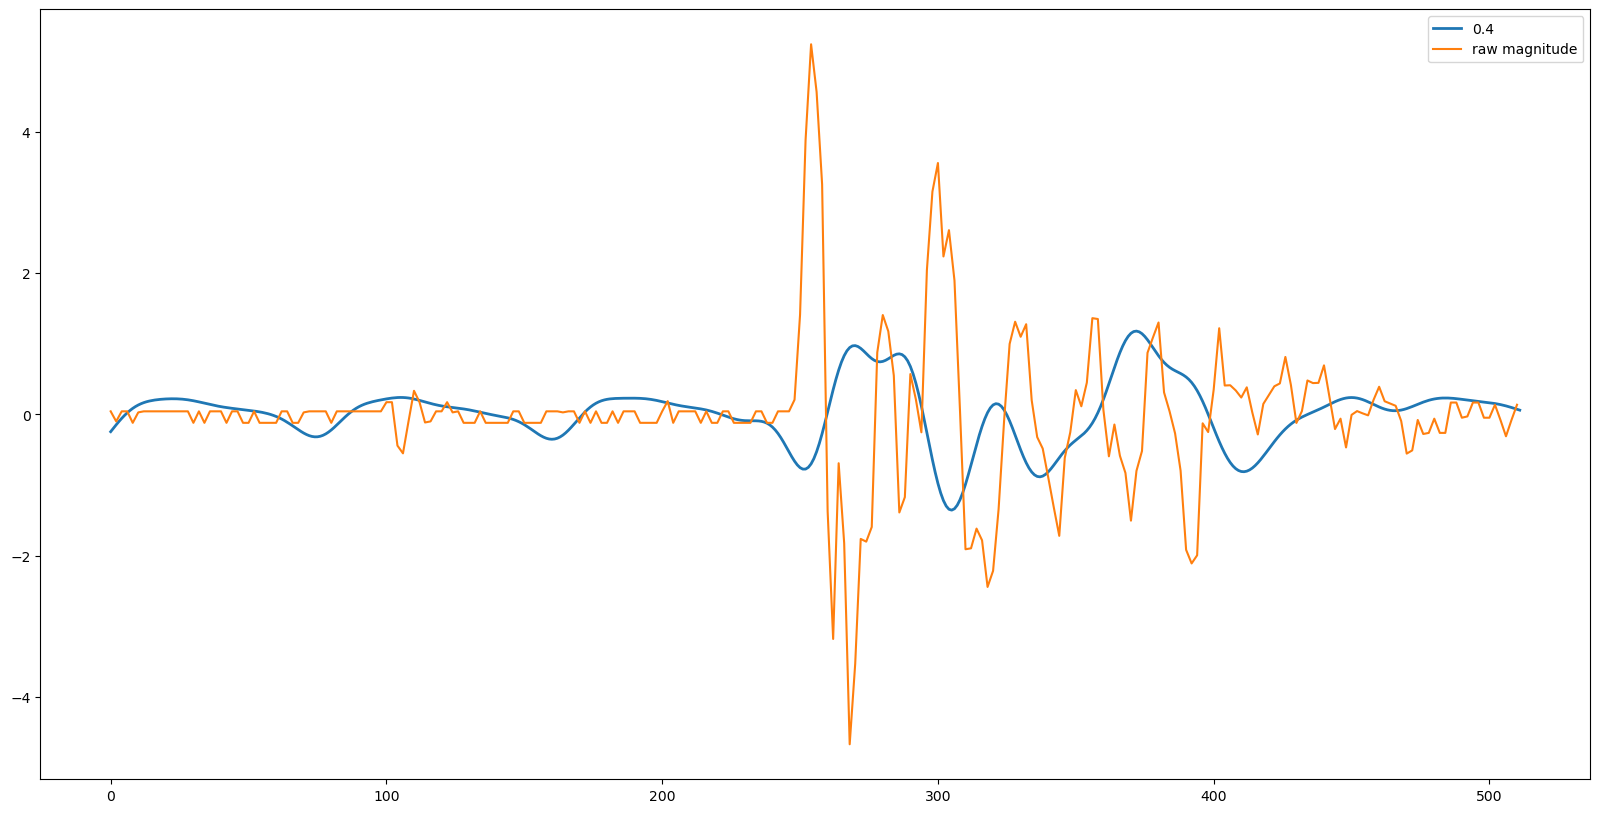

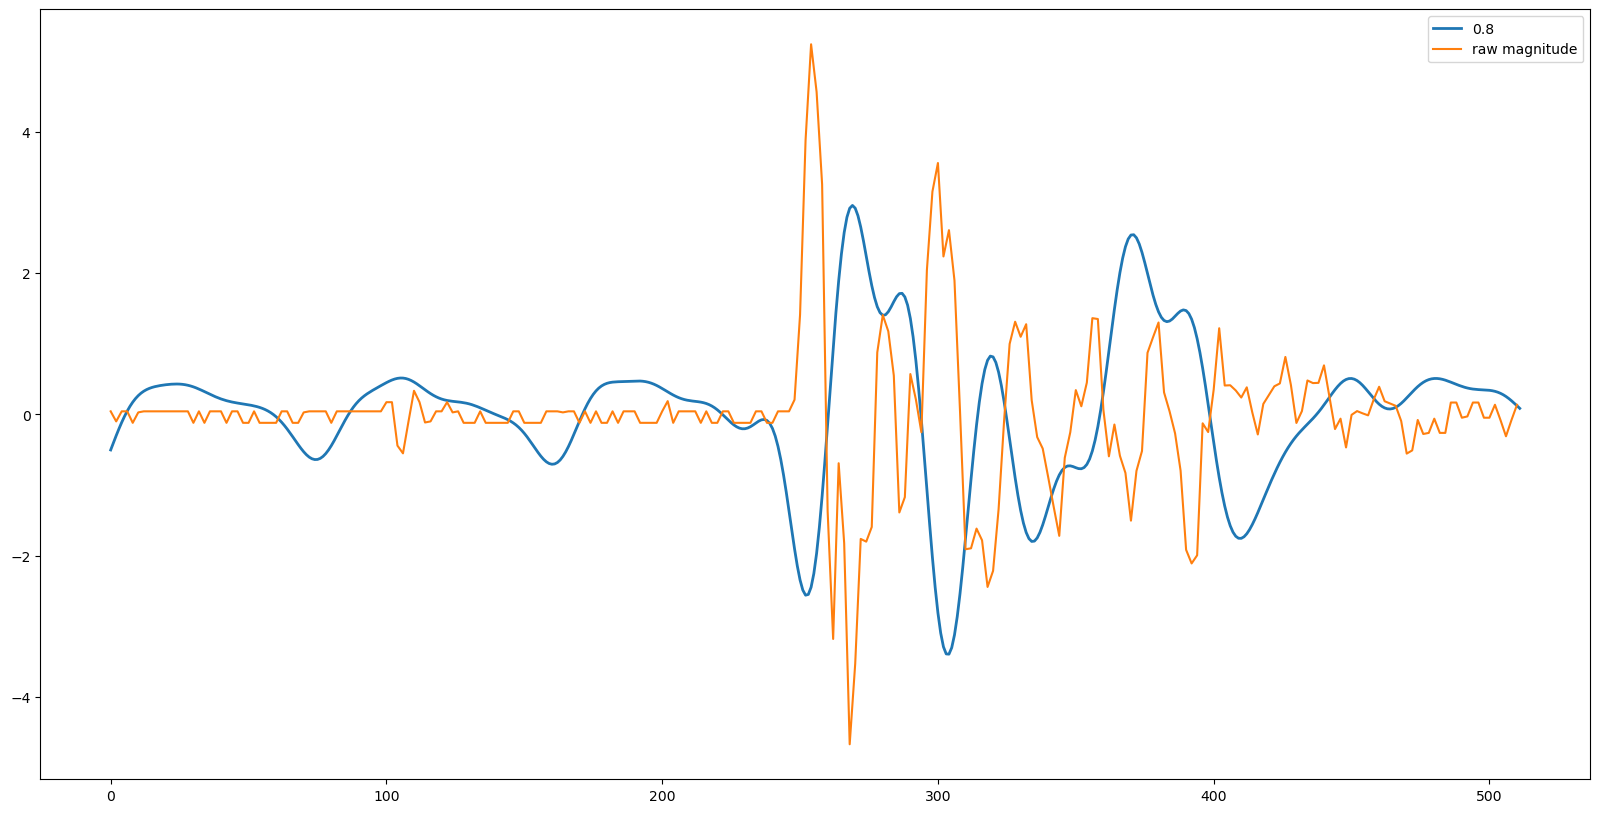

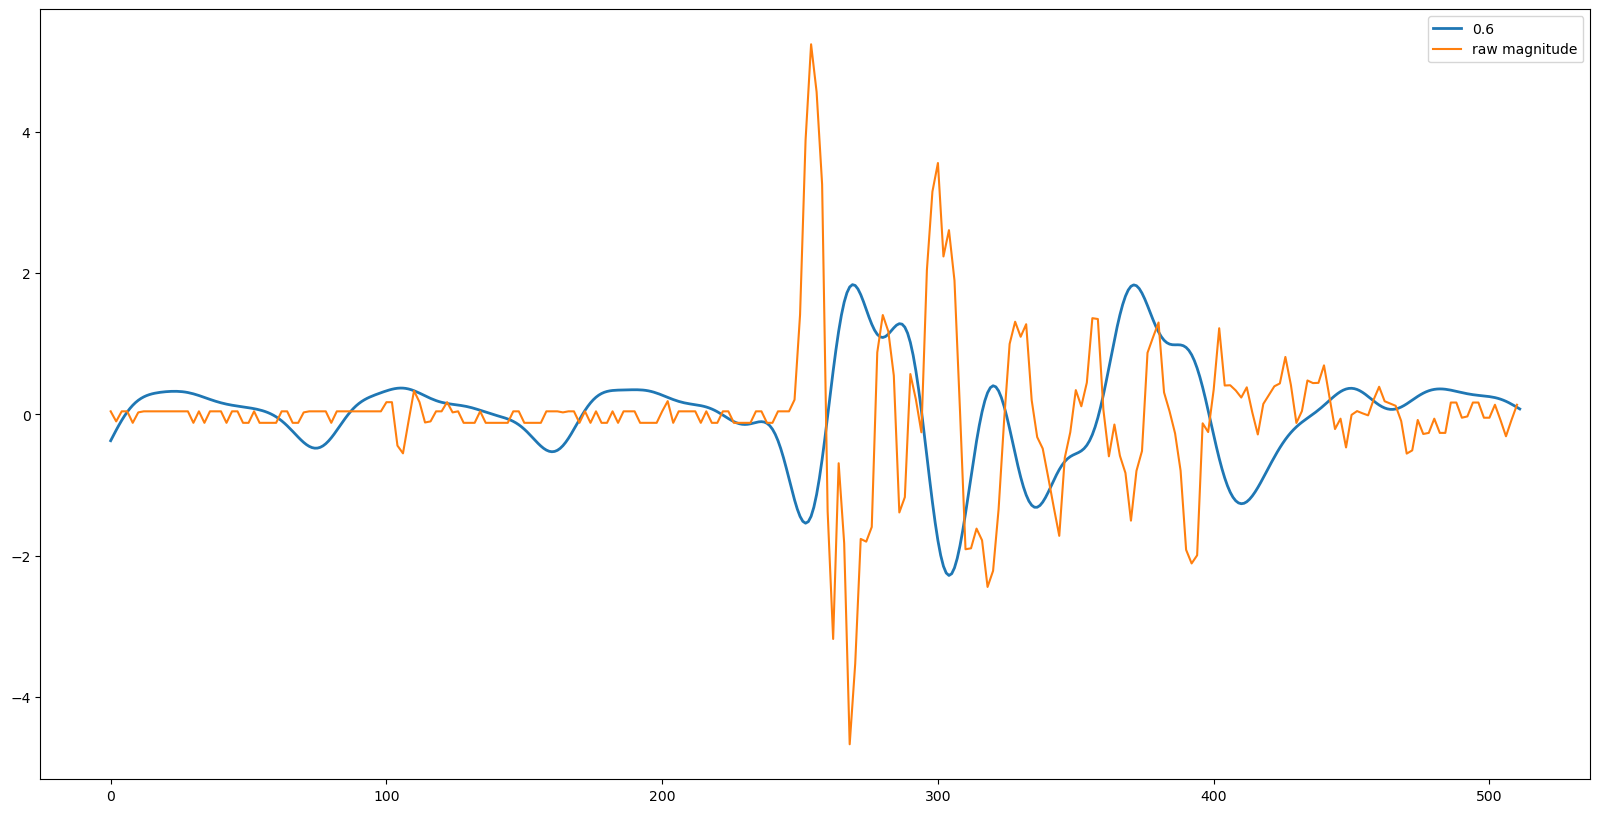

In [187]:
def peak_filt_smooth(segment, index):
    from scipy import signal
    import numpy as np
    import neurokit2 as nk
    import heartpy as hp

    """
    Retrieve the magnitudes of the accelerometer vectors, filter and smooth the PPG signal,
    and display them in a line graph.

    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_ppg_full = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 42:513]
    second_seg_ppg = segment.iloc[index+1, 1:42]
    segment_acc_values = segment.iloc[index, 513:1281]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    x_acc = np.arange(0, len(segment_ppg_full), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 
    
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one
        
    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_fullt_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - ppg_first_mean) / ppg_first_std # z normalisation
    
    # Downsample accelerometer values to match PPG length
    x_acc_downsampled = signal.resample(x_acc_normalized, len(segment_ppg_full))
    
    frac = [1.2, 0.5, 0.2, 0.4, 0.8, 0.6]
    for i in frac:
        isolated_ppg = (segment_ppg_full_normalized - (x_acc_downsampled*i)) * i
        ppg_cleaned = hp.filter_signal(isolated_ppg, cutoff = 3, sample_rate = 64.0, order = 5, filtertype='lowpass')
        plt.figure(figsize=(20,10))
        plt.plot(ppg_cleaned, linewidth=2 ,label=f'{i}')
        plt.plot(x_acc, x_acc_normalized, label='raw magnitude')
        plt.legend()
        plt.show()
        
#     ppg_df = pd.DataFrame({"PPG": isolated_ppg})

#     # Ensure numerical data:
#     ppg_df["PPG"] = pd.to_numeric(ppg_df["PPG"], errors='coerce')  # Convert strings to numbers if needed

#     # Handle missing values (if any):
#     # Choose a suitable method to handle NaNs (e.g., drop, fill, interpolate)

#     # Use ppg_process with your desired parameters:
#     ppg_cleaned = nk.ppg_clean(ppg_df, sampling_rate=64, method="elgendi")
    
#     peaks_signal, info = nk.ppg_peaks(ppg_cleaned,
#                                 sampling_rate=64,
#                                 method="elgendi")
    
#     rate = nk.signal_rate(info["PPG_Peaks"], sampling_rate=64, desired_length=len(ppg_cleaned))
    
#     info["sampling_rate"] = 64
    
#     signals = pd.DataFrame(
#         {
#             "PPG_Raw": isolated_ppg,
#             "PPG_Clean": ppg_cleaned,
#             "PPG_Rate": rate,
#             "PPG_Peaks": peaks_signal["PPG_Peaks"].values,
#         }
#     )
    
#     # signals.plot()
#     nk.ppg_plot(signals)
    # plt.plot(ppg_cleaned, label='last')
    # plt.legend()
    # plt.show()
    
    # print(len(isolated_ppg))
    
    
peak_filt_smooth(all_subjects_csv, 0)

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\2839894081.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one


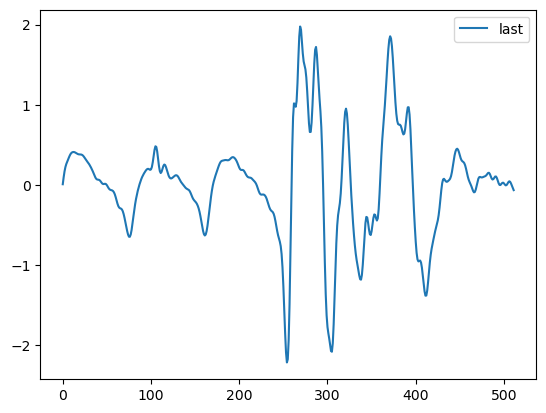

In [189]:
def peak_filt_smooth(segment, index):
    from scipy import signal
    import numpy as np
    import neurokit2 as nk
    import heartpy as hp

    """
    Retrieve the magnitudes of the accelerometer vectors, filter and smooth the PPG signal,
    and display them in a line graph.

    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_ppg_full = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 42:513]
    second_seg_ppg = segment.iloc[index+1, 1:42]
    segment_acc_values = segment.iloc[index, 513:1281]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    x_acc = np.arange(0, len(segment_ppg_full), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 
    
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one
        
    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_fullt_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - ppg_first_mean) / ppg_first_std # z normalisation
    
    # Downsample accelerometer values to match PPG length
    x_acc_downsampled = signal.resample(x_acc_normalized, len(segment_ppg_full))
    
    # frac = [1.2, 1.2, 1.6, 1.8, 2, 0.6]
    # for i in frac:
    #     isolated_ppg = (segment_ppg_full_normalized - (x_acc_downsampled*i)) * i
    #     plt.figure(figsize=(20,10))
    #     plt.plot(isolated_ppg, linewidth=2 ,label=f'{i}')
    #     plt.plot(x_acc, x_acc_normalized, label='raw magnitude')
    #     plt.legend()
    #     plt.show()
        
    isolated_ppg = (segment_ppg_full_normalized - (x_acc_downsampled*0.6)) * 0.6
    # ppg_cleaned = hp.filter_signal(isolated_ppg, cutoff = 3, sample_rate = 64.0, order = 5, filtertype='lowpass')
    
    ppg_df = pd.DataFrame({"PPG": isolated_ppg})

    # Ensure numerical data:
    ppg_df["PPG"] = pd.to_numeric(ppg_df["PPG"], errors='coerce')  # Convert strings to numbers if needed

    # Handle missing values (if any):
    # Choose a suitable method to handle NaNs (e.g., drop, fill, interpolate)

    # Use ppg_process with your desired parameters:
    ppg_cleaned = nk.ppg_clean(ppg_df, sampling_rate=64, method="elgendi")
    
    peaks_signal, info = nk.ppg_peaks(ppg_cleaned,
                                sampling_rate=64,
                                method="elgendi")
    
    rate = nk.signal_rate(info["PPG_Peaks"], sampling_rate=64, desired_length=len(ppg_cleaned))
    
    info["sampling_rate"] = 64
    
    # signals = pd.DataFrame(
    #     {
    #         "PPG_Raw": segment_ppg_values,
    #         "PPG_Clean": ppg_cleaned,
    #         "PPG_Rate": rate,
    #         "PPG_Peaks": peaks_signal["PPG_Peaks"].values,
    #     }
    # )
    
    plt.plot(ppg_cleaned, label='last')
    plt.legend()
    plt.show()
peak_filt_smooth(all_subjects_csv, 0)

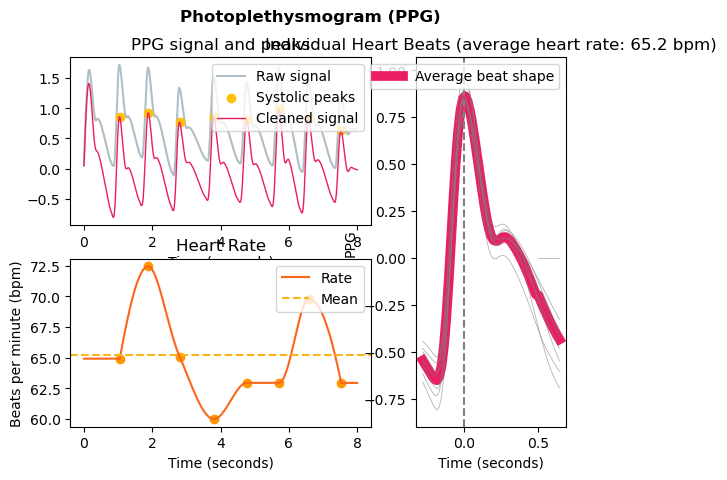

In [191]:
import neurokit2 as nk
ppg = nk.ppg_simulate(duration=8, sampling_rate=64)

signals, info = nk.ppg_process(ppg, sampling_rate=64)
nk.ppg_plot(signals, info)

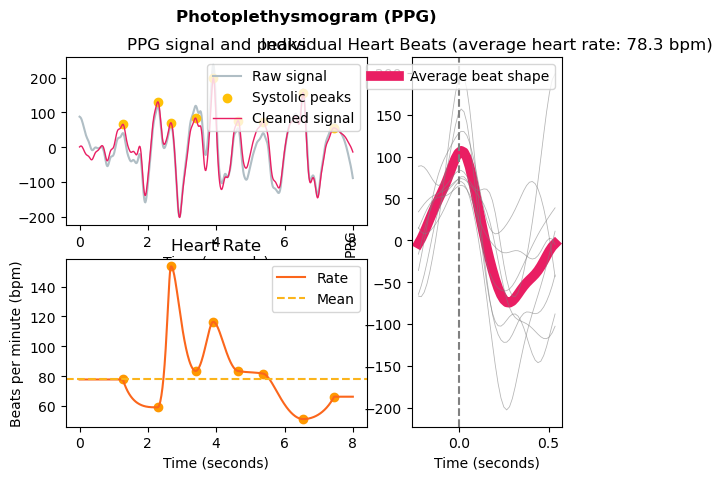

In [193]:
import neurokit2 as nk
from scipy import signal
import numpy as np

def peak_filt_smooth(segment, index):

    segment_ppg_values = segment.iloc[index, 1:513]

    # Create a DataFrame with appropriate column names:
    ppg_df = pd.DataFrame({"PPG": segment_ppg_values})

    # Ensure numerical data:
    ppg_df["PPG"] = pd.to_numeric(ppg_df["PPG"], errors='coerce')  # Convert strings to numbers if needed

    # Handle missing values (if any):
    # Choose a suitable method to handle NaNs (e.g., drop, fill, interpolate)

    # Use ppg_process with your desired parameters:
    ppg_cleaned = nk.ppg_clean(ppg_df, sampling_rate=64, method="elgendi")
    
    peaks_signal, info = nk.ppg_peaks(ppg_cleaned,
                                sampling_rate=64,
                                method="elgendi")
    
    rate = nk.signal_rate(info["PPG_Peaks"], sampling_rate=64, desired_length=len(ppg_cleaned))
    
    info["sampling_rate"] = 64
    
    signals = pd.DataFrame(
        {
            "PPG_Raw": segment_ppg_values,
            "PPG_Clean": ppg_cleaned,
            "PPG_Rate": rate,
            "PPG_Peaks": peaks_signal["PPG_Peaks"].values,
        }
    )
    
    # signals.plot()
    nk.ppg_plot(signals, info)
    
    # ppg_epochs = nk.ppg_segment(ppg_cleaned, sampling_rate=64, show=True)
    
#     ppg_cleaned_mean = np.mean(ppg_cleaned) # mean
#     ppg_cleaned_std = np.std(ppg_cleaned) # standard deviation
#     ppg_cleaned_norm = (ppg_cleaned - ppg_cleaned_mean) / ppg_cleaned_std # z normalisation
    
#     peaks_signal_mean = np.mean(peaks_signal) # mean
#     peaks_signal_std = np.std(peaks_signal) # standard deviation
#     peaks_signal_norm = (peaks_signal - peaks_signal_mean) / peaks_signal_std # z normalisation
    
    # plt.plot(ppg_cleaned_norm)
    # plt.plot(peaks_signal_norm)
    # plt.plot(rate)

    # Separate the processed PPG signal from the DataFrame:
    # processed_ppg_signal = processed_ppg["PPG_Clean"]

    # signals, info = nk.ppg_plot(processed_ppg)
    # nk.ppg_plot(signals, info)

# Call the function with appropriate input:
peak_filt_smooth(all_subjects_csv, 6)


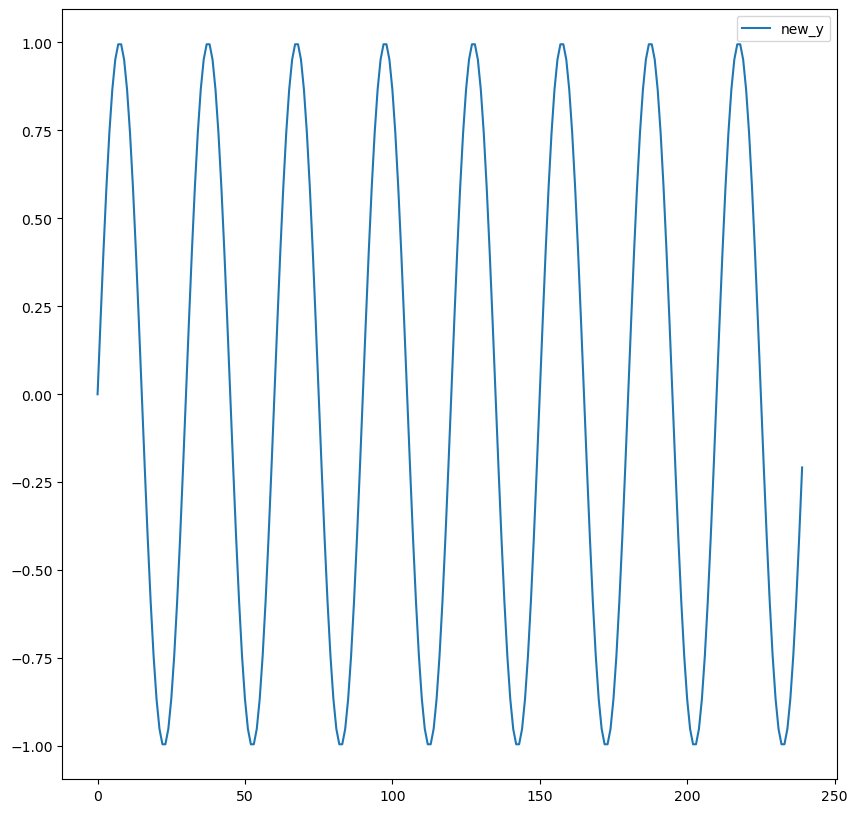

C:\Users\silva\AppData\Local\Temp\ipykernel_21324\1754011030.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one


In [195]:
def peak_filt_smooth(segment, index):
    from scipy import signal
    import numpy as np

    """
    Retrieve the magnitudes of the accelerometer vectors, filter and smooth the PPG signal,
    and display them in a line graph.

    segment = subject dataframe
    index = index of the 8-second segment
    """
    retrieved_segment = []
    segment_ppg_full = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 42:513]
    second_seg_ppg = segment.iloc[index+1, 1:42]
    segment_acc_values = segment.iloc[index, 513:1281]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    fs = 30  # sampling rate, Hz
    ts = np.arange(0, 8, 1.0 / fs)  # time vector - 8 seconds
    
    ys = np.sin(2*np.pi * 1.0 * ts)  # signal @ 1.0 Hz, without noise
    yerr = 0.5 * np.random.normal(size=len(ts))  # Gaussian noise
    yraw = ys + yerr

    fs = 64
    
    new_y = yraw - yerr
    
    plt.figure(figsize=(10,10))
    # plt.plot(ys, label='without_noise')
    plt.plot(new_y, label='new_y')
    # plt.plot(yerr, label='error')
    # plt.plot(yraw, label='with_noise')
    plt.legend()
    plt.show()
    
    x_acc = np.arange(0, len(segment_ppg_full), 2) # one value of the acc belongs to two values of ppg cuz ppg's len is 512 and acc's len is half of it (256) 
    
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values[vector], segment_acc_values[vector + 1],segment_acc_values[vector + 2])) # this is the three channels into one
        
    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_fullt_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - ppg_first_mean) / ppg_first_std # z normalisation

    # Choose a filter type and adjust parameters accordingly
    # Option 1: Butterworth bandpass filter with adjusted low-pass cutoff
    lpf_cutoff = 0.1  # Increased from 0.25 for smoother graph
    hpf_cutoff = 2.25
    sos = signal.iirfilter(2, Wn=[0.1, 2.5], fs=fs, btype="bandpass",
                                 ftype="butter", output="sos")
    yfilt = signal.sosfiltfilt(sos, segment_ppg_values)
    
    # plt.figure(figsize=(20,10))
    # plt.plot(segment_ppg_full_normalized, label='original')
    # plt.plot(x_acc, x_acc_normalized, label='raw magnitude')
    # plt.legend()
    # plt.show()

    
    # ... (rest of your code for peak analysis and visualization

peak_filt_smooth(all_subjects_csv, 7)

[  9  56 136 221 331 366 415 480]


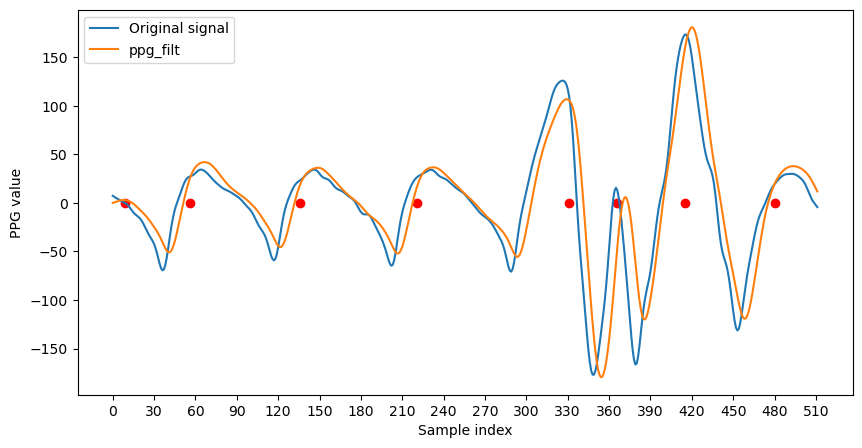

In [197]:
def peak_filt_filter_distance(segment, index):
    from scipy import signal
    import numpy as np

    """
    Retrieve the magnitudes of the accelerometer vectors, filter the PPG signal,
    find peaks, and filter them by minimum distance.

    segment = subject dataframe
    index = index of the 8-second segment
    min_peak_distance = minimum distance between filtered peaks (samples)
    """

    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]

    fs = 64.0
    lpf_cutoff = 0.1  # Increased from 0.25 for smoother graph
    hpf_cutoff = 2.5
    sos = signal.iirfilter(2, Wn=[lpf_cutoff, hpf_cutoff], fs=fs, btype="bandpass",
                          ftype="butter", output="sos")
    ppg_filt = signal.sosfilt(sos, segment_ppg_values)

    # Choose and apply your desired filter (e.g., Butterworth)
    # ... (filter code as in your previous example)

    # Find peaks in the filtered signal
    cwt_peaks = signal.find_peaks_cwt(segment_ppg_values, widths=np.arange(5, 30))
    
    print(cwt_peaks)
    # Plot the original and filtered peaks
    plt.figure(figsize=(10, 5))
    plt.plot(segment_ppg_values, label='Original signal')
    plt.plot(ppg_filt, label='ppg_filt')
    # plt.scatter(cwt_peaks, np.arange(0, len(segment_ppg_values)), c='r', label='Filtered peaks')
    y_values = [0] * len(cwt_peaks)
    # Plotting
    plt.scatter(cwt_peaks, y_values, color='red', marker='o')
    plt.xlabel('Sample index')
    plt.ylabel('PPG value')
    plt.xticks(np.arange(0, 512, 30))
    plt.legend()
    plt.show()
peak_filt_filter_distance(all_subjects_csv, 0)

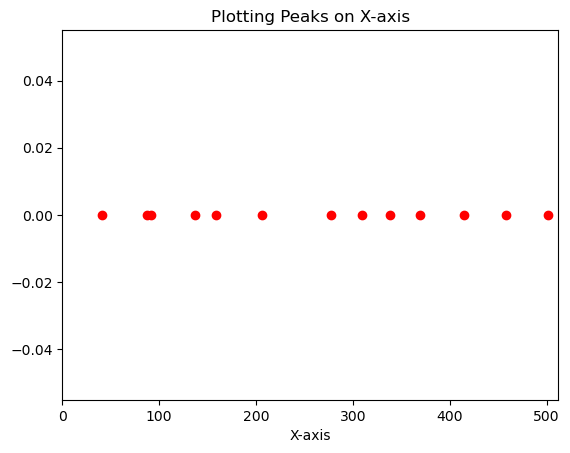

In [199]:
import matplotlib.pyplot as plt

# Your array of peaks
cwt_peaks = [41, 87, 91, 137, 159, 206, 277, 309, 338, 369, 415, 458, 501]

# Length of x-axis
x_length = 512

# Create a list of zeros for the y-values
y_values = [0] * len(cwt_peaks)

# Plotting
plt.scatter(cwt_peaks, y_values, color='red', marker='o')
plt.xlim(0, x_length)  # Set x-axis limits
plt.xlabel('X-axis')
plt.title('Plotting Peaks on X-axis')
plt.show()


[  9  56 136 221 331 366 415 480]


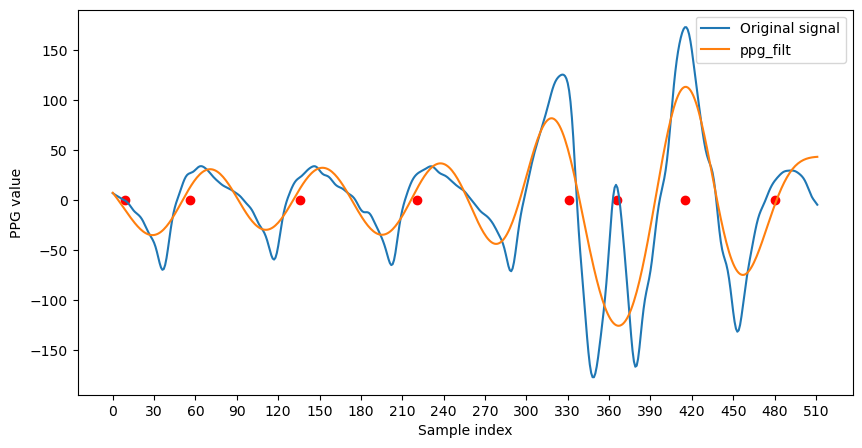

In [201]:
def peak_filt_filter_distance(segment, index):
    from scipy import signal
    import numpy as np
    import heartpy as hp

    """
    Retrieve the magnitudes of the accelerometer vectors, filter the PPG signal,
    find peaks, and filter them by minimum distance.

    segment = subject dataframe
    index = index of the 8-second segment
    min_peak_distance = minimum distance between filtered peaks (samples)
    """

    retrieved_segment = []
    segment_label = segment.iloc[index, -1]
    segment_ppg_values = segment.iloc[index, 1:513]
    segment_acc_values = segment.iloc[index, 513:1281]

    fs = 64.0
    lpf_cutoff = 0.1  # Increased from 0.25 for smoother graph
    hpf_cutoff = 2.5
    ppg_filt = hp.filter_signal(segment_ppg_values, cutoff = 1, sample_rate = 64.0, order = 5, filtertype='lowpass')
    
    # Choose and apply your desired filter (e.g., Butterworth)
    # ... (filter code as in your previous example)

    # Find peaks in the filtered signal
    cwt_peaks = signal.find_peaks_cwt(segment_ppg_values, widths=np.arange(5, 30))
    
    print(cwt_peaks)
    # Plot the original and filtered peaks
    plt.figure(figsize=(10, 5))
    plt.plot(segment_ppg_values, label='Original signal')
    plt.plot(ppg_filt, label='ppg_filt')
    # plt.scatter(cwt_peaks, np.arange(0, len(segment_ppg_values)), c='r', label='Filtered peaks')
    y_values = [0] * len(cwt_peaks)
    # Plotting
    plt.scatter(cwt_peaks, y_values, color='red', marker='o')
    plt.xlabel('Sample index')
    plt.ylabel('PPG value')
    plt.xticks(np.arange(0, 512, 30))
    plt.legend()
    plt.show()
peak_filt_filter_distance(all_subjects_csv, 0)

find_peaks: 60.000 bpm, findpeaks_cwt: 60.000 bpm


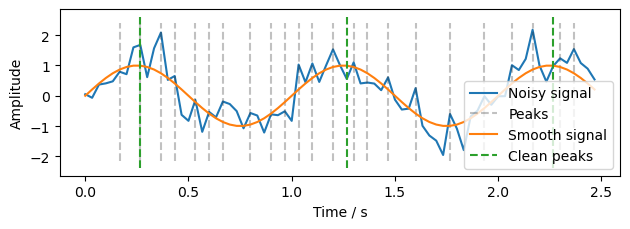

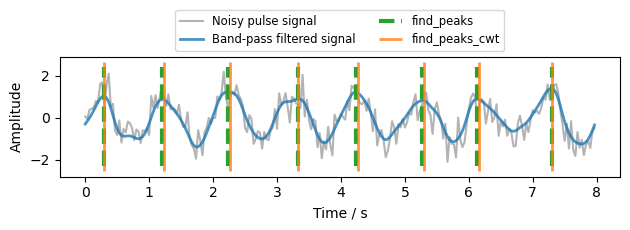

In [203]:
import numpy as np
import scipy.signal
from matplotlib import pyplot as plt

if __name__ == "__main__":
    np.random.seed(256)  # for reproducibility
    # create time steps and corresponding sine wave with Gaussian noise
    fs = 30  # sampling rate, Hz
    ts = np.arange(0, 8, 1.0 / fs)  # time vector - 8 seconds

    ys = np.sin(2*np.pi * 1.0 * ts)  # signal @ 1.0 Hz, without noise
    yerr = 0.5 * np.random.normal(size=len(ts))  # Gaussian noise
    yraw = ys + yerr

    nshort = 75
    tshort, yrawshort, yshort = ts[:nshort], yraw[:nshort], ys[:nshort]
    short_peaks, _ = scipy.signal.find_peaks(yrawshort)
    short_peaks_nonoise, _ = scipy.signal.find_peaks(yshort)

    plt.figure(figsize=[6.4, 2.4])
    plt.plot(tshort, yrawshort, label="Noisy signal")
    plt.vlines(tshort[short_peaks], *plt.ylim(), label="Peaks",
               color=".2", alpha=0.3, ls="--")

    plt.plot(tshort, yshort, label="Smooth signal")
    plt.vlines(tshort[short_peaks_nonoise], *plt.ylim(), label="Clean peaks",
               color="C2", ls="--")
    plt.xlabel("Time / s")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    # plt.savefig("basic-peaks.png", dpi=120)

    sos = scipy.signal.iirfilter(2, Wn=[0.1, 2.5], fs=fs, btype="bandpass",
                                 ftype="butter", output="sos")
    yfilt = scipy.signal.sosfiltfilt(sos, yraw)

    peaks, props = scipy.signal.find_peaks(yfilt, distance=0.35*fs, height=0.0)
    cwt_peaks = scipy.signal.find_peaks_cwt(yraw, widths=np.arange(5, 15))
    # peaks, props = scipy.signal.find_peaks(yraw)  # , distance=0.4*fs)
    hr_bpm_cwt = 60 / np.mean(np.diff(ts[cwt_peaks]))
    hr_bpm = 60 / np.mean(np.diff(ts[peaks]))
    print(f"find_peaks: {hr_bpm:.3f} bpm, findpeaks_cwt: {hr_bpm_cwt:.3f} bpm")

    # plot signals and peaks
    plt.figure(figsize=[6.4, 2.4])
    plt.plot(ts, yraw, color=".7", label="Noisy pulse signal")
    plt.plot(ts, yfilt, color="C0", alpha=0.8, lw=2,
             label="Band-pass filtered signal")
    plt.vlines(ts[peaks], *plt.ylim(), color="C2", lw=3, ls="dashed",
               label="find_peaks")
    plt.vlines(ts[cwt_peaks], *plt.ylim(), color="C1", alpha=0.8, lw=2,
               label="find_peaks_cwt")

    plt.xlabel("Time / s")
    plt.ylabel("Amplitude")
    plt.legend(loc="lower center", bbox_to_anchor=[0.5, 1], ncol=2,
               fontsize="smaller")
    plt.tight_layout()
    # plt.savefig("find-peaks.png", dpi=120)
    plt.show()

### 5.13. Getting the acc and PPG channels as input for the model (0-4 Hz FFT filter)

In [205]:
## Filtering 
def filter_ppg(segment_ppg_full, segment_acc_values):
    from scipy import signal
    import numpy as np
    import heartpy as hp

    """
    Filter the ppg data using a lowpass filter with a 4 Hz cut off frequency and factoring by 0.6.
    Return the ppg cleaned numpy array.

    segment_ppg_full = ppg numpy array that gets cleaned
    segment_acc_values = accelerometer numpy array 
    """
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values.iloc[vector], segment_acc_values.iloc[vector + 1],segment_acc_values.iloc[vector + 2])) # this is the three channels into one
        
    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_fullt_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - ppg_first_mean) / ppg_first_std # z normalisation
    
    x_acc_downsampled = signal.resample(x_acc_normalized, len(segment_ppg_full))
    
    isolated_ppg = (segment_ppg_full_normalized - (x_acc_downsampled*0.6)) * 0.6
    ppg_cleaned = hp.filter_signal(isolated_ppg, cutoff = 4, sample_rate = 64.0, order = 5, filtertype='lowpass')
    # plt.figure(figsize=(20,10))
    # plt.plot(ppg_cleaned, linewidth=2 ,label=f'{0.6}')
    # plt.plot(x_acc, x_acc_normalized, label='raw magnitude')
    # plt.legend()
    # plt.show()
    return ppg_cleaned

In [219]:
def test(dataset, index):
    """
    Retrieve the values from the single channel of the PPG and the three-axis channels of the accelerometer, apply rFFT and z-normalisation on them. 
    Return the 2d numpy array (Nch x Nfft). 
    
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_ppg_full = []
    segment_label = dataset.iloc[index, -1]
    segment_ppg_values = dataset.iloc[index, 42:513]
    second_seg_ppg = dataset.iloc[index+1, 1:42]
    segment_acc_values = dataset.iloc[index, 513:1281]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    ppg_cleaned = filter_ppg(segment_ppg_full, segment_acc_values)
    
    ## GETTING THE ACCELEROMETER AXIS
    acc_first_seg_vector_x = [] # variable that holds the accelerometer vector x
    acc_first_seg_vector_y = [] # variable that holds the accelerometer vector y
    acc_first_seg_vector_z = [] # variable that holds the accelerometer vector z
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector_x.append(segment_acc_values.iloc[vector])
        acc_first_seg_vector_y.append(segment_acc_values.iloc[vector+1])
        acc_first_seg_vector_z.append(segment_acc_values.iloc[vector+2])
        
    ## ACCELEROMETER X FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 32  # Hertz, sampling rate of the acc sensor
    DURATION = 8  # Seconds that we segmented
    N = len(acc_first_seg_vector) # number of samples in 8 seconds
    acc_first_seg_vector_rfft_x = rfft(acc_first_seg_vector_x)
    acc_first_seg_vector_rfftfreq_x = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_x = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_x, 'movement': acc_first_seg_vector_rfft_x}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_x = df_acc_seg_rfft_x[df_acc_seg_rfft_x['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['frequency'])
    df_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['movement'])
    # acc_seg_irfft_x = irfft(df_acc_seg_arr_x)

    ## ACCELEROMETER Y FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_y = rfft(acc_first_seg_vector_y)
    acc_first_seg_vector_rfftfreq_y = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_y = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_y, 'movement': acc_first_seg_vector_rfft_y}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_y = df_acc_seg_rfft_y[df_acc_seg_rfft_y['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['frequency'])
    df_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['movement'])
    # acc_seg_irfft_y = irfft(df_acc_seg_arr_y)
    
    ## ACCELEROMETER Z FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_z = rfft(acc_first_seg_vector_z)
    acc_first_seg_vector_rfftfreq_z = rfftfreq(N, 1/SAMPLE_RATE)
    # print(acc_first_seg_vector_rfft_z)
    
    df_acc_seg_rfft_z = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_z, 'movement': acc_first_seg_vector_rfft_z}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_z = df_acc_seg_rfft_z[df_acc_seg_rfft_z['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['frequency'])
    df_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['movement'])
    # acc_seg_irfft_z = irfft(df_acc_seg_arr_z)
    
    ## PPG FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 64  # Hertz, sampling rate of the ppg sensor
    DURATION = 8  # Seconds that we segmented
    N = len(ppg_cleaned) # number of samples in 8 seconds
    ppg_seg_vector_rfft = rfft(ppg_cleaned)
    ppg_seg_vector_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_ppg_seg_rfft = pd.DataFrame({'frequency': ppg_seg_vector_rfftfreq, 'heartrate': ppg_seg_vector_rfft}) # creating a new df for the rFFT

    df_ppg_seg_rfft_filtered = df_ppg_seg_rfft[df_ppg_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['frequency'])
    df_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['heartrate'])
    # ppg_seg_irfft = irfft(df_ppg_seg_arr)
    
    # print(len(ppg_cleaned))
    
    # print(f"rfft ppg full: {len(ppg_seg_vector_rfft)} , ppg 4 hz: {len(df_ppg_seg_arr)}")
    
    # print(f"rfft acc full: {len(acc_first_seg_vector_rfft_z)} , acc 4 hz: {len(df_acc_seg_arr_z)}")
     
    ## ACCELEROMETER X NORMALISATION ON THE FFT
    acc_rfft_mean_x = np.mean(df_acc_seg_arr_x) # mean
    acc_rfft_std_x = np.std(df_acc_seg_arr_x) # standard deviation
    acc_rfft_normalized_x = (df_acc_seg_arr_x - acc_rfft_mean_x) / acc_rfft_std_x # z normalisation
    
    ## ACCELEROMETER Y NORMALISATION ON THE FFT
    acc_rfft_mean_y = np.mean(df_acc_seg_arr_y) # mean
    acc_rfft_std_y = np.std(df_acc_seg_arr_y) # standard deviation
    acc_rfft_normalized_y = (df_acc_seg_arr_y - acc_rfft_mean_y) / acc_rfft_std_y # z normalisation
    
    ## ACCELEROMETER Z NORMALISATION ON THE FFT
    acc_rfft_mean_z = np.mean(df_acc_seg_arr_z) # mean
    acc_rfft_std_z = np.std(df_acc_seg_arr_z) # standard deviation
    acc_rfft_normalized_z = (df_acc_seg_arr_z - acc_rfft_mean_z) / acc_rfft_std_z # z normalisation

    ## PPG NORMALISATION ON THE FFT
    ppg_rfft_mean = np.mean(df_ppg_seg_arr) # mean
    ppg_rfft_std = np.std(df_ppg_seg_arr) # standard deviation
    ppg_rfft_normalized = (df_ppg_seg_arr - ppg_rfft_mean) / ppg_rfft_std # z normalisation
    
    ## PLOT
    # print(len(df_acc_seg_rfft_filtered_x), len(df_ppg_seg_rfft_filtered), len(df_acc_seg_rfft_filtered_y), len(df_acc_seg_rfft_filtered_z)) # they all have same lengths
    # plt.figure(figsize=(10,5))
    # plt.plot(freq_acc_seg_arr_x, acc_rfft_normalized_x, label='acc_x')
    # plt.plot(freq_acc_seg_arr_y, acc_rfft_normalized_y, label='acc_y')
    # plt.plot(freq_acc_seg_arr_z, acc_rfft_normalized_z, label='acc_z')
    # plt.plot(freq_ppg_seg_arr, ppg_rfft_normalized,  label='ppg')
    # plt.xlabel('Frequency (Hz)')
    # plt.ylabel('FFT-points')
    # plt.legend()
    # plt.show()
    
    # CHECKING THE 2D DATAFRAME WITH THE CHANNELS AND ITS FFT VALUES PER FREQUENCY
    # channels_dict = {
    #     "ppg": [ppg_rfft_normalized],
    #     "acc_x": [acc_rfft_normalized_x],
    #     "acc_y": [acc_rfft_normalized_y],
    #     "acc_z": [acc_rfft_normalized_x]
    # }
    # df = pd.DataFrame(index=channels_dict.keys(), columns=freq_ppg_seg_arr)
    # for channel, values_list in channels_dict.items():
    #     df.loc[channel] = [values_list[0][0]]

    # CREATING THE 2D ARRAY CONTAINING THE FFT VALUES OF EACH CHANNEL PER FREQUENCY
    full_channel_2d_arr = np.array([ppg_rfft_normalized, acc_rfft_normalized_x, acc_rfft_normalized_y, acc_rfft_normalized_z])
    # return full_channel_2d_arr
test = test(all_subjects_csv, 0)

In [221]:
from scipy.interpolate import interp1d
def full_channels_2d_arr_segment(dataset, index):
    """
    Retrieve the values from the single channel of the PPG and the three-axis channels of the accelerometer, apply rFFT and z-normalisation on them. 
    Return the 2d numpy array (Nch x Nfft). 
    
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_ppg_full = []
    segment_label = dataset.iloc[index, -1]
    segment_ppg_values = dataset.iloc[index, 43:514]
    second_seg_ppg = dataset.iloc[index+1, 2:43]
    segment_acc_values = dataset.iloc[index, 514:1282]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    ppg_cleaned = filter_ppg(segment_ppg_full, segment_acc_values)
    
    ## GETTING THE ACCELEROMETER AXIS
    acc_first_seg_vector_x = [] # variable that holds the accelerometer vector x
    acc_first_seg_vector_y = [] # variable that holds the accelerometer vector y
    acc_first_seg_vector_z = [] # variable that holds the accelerometer vector z
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector_x.append(segment_acc_values.iloc[vector])
        acc_first_seg_vector_y.append(segment_acc_values.iloc[vector+1])
        acc_first_seg_vector_z.append(segment_acc_values.iloc[vector+2])
        
    ## ACCELEROMETER X FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 32  # Hertz, sampling rate of the acc sensor
    DURATION = 8  # Seconds that we segmented
    N = len(acc_first_seg_vector) # number of samples in 8 seconds
    acc_first_seg_vector_rfft_x = fft(acc_first_seg_vector_x)
    acc_first_seg_vector_rfftfreq_x = fftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_x = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_x, 'movement': acc_first_seg_vector_rfft_x}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_x = df_acc_seg_rfft_x[df_acc_seg_rfft_x['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['frequency'])
    df_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['movement'])
    # acc_seg_irfft_x = irfft(df_acc_seg_arr_x)

    ## ACCELEROMETER Y FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_y = fft(acc_first_seg_vector_y)
    acc_first_seg_vector_rfftfreq_y = fftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_y = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_y, 'movement': acc_first_seg_vector_rfft_y}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_y = df_acc_seg_rfft_y[df_acc_seg_rfft_y['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['frequency'])
    df_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['movement'])
    # acc_seg_irfft_y = irfft(df_acc_seg_arr_y)
    
    ## ACCELEROMETER Z FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_z = fft(acc_first_seg_vector_z)
    acc_first_seg_vector_rfftfreq_z = fftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_z = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_z, 'movement': acc_first_seg_vector_rfft_z}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_z = df_acc_seg_rfft_z[df_acc_seg_rfft_z['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['frequency'])
    df_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['movement'])
    # acc_seg_irfft_z = irfft(df_acc_seg_arr_z)
    
    ## PPG FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 64  # Hertz, sampling rate of the ppg sensor
    DURATION = 8  # Seconds that we segmented
    N = len(ppg_cleaned) # number of samples in 8 seconds
    ppg_seg_vector_rfft = fft(ppg_cleaned)
    ppg_seg_vector_rfftfreq = fftfreq(N, 1/SAMPLE_RATE)
    
    df_ppg_seg_rfft = pd.DataFrame({'frequency': ppg_seg_vector_rfftfreq, 'heartrate': ppg_seg_vector_rfft}) # creating a new df for the rFFT

    df_ppg_seg_rfft_filtered = df_ppg_seg_rfft[df_ppg_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['frequency'])
    df_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['heartrate'])
    # ppg_seg_irfft = irfft(df_ppg_seg_arr)
    
    # ACCELEROMETER X NORMALISATION ON THE FFT
    acc_rfft_mean_x = np.mean(df_acc_seg_arr_x) # mean
    acc_rfft_std_x = np.std(df_acc_seg_arr_x) # standard deviation
    acc_rfft_normalized_x = (df_acc_seg_arr_x - acc_rfft_mean_x) / acc_rfft_std_x # z normalisation
    
    ## ACCELEROMETER Y NORMALISATION ON THE FFT
    acc_rfft_mean_y = np.mean(df_acc_seg_arr_y) # mean
    acc_rfft_std_y = np.std(df_acc_seg_arr_y) # standard deviation
    acc_rfft_normalized_y = (df_acc_seg_arr_y - acc_rfft_mean_y) / acc_rfft_std_y # z normalisation
    
    ## ACCELEROMETER Z NORMALISATION ON THE FFT
    acc_rfft_mean_z = np.mean(df_acc_seg_arr_z) # mean
    acc_rfft_std_z = np.std(df_acc_seg_arr_z) # standard deviation
    acc_rfft_normalized_z = (df_acc_seg_arr_z - acc_rfft_mean_z) / acc_rfft_std_z # z normalisation

    ## PPG NORMALISATION ON THE FFT
    ppg_rfft_mean = np.mean(df_ppg_seg_arr) # mean
    ppg_rfft_std = np.std(df_ppg_seg_arr) # standard deviation
    ppg_rfft_normalized = (df_ppg_seg_arr - ppg_rfft_mean) / ppg_rfft_std # z normalisation
    
    ## PLOT
    # print(len(df_acc_seg_rfft_filtered_x), len(df_ppg_seg_rfft_filtered), len(df_acc_seg_rfft_filtered_y), len(df_acc_seg_rfft_filtered_z)) # they all have same lengths
    # plt.figure(figsize=(10,5))
    # plt.plot(freq_acc_seg_arr_x, acc_rfft_normalized_x, label='acc_x')
    # plt.plot(freq_acc_seg_arr_y, acc_rfft_normalized_y, label='acc_y')
    # plt.plot(freq_acc_seg_arr_z, acc_rfft_normalized_z, label='acc_z')
    # plt.plot(freq_ppg_seg_arr, ppg_rfft_normalized,  label='ppg')
    # plt.xlabel('Frequency (Hz)')
    # plt.ylabel('FFT-points')
    # plt.legend()
    # plt.show()
    
    # CHECKING THE 2D DATAFRAME WITH THE CHANNELS AND ITS FFT VALUES PER FREQUENCY
#     channels_dict = {
#         "ppg": [ppg_rfft_normalized],
#         "acc_x": [acc_rfft_normalized_x],
#         "acc_y": [acc_rfft_normalized_y],
#         "acc_z": [acc_rfft_normalized_x]
#     }
#     df = pd.DataFrame(index=channels_dict.keys(), columns=freq_ppg_seg_arr)
    
#     for channel, values_list in channels_dict.items():
#         df.loc[channel] = [values_list[0][0]]

    x_acc_downsampled = signal.resample(acc_rfft_normalized_x, len(ppg_rfft_normalized)) # The resample function uses interpolation techniques to estimate the missing values introduced during downsampling
    y_acc_downsampled = signal.resample(acc_rfft_normalized_y, len(ppg_rfft_normalized))
    z_acc_downsampled = signal.resample(acc_rfft_normalized_z, len(ppg_rfft_normalized))
            
    # print(len(ppg_rfft_normalized),len(x_acc_downsampled),len(y_acc_downsampled),len(z_acc_downsampled))

    # CREATING THE 2D ARRAY CONTAINING THE FFT VALUES OF EACH CHANNEL PER FREQUENCY
    full_channel_2d_arr = np.array([ppg_rfft_normalized, x_acc_downsampled, y_acc_downsampled, z_acc_downsampled])
    full_channel_2d_arr = np.reshape(full_channel_2d_arr,(289,4))
    return full_channel_2d_arr

In [223]:
from scipy.interpolate import interp1d
def get_labels(dataset, index):
    """
    Get the label data point of the index and return it. 
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_label = dataset.iloc[index, -1]
    return segment_label

In [225]:
def range_inclusive(first_index, last_index): # Helper function
    return range(first_index, last_index+1)

def get_subject_segments(dataset, first_index=0, last_index=4000):
    """
    Pull the N-indexes of the specific subject and return the 3d numpy array (Ntr x Nch x Nfft).

    Ntr = number of segments used together for heart rate estimation
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    first_index = first segment index 
    last_index = last segment index to
    """
    if(first_index <= last_index):
        input_list = []
        for index in range_inclusive(first_index, last_index):
            input_list.append(full_channels_2d_arr_segment(all_subjects_csv, index))
        full_channels_3d_arr = np.stack(input_list, axis=0)
        return full_channels_3d_arr
    else:
        print("It should be an increment order")
        return None

In [227]:
def get_labels_segments(dataset, first_index=0, last_index=4000):
    """
    Get the label data points from the index range and return it as a numpy array.
    
    Parameters:
    dataset = subject dataframe
    first_index = first segment index 
    last_index = last segment index to
    """
    if(first_index <= last_index):
        labels_list = []
        for index in range_inclusive(first_index, last_index):
            labels_list.append(get_labels(all_subjects_csv, index))
        return np.array(labels_list)
    else:
        print("It should be an increment order")
        return None
train_labels = get_labels_segments(all_subjects_csv, 0, 4000)
test_labels = get_labels_segments(all_subjects_csv, 18, 33)
print(len(train_labels), len(test_labels))

4001 16


### 5.14. Splitting the dataset and testing the baseline model

In [230]:
def separate_subjects(dataframe):
    unique_subjects = dataframe['Subject'].unique()

    subject_dataframes = {}

    for subject in unique_subjects:
        subject_df = dataframe[dataframe['Subject'] == subject].reset_index(drop=True)
        subject_dataframes[subject] = subject_df

    return subject_dataframes

subject_dataframes = separate_subjects(all_subjects_csv)

In [232]:
test = subject_dataframes['Subject 1'].iloc[2,0]
# test = get_subject_segments(subject_dataframes['Subject 1'], 0, 10)
test
# segment_acc_values = dataset.iloc[index, 513:1281]

'Subject 1'

In [234]:
# len(subject_dataframes['Subject 1'])
train_data = get_subject_segments(subject_dataframes['Subject 1'], 0, 4000)
test_data = get_subject_segments(subject_dataframes['Subject 2'], 0, 4000)
print(train_data.shape, test_data.shape)

KeyboardInterrupt: 

In [694]:
# len(subject_dataframes['Subject 1'])
train_data = get_subject_segments(subject_dataframes['Subject 1'], 0, 16)
test_data = get_subject_segments(subject_dataframes['Subject 2'], 0, 16)
print(train_data.shape, test_data.shape)
train_labels = get_labels_segments(subject_dataframes['Subject 1'], 0, 16)
test_labels = get_labels_segments(subject_dataframes['Subject 2'], 0, 16)
print(len(train_labels), len(test_labels))

(17, 289, 4) (17, 289, 4)
17 17


### 5.15. Testing the model performance 

In [260]:
## Filtering 
def filter_ppg_testing(segment_ppg_full, segment_acc_values):
    from scipy import signal
    import numpy as np
    import heartpy as hp

    """
    Filter the ppg data using a lowpass filter with a 4 Hz cut off frequency and factoring by 0.6.
    Return the ppg cleaned numpy array.

    segment_ppg_full = ppg numpy array that gets cleaned
    segment_acc_values = accelerometer numpy array 
    """
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values.iloc[vector], segment_acc_values.iloc[vector + 1],segment_acc_values.iloc[vector + 2])) # this is the three channels into one
        
    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_fullt_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - ppg_first_mean) / ppg_first_std # z normalisation
    
    x_acc_downsampled = signal.resample(x_acc_normalized, len(segment_ppg_full))
    
    isolated_ppg = (segment_ppg_full_normalized - (x_acc_downsampled*0.6)) * 0.6
    ppg_cleaned = hp.filter_signal(isolated_ppg, cutoff = 4, sample_rate = 64.0, order = 5, filtertype='lowpass')
    # plt.figure(figsize=(20,10))
    # plt.plot(ppg_cleaned, linewidth=2 ,label=f'{0.6}')
    # plt.plot(x_acc, x_acc_normalized, label='raw magnitude')
    # plt.legend()
    # plt.show()
    return ppg_cleaned

In [410]:
from scipy.interpolate import interp1d
def full_channels_2d_arr_segment_testing(dataset, index):
    """
    Retrieve the values from the single channel of the PPG and the three-axis channels of the accelerometer, apply rFFT and z-normalisation on them. 
    Return the 2d numpy array (Nch x Nfft). 
    
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_ppg_full = []
    segment_label = dataset.iloc[index, -1]
    segment_ppg_values = dataset.iloc[index, 43:514]
    second_seg_ppg = dataset.iloc[index+1, 2:43]
    segment_acc_values = dataset.iloc[index, 514:1282]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    ppg_cleaned = filter_ppg_testing(segment_ppg_full, segment_acc_values)
    
    ## GETTING THE ACCELEROMETER AXIS
    acc_first_seg_vector_x = [] # variable that holds the accelerometer vector x
    acc_first_seg_vector_y = [] # variable that holds the accelerometer vector y
    acc_first_seg_vector_z = [] # variable that holds the accelerometer vector z
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector_x.append(segment_acc_values.iloc[vector])
        acc_first_seg_vector_y.append(segment_acc_values.iloc[vector+1])
        acc_first_seg_vector_z.append(segment_acc_values.iloc[vector+2])
        
    ppg_downsampled = signal.resample(ppg_cleaned, len(acc_first_seg_vector_x)) # The resample function uses interpolation techniques to estimate the missing values introduced during downsampling
    
    # print(f"ppg downsampled length: {len(ppg_downsampled)}, ppg_cleaned length: {len(ppg_cleaned)}, acc x length: {len(acc_first_seg_vector_x)}")
    # plt.plot(ppg_downsampled)
    # plt.plot(ppg_cleaned)
    # plt.legend()
    # plt.show()
    
    ## ACCELEROMETER X FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 32  # Hertz, sampling rate of the acc sensor
    DURATION = 8  # Seconds that we segmented
    N = len(acc_first_seg_vector) # number of samples in 8 seconds
    acc_first_seg_vector_rfft_x = rfft(acc_first_seg_vector_x)
    acc_first_seg_vector_rfftfreq_x = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_x = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_x, 'movement': acc_first_seg_vector_rfft_x}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_x = df_acc_seg_rfft_x[df_acc_seg_rfft_x['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['frequency'])
    df_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['movement'])
    df_acc_seg_arr_x_new_arr = []
    for i in range(0,len(df_acc_seg_arr_x)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_x_new_arr.append(df_acc_seg_arr_x[i].real)
        df_acc_seg_arr_x_new_arr.append(df_acc_seg_arr_x[i].imag)
    df_acc_seg_arr_x = np.array(df_acc_seg_arr_x_new_arr)
    # acc_seg_irfft_x = irfft(df_acc_seg_arr_x)

    ## ACCELEROMETER Y FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_y = rfft(acc_first_seg_vector_y)
    acc_first_seg_vector_rfftfreq_y = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_y = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_y, 'movement': acc_first_seg_vector_rfft_y}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_y = df_acc_seg_rfft_y[df_acc_seg_rfft_y['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['frequency'])
    df_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['movement'])
    df_acc_seg_arr_y_new_arr = [] 
    for i in range(0,len(df_acc_seg_arr_y)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_y_new_arr.append(df_acc_seg_arr_y[i].real)
        df_acc_seg_arr_y_new_arr.append(df_acc_seg_arr_y[i].imag)
    df_acc_seg_arr_y = np.array(df_acc_seg_arr_y_new_arr)
    # print(df_acc_seg_arr_y)
    # acc_seg_irfft_y = irfft(df_acc_seg_arr_y)
    
    ## ACCELEROMETER Z FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_z = rfft(acc_first_seg_vector_z)
    acc_first_seg_vector_rfftfreq_z = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_z = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_z, 'movement': acc_first_seg_vector_rfft_z}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_z = df_acc_seg_rfft_z[df_acc_seg_rfft_z['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['frequency'])
    df_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['movement'])
    df_acc_seg_arr_z_new_arr = [] 
    for i in range(0,len(df_acc_seg_arr_z)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_z_new_arr.append(df_acc_seg_arr_z[i].real)
        df_acc_seg_arr_z_new_arr.append(df_acc_seg_arr_z[i].imag)
    df_acc_seg_arr_z = np.array(df_acc_seg_arr_z_new_arr)
    
    ## PPG FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 64  # Hertz, sampling rate of the ppg sensor
    DURATION = 8  # Seconds that we segmented
    N = len(ppg_cleaned) # number of samples in 8 seconds
    ppg_seg_vector_rfft = rfft(ppg_cleaned)
    ppg_seg_vector_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_ppg_seg_rfft = pd.DataFrame({'frequency': ppg_seg_vector_rfftfreq, 'heartrate': ppg_seg_vector_rfft}) # creating a new df for the rFFT

    df_ppg_seg_rfft_filtered = df_ppg_seg_rfft[df_ppg_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['frequency'])
    df_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['heartrate'])
    df_ppg_seg_arr_new_arr = [] 
    for i in range(0,len(df_ppg_seg_arr)): # get rid of the imaginary part and increment it as a real number
        df_ppg_seg_arr_new_arr.append(df_ppg_seg_arr[i].real)
        df_ppg_seg_arr_new_arr.append(df_ppg_seg_arr[i].imag)
    df_ppg_seg_arr = np.array(df_ppg_seg_arr_new_arr)
    # ppg_seg_irfft = irfft(df_ppg_seg_arr)
    
    # ACCELEROMETER X NORMALISATION ON THE FFT
    acc_rfft_mean_x = np.mean(df_acc_seg_arr_x) # mean
    acc_rfft_std_x = np.std(df_acc_seg_arr_x) # standard deviation
    acc_rfft_normalized_x = (df_acc_seg_arr_x - acc_rfft_mean_x) / acc_rfft_std_x # z normalisation
    
    ## ACCELEROMETER Y NORMALISATION ON THE FFT
    acc_rfft_mean_y = np.mean(df_acc_seg_arr_y) # mean
    acc_rfft_std_y = np.std(df_acc_seg_arr_y) # standard deviation
    acc_rfft_normalized_y = (df_acc_seg_arr_y - acc_rfft_mean_y) / acc_rfft_std_y # z normalisation
    
    ## ACCELEROMETER Z NORMALISATION ON THE FFT
    acc_rfft_mean_z = np.mean(df_acc_seg_arr_z) # mean
    acc_rfft_std_z = np.std(df_acc_seg_arr_z) # standard deviation
    acc_rfft_normalized_z = (df_acc_seg_arr_z - acc_rfft_mean_z) / acc_rfft_std_z # z normalisation

    ## PPG NORMALISATION ON THE FFT
    ppg_rfft_mean = np.mean(df_ppg_seg_arr) # mean
    ppg_rfft_std = np.std(df_ppg_seg_arr) # standard deviation
    ppg_rfft_normalized = (df_ppg_seg_arr - ppg_rfft_mean) / ppg_rfft_std # z normalisation
            
    # print(len(ppg_rfft_normalized),len(x_acc_downsampled),len(y_acc_downsampled),len(z_acc_downsampled))

    # CREATING THE 2D ARRAY CONTAINING THE FFT VALUES OF EACH CHANNEL PER FREQUENCY
    full_channel_2d_arr = np.array([ppg_rfft_normalized, acc_rfft_normalized_x, acc_rfft_normalized_y, acc_rfft_normalized_z])
    full_channel_2d_arr = np.reshape(full_channel_2d_arr,(66,4))
    # print(full_channel_2d_arr.shape)
    return full_channel_2d_arr
test_ = full_channels_2d_arr_segment_testing(all_subjects_csv, 0)

In [412]:
from scipy.interpolate import interp1d
def get_labels_testing(dataset, index):
    """
    Get the label data point of the index and return it. 
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_label = dataset.iloc[index, -1]
    return segment_label

In [414]:
def range_inclusive(first_index, last_index): # Helper function
    return range(first_index, last_index+1)

def get_subject_segments_testing(dataset, first_index=0, last_index=4000):
    """
    Pull the N-indexes of the specific subject and return the 3d numpy array (Ntr x Nch x Nfft).

    Ntr = number of segments used together for heart rate estimation
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    first_index = first segment index 
    last_index = last segment index to
    """
    if(first_index <= last_index):
        input_list = []
        for index in range_inclusive(first_index, last_index):
            input_list.append(full_channels_2d_arr_segment_testing(all_subjects_csv, index))
        full_channels_3d_arr = np.stack(input_list, axis=0)
        return full_channels_3d_arr
    else:
        print("It should be an increment order")
        return None

In [416]:
def get_labels_segments_testing(dataset, first_index=0, last_index=4000):
    """
    Get the label data points from the index range and return it as a numpy array.
    
    Parameters:
    dataset = subject dataframe
    first_index = first segment index 
    last_index = last segment index to
    """
    if(first_index <= last_index):
        labels_list = []
        for index in range_inclusive(first_index, last_index):
            labels_list.append(get_labels_testing(all_subjects_csv, index))
        return np.array(labels_list)
    else:
        print("It should be an increment order")
        return None

In [483]:
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """ 
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    mae = history.history['mae']
    val_mae = history.history['val_mae']

    epochs = range(len(history.history['loss']))

    # Plot loss
    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.figure()
    plt.plot(epochs, mae, label='training_mae')
    plt.plot(epochs, val_mae, label='val_mae')
    plt.title('MAE')
    plt.xlabel('Epochs')
    plt.legend();


In [503]:
def plot_predictions(train_data, 
                     train_labels, 
                     test_data, 
                     test_labels, 
                     predictions):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue
    plt.plot(train_data, train_labels, label="Training data")
    # Plot test data in green
    plt.plot(test_data, test_labels, label="Testing data")
    # Plot the predictions in red (predictions were made on the test data)
    plt.plot(test_data, predictions, label="Predictions")
    # Show the legend
    plt.legend();

In [529]:
# len(subject_dataframes['Subject 1'])
train_data_testing = get_subject_segments_testing(subject_dataframes['Subject 4'], 0, 10)
test_data_testing = get_subject_segments_testing(subject_dataframes['Subject 7'], 0, 10)
print(train_data_testing.shape, test_data_testing.shape)
train_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 1'], 0, 10)
test_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 7'], 0, 10)
print(len(train_labels_testing), len(test_labels_testing))

(11, 66, 4) (11, 66, 4)
11 11


In [469]:
# model with 11 Ntr, nfc= 512, epochs = 100 and batch_size = 128 with different subjects (4 for training and 7 for testing)
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='elu'))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Dense(1, activation='linear'))
# model.summary()
model.compile(optimizer='adam',
      loss=tf.keras.losses.MeanSquaredError(),
             metrics=["mae"])

history = model.fit(train_data_testing, train_labels_testing, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing, test_labels_testing))

# plt.plot(history.history['loss'], label='loss')
# plt.plot(history.history['val_loss'], label='val_loss')
# plt.xlabel('Epoch')
# plt.legend()
# plt.show()

# test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

# print(test_acc)

Epoch 1/100

1/1 [==============================] - 3s 3s/step - loss: 3471.6250 - mae: 58.5521 - val_loss: 3373.9451 - val_mae: 57.7115
Epoch 2/100
1/1 [==============================] - 0s 377ms/step - loss: 3373.3274 - mae: 57.7091 - val_loss: 2674.1211 - val_mae: 51.2958
Epoch 3/100
1/1 [==============================] - 0s 337ms/step - loss: 2675.6960 - mae: 51.3271 - val_loss: 1014.9711 - val_mae: 31.1968
Epoch 4/100
1/1 [==============================] - 0s 337ms/step - loss: 1051.1093 - mae: 31.7507 - val_loss: 425.3894 - val_mae: 19.6292
Epoch 5/100
1/1 [==============================] - 0s 340ms/step - loss: 477.6851 - mae: 20.0944 - val_loss: 238.9370 - val_mae: 14.1479
Epoch 6/100
1/1 [==============================] - 0s 332ms/step - loss: 213.3210 - mae: 13.6761 - val_loss: 51.6754 - val_mae: 5.7166
Epoch 7/100
1/1 [==============================] - 0s 339ms/step - loss: 64.7294 - mae: 7.1260 - val_loss: 186.9136 - val_mae: 12.1648
Epoch 8/100
1/1 [=======================

In [525]:
scores = model.evaluate(test_data_testing, test_labels_testing, batch_size=128)
# y_preds = model.predict(test_data_testing)

1/1 [==============================] - 0s 336ms/step - loss: 5.1793 - mae: 2.0229


In [527]:
scores

[5.179303169250488, 2.022881507873535]

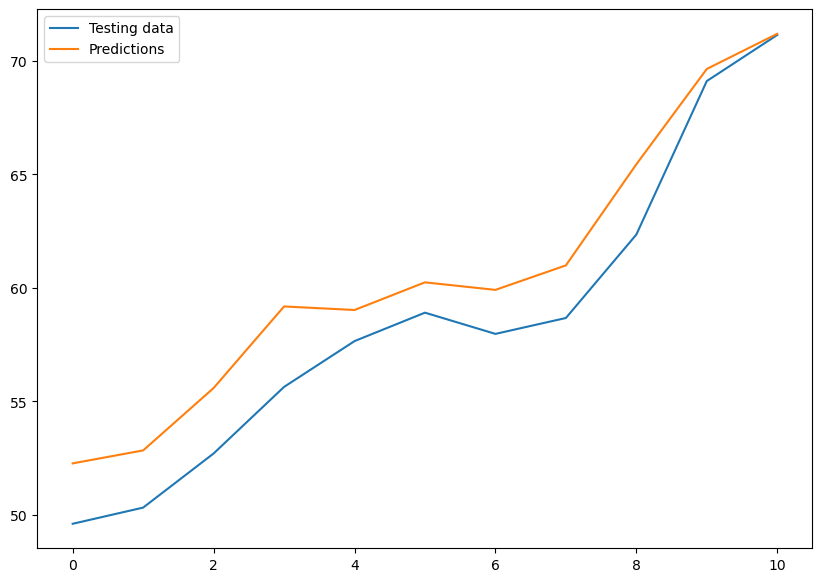

In [523]:
plt.figure(figsize=(10, 7))
plt.plot(test_labels_testing, label="Testing data")
plt.plot(y_preds, label="Predictions")
# Show the legend
plt.legend();

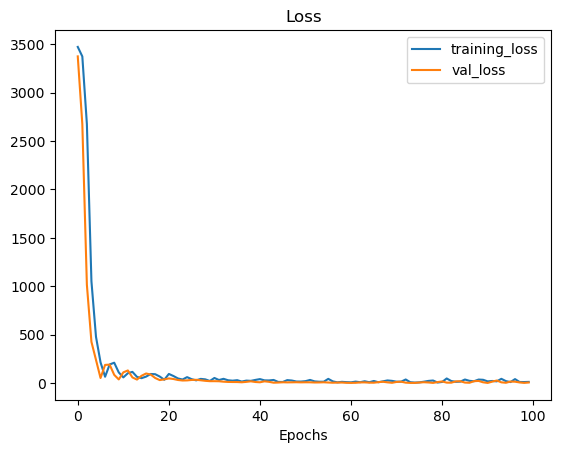

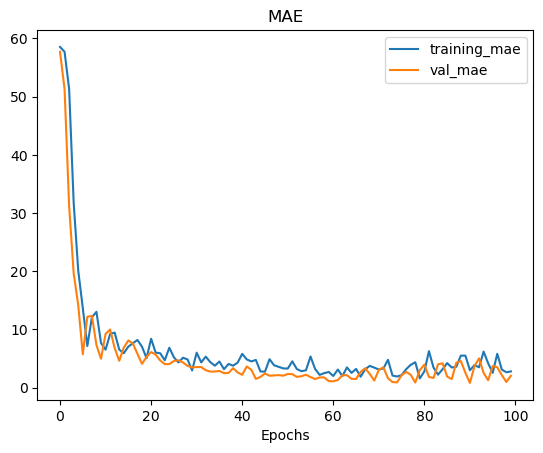

In [485]:
plot_loss_curves(history)

Epoch 1/100
1/1 [==============================] - 2s 2s/step - loss: 58.5438 - val_loss: 57.3104
Epoch 2/100
1/1 [==============================] - 0s 327ms/step - loss: 57.3009 - val_loss: 48.0650
Epoch 3/100
1/1 [==============================] - 0s 332ms/step - loss: 48.2923 - val_loss: 21.8777
Epoch 4/100
1/1 [==============================] - 0s 353ms/step - loss: 21.4165 - val_loss: 37.1410
Epoch 5/100
1/1 [==============================] - 0s 394ms/step - loss: 40.4855 - val_loss: 14.7038
Epoch 6/100
1/1 [==============================] - 0s 382ms/step - loss: 17.3670 - val_loss: 12.5608
Epoch 7/100
1/1 [==============================] - 0s 388ms/step - loss: 12.3802 - val_loss: 20.4691
Epoch 8/100
1/1 [==============================] - 0s 347ms/step - loss: 19.6248 - val_loss: 20.0449
Epoch 9/100
1/1 [==============================] - 0s 353ms/step - loss: 19.8507 - val_loss: 14.4184
Epoch 10/100
1/1 [==============================] - 0s 339ms/step - loss: 15.0177 - val_loss: 

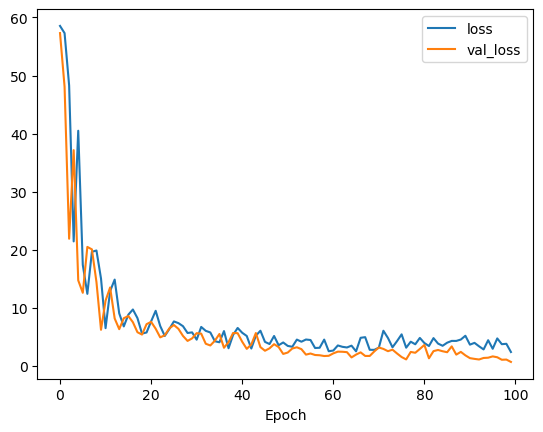

In [452]:
# model with 11 Ntr, nfc= 512, epochs = 100 and batch_size = 128
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='elu'))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Dense(1, activation='linear'))
# model.summary()
model.compile(optimizer='adam',
      loss=tf.keras.losses.MeanAbsoluteError())

history = model.fit(train_data_testing, train_labels_testing, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing, test_labels_testing))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

# print(test_acc)

Epoch 1/100
1/1 [==============================] - 2s 2s/step - loss: 55.1907 - val_loss: 54.8075
Epoch 2/100
1/1 [==============================] - 0s 328ms/step - loss: 54.8157 - val_loss: 51.7171
Epoch 3/100
1/1 [==============================] - 0s 292ms/step - loss: 51.7532 - val_loss: 40.9471
Epoch 4/100
1/1 [==============================] - 0s 299ms/step - loss: 41.1181 - val_loss: 14.8926
Epoch 5/100
1/1 [==============================] - 0s 333ms/step - loss: 13.8692 - val_loss: 37.2306
Epoch 6/100
1/1 [==============================] - 0s 302ms/step - loss: 34.5218 - val_loss: 25.0319
Epoch 7/100
1/1 [==============================] - 0s 297ms/step - loss: 24.1449 - val_loss: 3.8323
Epoch 8/100
1/1 [==============================] - 0s 310ms/step - loss: 4.2397 - val_loss: 15.2289
Epoch 9/100
1/1 [==============================] - 0s 319ms/step - loss: 15.2864 - val_loss: 19.3752
Epoch 10/100
1/1 [==============================] - 0s 341ms/step - loss: 19.8034 - val_loss: 18

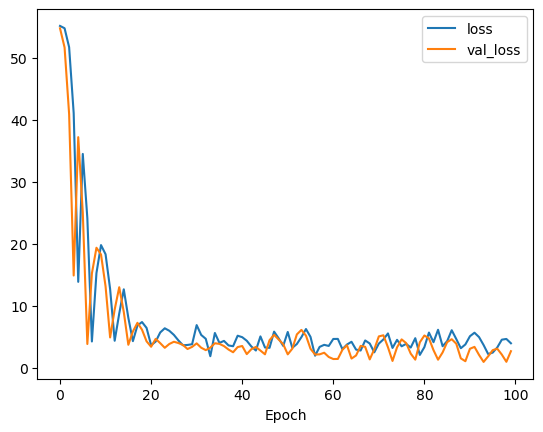

In [438]:
# model with 8 Ntr, nfc= 512, epochs = 100 and batch_size = 128
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='elu'))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Dense(1, activation='linear'))
# model.summary()
model.compile(optimizer='adam',
      loss=tf.keras.losses.MeanAbsoluteError())

history = model.fit(train_data_testing, train_labels_testing, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing, test_labels_testing))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

# print(test_acc)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_50 (Conv2D)          (None, 33, 4, 8)          16        
                                                                 
 conv2d_51 (Conv2D)          (None, 18, 2, 16)         6160      
                                                                 
 max_pooling2d_40 (MaxPooli  (None, 18, 1, 16)         0         
 ng2D)                                                           
                                                                 
 conv2d_52 (Conv2D)          (None, 18, 1, 32)         1568      
                                                                 
 max_pooling2d_41 (MaxPooli  (None, 18, 1, 32)         0         
 ng2D)                                                           
                                                                 
 conv2d_53 (Conv2D)          (None, 18, 1, 64)        

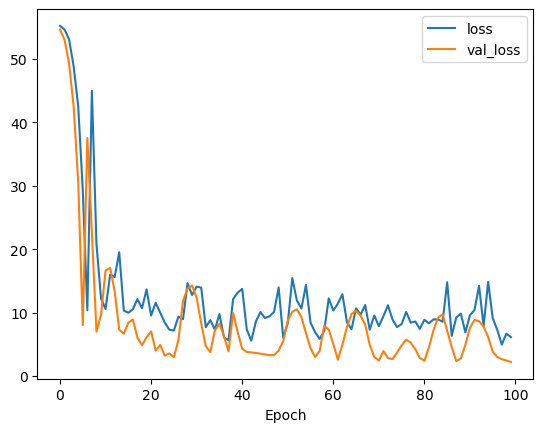

In [324]:
# model with 8 Ntr, nfc= 64, epochs = 100 and batch_size = 128
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(33, 4, 1),padding='same'))
model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(33, 4, 1)))
model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='elu'))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Dense(1, activation='linear'))
model.summary()
model.compile(optimizer='adam',
      loss=tf.keras.losses.MeanAbsoluteError())

history = model.fit(train_data_testing, train_labels_testing, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing, test_labels_testing))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

# print(test_acc)

In [531]:
# len(subject_dataframes['Subject 1'])
train_data_testing_2 = get_subject_segments_testing(subject_dataframes['Subject 4'], 0, 4000)
test_data_testing_2 = get_subject_segments_testing(subject_dataframes['Subject 7'], 0, 4000)
print(train_data_testing_2.shape, test_data_testing_2.shape)
train_labels_testing_2 = get_labels_segments_testing(subject_dataframes['Subject 1'], 0, 4000)
test_labels_testing_2 = get_labels_segments_testing(subject_dataframes['Subject 7'], 0, 4000)
print(len(train_labels_testing_2), len(test_labels_testing_2))

(4001, 66, 4) (4001, 66, 4)
4001 4001


In [545]:
# model with 40001 Ntr, nfc= 512, epochs = 100 and batch_size = 128 with different subjects (4 for training and 7 for testing)
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

model_2 = models.Sequential()
model_2.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
model_2.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model_2.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model_2.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

model_2.add(layers.Flatten())
model_2.add(layers.Dense(512, activation='elu'))
model_2.add(layers.Dropout(rate=0.5))
model_2.add(layers.Dense(1, activation='linear'))
# model.summary()
model_2.compile(optimizer='adam',
      loss=tf.keras.losses.MeanSquaredError(),
             metrics=["mae"])

history = model_2.fit(train_data_testing_2, train_labels_testing_2, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing_2, test_labels_testing_2))

Epoch 1/100
32/32 [==============================] - 62s 2s/step - loss: 1153.8491 - mae: 24.1127 - val_loss: 250.7133 - val_mae: 11.6394
Epoch 2/100
32/32 [==============================] - 70s 2s/step - loss: 206.0846 - mae: 10.4400 - val_loss: 171.1604 - val_mae: 9.1746
Epoch 3/100
32/32 [==============================] - 67s 2s/step - loss: 189.8890 - mae: 9.9273 - val_loss: 165.9280 - val_mae: 9.0154
Epoch 4/100
32/32 [==============================] - 66s 2s/step - loss: 187.9070 - mae: 9.8472 - val_loss: 166.3902 - val_mae: 9.1756
Epoch 5/100
32/32 [==============================] - 61s 2s/step - loss: 193.2289 - mae: 10.0549 - val_loss: 175.4634 - val_mae: 9.2727
Epoch 6/100
32/32 [==============================] - 49s 2s/step - loss: 182.4552 - mae: 9.7376 - val_loss: 153.5187 - val_mae: 8.8552
Epoch 7/100
32/32 [==============================] - 48s 1s/step - loss: 170.6310 - mae: 9.4714 - val_loss: 138.1906 - val_mae: 8.1703
Epoch 8/100
32/32 [==============================]

In [567]:
evaluate_data_2 = get_subject_segments_testing(subject_dataframes['Subject 6'], 0, 4000)
evaluate_label_2 = get_labels_segments_testing(subject_dataframes['Subject 6'], 0, 4000)
scores = model_2.evaluate(evaluate_data_2, evaluate_label_2, batch_size=128)
y_preds = model_2.predict(evaluate_data_2)

126/126 [==============================] - 10s 76ms/step


In [549]:
scores

[58.58768081665039, 6.778100967407227]

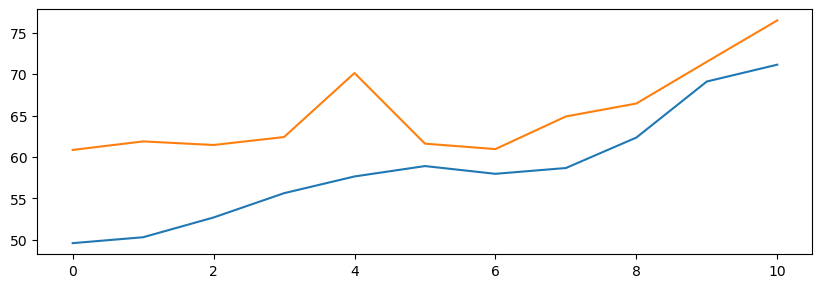

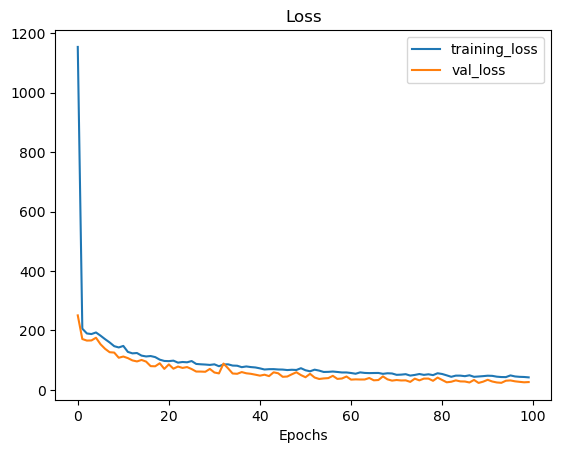

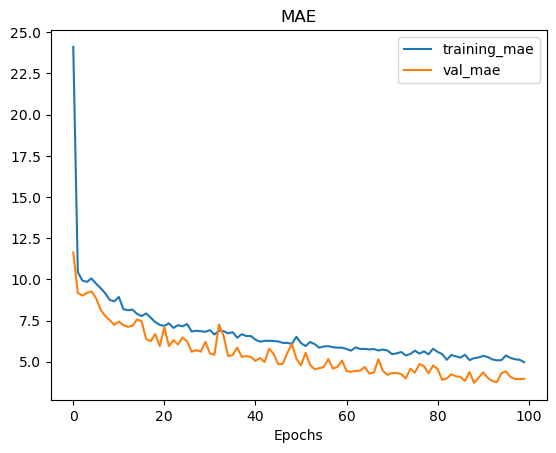

In [565]:
plt.figure(figsize=(10, 7))
plt.subplot(2,1,1)
plt.plot(test_labels_testing, label="Testing data")
plt.plot(y_preds, label="Predictions")
plt.show()
plot_loss_curves(history)
# Show the legend
plt.legend();